<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/huang_baseline_64_channels__exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 1 — EXTRA TREES CLASSIFIER-SWAP SETUP
#
# Run after mounting Google Drive.
# ============================================================

!pip -q install mne pymatreader scipy scikit-learn pandas numpy tqdm

import os
import glob
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import mne

from tqdm.auto import tqdm
from pymatreader import read_mat
from scipy.linalg import eigh

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
)

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================================
# Main paths
# ============================================================

EXP8_DIR = (
    "/content/drive/MyDrive/"
    "my dataset_raw_main_exp8"
)

REREF_DIR = os.path.join(
    EXP8_DIR,
    "derivatives",
    "rerefer"
)

ET_SWAP_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP"
)

WITHIN_ET_DIR = os.path.join(
    ET_SWAP_DIR,
    "WITHIN_INDIVIDUAL_FULL_61_63CH_STRICT192"
)

CROSS_ET_DIR = os.path.join(
    ET_SWAP_DIR,
    "CROSS_INDIVIDUAL_COMMON_61CH_STRICT223"
)

os.makedirs(
    WITHIN_ET_DIR,
    exist_ok=True
)

os.makedirs(
    CROSS_ET_DIR,
    exist_ok=True
)


# ============================================================
# Extra Trees parameters
#
# Same fixed Extra Trees configuration used in the proposed
# pipeline. No tuning uses held-out trials or participants.
# ============================================================

ET_PARAMETERS = {
    "n_estimators": 150,
    "max_depth": 12,
    "min_samples_leaf": 3,
    "min_samples_split": 5,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}


def make_extra_trees():

    return ExtraTreesClassifier(
        **ET_PARAMETERS
    )


# ============================================================
# Atomic saving
# ============================================================

def atomic_save_csv(
    dataframe,
    final_path,
):

    temporary_path = (
        final_path + ".temporary"
    )

    dataframe.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        final_path
    )


def atomic_save_json(
    content,
    final_path,
):

    temporary_path = (
        final_path + ".temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            content,
            file,
            indent=4,
            default=str
        )

    os.replace(
        temporary_path,
        final_path
    )


# ============================================================
# Binary metrics
# ============================================================

def calculate_binary_metrics(
    y_true,
    y_pred,
    y_score,
):

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    ).ravel()

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    ).ravel()

    y_score = np.asarray(
        y_score,
        dtype=float
    ).ravel()

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    both_classes = (
        np.unique(y_true).size == 2
    )

    if both_classes:

        balanced_accuracy = (
            sensitivity + specificity
        ) / 2.0

        roc_auc = roc_auc_score(
            y_true,
            y_score
        )

        pr_auc = average_precision_score(
            y_true,
            y_score
        )

    else:

        balanced_accuracy = np.nan
        roc_auc = np.nan
        pr_auc = np.nan

    try:
        mcc = matthews_corrcoef(
            y_true,
            y_pred
        )
    except Exception:
        mcc = np.nan

    try:
        kappa = cohen_kappa_score(
            y_true,
            y_pred
        )

        if not np.isfinite(kappa):
            kappa = np.nan

    except Exception:
        kappa = np.nan

    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy,

        "precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "sensitivity":
            sensitivity,

        "specificity":
            specificity,

        "f1_score":
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "mcc":
            mcc,

        "cohen_kappa":
            kappa,

        "true_negative":
            int(tn),

        "false_positive":
            int(fp),

        "false_negative":
            int(fn),

        "true_positive":
            int(tp),

        "support_low":
            int(np.sum(y_true == 0)),

        "support_high":
            int(np.sum(y_true == 1)),
    }


def get_high_pain_probability(
    fitted_model,
    X_test,
):

    probabilities = fitted_model.predict_proba(
        X_test
    )

    class_positions = np.flatnonzero(
        fitted_model.classes_ == 1
    )

    if class_positions.size != 1:

        raise RuntimeError(
            "Class 1 could not be identified."
        )

    return probabilities[
        :,
        int(class_positions[0])
    ]


print("=" * 72)
print("EXTRA TREES CLASSIFIER-SWAP SETUP READY")
print("=" * 72)

print("Results directory:")
print(ET_SWAP_DIR)

print("\nExtra Trees parameters:")
print(ET_PARAMETERS)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 56.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
EXTRA TREES CLASSIFIER-SWAP SETUP READY
Results directory:
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP

Extra Trees parameters:
{'n_estimators': 150, 'max_depth': 12, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}


In [ ]:
# ============================================================
# CELL 2 — LOAD SAVED WITHIN-INDIVIDUAL PARTICIPANT AUDIT
#
# No channel intersection is recalculated.
# No 26-channel montage is used.
# ============================================================

ORIGINAL_WITHIN_RESULT_DIR = os.path.join(
    "/content/drive/MyDrive",
    (
        "HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_"
        "PARTICIPANT_SPECIFIC_61_63CH"
    )
)

COMBINED_WITHIN_SUBJECT_PATH = os.path.join(
    ORIGINAL_WITHIN_RESULT_DIR,
    "huang_192_subject_complete_metrics.csv"
)

ORIGINAL_SUMMARY_CHECKPOINT_DIR = os.path.join(
    ORIGINAL_WITHIN_RESULT_DIR,
    "subject_checkpoints",
    "subject_summaries"
)


# ============================================================
# Load the saved participant audit
# ============================================================

if os.path.exists(
    COMBINED_WITHIN_SUBJECT_PATH
):

    saved_within_audit_df = pd.read_csv(
        COMBINED_WITHIN_SUBJECT_PATH,
        dtype={
            "subject_id": str
        }
    )

    print(
        "Loaded combined saved participant audit."
    )

else:

    summary_checkpoint_files = sorted(
        glob.glob(
            os.path.join(
                ORIGINAL_SUMMARY_CHECKPOINT_DIR,
                "*_summary.csv"
            )
        )
    )

    if len(summary_checkpoint_files) != 192:

        raise FileNotFoundError(
            "The completed 192-participant audit "
            "could not be found.\n\n"
            f"Checked:\n{COMBINED_WITHIN_SUBJECT_PATH}\n\n"
            f"Checkpoint files found: "
            f"{len(summary_checkpoint_files)}"
        )

    saved_within_audit_df = pd.concat(
        [
            pd.read_csv(
                path,
                dtype={
                    "subject_id": str
                }
            )
            for path in summary_checkpoint_files
        ],
        ignore_index=True
    )

    print(
        "Loaded participant audit from checkpoints."
    )


required_audit_columns = {
    "subject_id",
    "n_trials",
    "n_channels",
    "n_low",
    "n_high",
    "channel_names",
}

missing_columns = (
    required_audit_columns
    -
    set(saved_within_audit_df.columns)
)

if missing_columns:

    raise ValueError(
        "Saved participant audit is missing:\n"
        f"{sorted(missing_columns)}"
    )


saved_within_audit_df[
    "subject_id"
] = saved_within_audit_df[
    "subject_id"
].astype(str)


# ============================================================
# Match saved participants to preprocessed .set files
# ============================================================

set_files = sorted(
    glob.glob(
        os.path.join(
            REREF_DIR,
            "*.set"
        )
    )
)

set_file_map = {}

for file_path in set_files:

    subject_id = os.path.basename(
        file_path
    ).split("_")[0]

    if subject_id in set_file_map:

        raise ValueError(
            f"Duplicate .set file for {subject_id}"
        )

    set_file_map[
        subject_id
    ] = file_path


within_subject_records = []

for _, row in (
    saved_within_audit_df
    .sort_values("subject_id")
    .iterrows()
):

    subject_id = str(
        row["subject_id"]
    )

    if subject_id not in set_file_map:

        raise FileNotFoundError(
            f"No rereferenced .set file found "
            f"for {subject_id}."
        )

    channel_names = [
        channel.strip()
        for channel in str(
            row["channel_names"]
        ).split("|")
        if channel.strip()
    ]

    if "Cz" not in channel_names:

        raise ValueError(
            f"{subject_id}: Cz is absent "
            "from the saved channel list."
        )

    record = {
        "subject_id":
            subject_id,

        "file_path":
            set_file_map[
                subject_id
            ],

        "n_valid_epochs":
            int(
                row["n_trials"]
            ),

        "low_count":
            int(
                row["n_low"]
            ),

        "high_count":
            int(
                row["n_high"]
            ),

        "channel_names":
            channel_names,

        "n_channels":
            len(channel_names),
    }

    within_subject_records.append(
        record
    )


# ============================================================
# Validation
# ============================================================

assert len(within_subject_records) == 192

assert sum(
    record["n_valid_epochs"]
    for record in within_subject_records
) == 5408

assert min(
    record["n_channels"]
    for record in within_subject_records
) == 61

assert max(
    record["n_channels"]
    for record in within_subject_records
) == 63

assert all(
    record["low_count"] >= 2
    and record["high_count"] >= 2
    for record in within_subject_records
)


within_channel_distribution = (
    pd.Series(
        [
            record["n_channels"]
            for record in within_subject_records
        ]
    )
    .value_counts()
    .sort_index()
)


print("\n" + "=" * 72)
print("SAVED WITHIN-INDIVIDUAL AUDIT LOADED")
print("=" * 72)

print("Participants:", len(within_subject_records))

print(
    "Valid trials:",
    sum(
        record["n_valid_epochs"]
        for record in within_subject_records
    )
)

print("\nChannels per participant:")

display(
    within_channel_distribution
    .rename("participants")
    .to_frame()
)

print(
    "\nNo 26-channel list was used."
)

Loaded combined saved participant audit.

SAVED WITHIN-INDIVIDUAL AUDIT LOADED
Participants: 192
Valid trials: 5408

Channels per participant:


,participants
61,2
62,3
63,187



No 26-channel list was used.


In [ ]:
# ============================================================
# CELL 3 — HUANG CSP AND EQUATION-3 FEATURE FUNCTIONS
#
# Within-individual:
#   participant-specific full 61–63-channel montage
#
# Every fold:
#   training-only CSP
#   training-only N2/P2 templates
#   training-only Extra Trees
# ============================================================

HUANG_TMIN = -0.500
HUANG_TMAX = 1.000

BASELINE_TMIN = -0.500
BASELINE_TMAX = 0.000

CSP_PRE_WINDOW = (
    -0.500,
    0.000
)

CSP_POST_WINDOW = (
    0.000,
    0.500
)

HUANG_MLR_WINDOW = (
    0.000,
    0.500
)

N2_WINDOW = (
    0.150,
    0.300
)

P2_WINDOW = (
    0.300,
    0.450
)

N_CSP_COMPONENTS = 3

BETA_NAMES = [
    "beta1_N2_amplitude",
    "beta2_N2_latency",
    "beta3_P2_amplitude",
    "beta4_P2_latency",
    "beta5_intercept",
]


# ============================================================
# Rating extraction
# ============================================================

def safe_scalar(value):

    if isinstance(
        value,
        np.ndarray
    ):

        if value.size == 0:
            return np.nan

        return safe_scalar(
            value.flatten()[0]
        )

    if isinstance(
        value,
        list
    ):

        if len(value) == 0:
            return np.nan

        return safe_scalar(
            value[0]
        )

    return value


def listify(value):

    if isinstance(
        value,
        list
    ):
        return value

    if isinstance(
        value,
        np.ndarray
    ):
        return list(
            value.flatten()
        )

    return [value]


def extract_exp8_ratings(
    mat_data,
    n_trials,
):

    ratings = [
        np.nan
    ] * n_trials

    epoch_structure = mat_data.get(
        "epoch",
        None
    )

    if isinstance(
        epoch_structure,
        dict
    ):

        if "eventrating" in epoch_structure:

            values = listify(
                epoch_structure[
                    "eventrating"
                ]
            )

            for index in range(
                min(
                    len(values),
                    n_trials
                )
            ):

                ratings[index] = safe_scalar(
                    values[index]
                )

    elif isinstance(
        epoch_structure,
        list
    ):

        for index in range(
            min(
                len(epoch_structure),
                n_trials
            )
        ):

            epoch_information = (
                epoch_structure[index]
            )

            if (
                isinstance(
                    epoch_information,
                    dict
                )
                and
                "eventrating"
                in epoch_information
            ):

                ratings[index] = safe_scalar(
                    epoch_information[
                        "eventrating"
                    ]
                )

    return np.asarray(
        ratings,
        dtype=float
    )


# ============================================================
# Load one participant using the saved channel list
# ============================================================

def load_full_montage_subject(
    subject_record,
):

    subject_id = subject_record[
        "subject_id"
    ]

    file_path = subject_record[
        "file_path"
    ]

    channel_names = list(
        subject_record[
            "channel_names"
        ]
    )

    epochs = mne.io.read_epochs_eeglab(
        file_path,
        verbose=False
    )

    missing_channels = [
        channel
        for channel in channel_names
        if channel not in epochs.ch_names
    ]

    if missing_channels:

        raise ValueError(
            f"{subject_id}: saved channels missing "
            f"from current .set file:\n"
            f"{missing_channels}"
        )

    channel_indices = [
        epochs.ch_names.index(
            channel
        )
        for channel in channel_names
    ]

    full_times = np.asarray(
        epochs.times,
        dtype=float
    )

    analysis_mask = (
        (
            full_times
            >= HUANG_TMIN - 1e-9
        )
        &
        (
            full_times
            <= HUANG_TMAX + 1e-9
        )
    )

    times = full_times[
        analysis_mask
    ]

    # EEG is loaded in volts and converted to microvolts.
    X = (
        epochs.get_data(
            picks=channel_indices
        )[
            :,
            :,
            analysis_mask
        ]
        *
        1e6
    )

    baseline_mask = (
        (
            times
            >= BASELINE_TMIN - 1e-9
        )
        &
        (
            times
            <= BASELINE_TMAX + 1e-9
        )
    )

    baseline_mean = X[
        :,
        :,
        baseline_mask
    ].mean(
        axis=2,
        keepdims=True
    )

    X = (
        X
        -
        baseline_mean
    )

    mat_data = read_mat(
        file_path
    )

    ratings = extract_exp8_ratings(
        mat_data,
        len(epochs)
    )

    valid_rating_mask = (
        np.isfinite(ratings)
        &
        (ratings >= 0)
        &
        (ratings <= 10)
    )

    X = X[
        valid_rating_mask
    ]

    ratings = ratings[
        valid_rating_mask
    ]

    y = (
        ratings >= 5
    ).astype(
        np.int8
    )

    if len(y) != subject_record[
        "n_valid_epochs"
    ]:

        raise ValueError(
            f"{subject_id}: expected "
            f"{subject_record['n_valid_epochs']} "
            f"valid trials but loaded {len(y)}."
        )

    if np.sum(y == 0) < 2:

        raise ValueError(
            f"{subject_id}: fewer than two "
            "low-pain trials."
        )

    if np.sum(y == 1) < 2:

        raise ValueError(
            f"{subject_id}: fewer than two "
            "high-pain trials."
        )

    if not np.isfinite(X).all():

        raise ValueError(
            f"{subject_id}: EEG contains "
            "non-finite values."
        )

    return {
        "subject_id":
            subject_id,

        "X":
            np.asarray(
                X,
                dtype=np.float64
            ),

        "y":
            y,

        "ratings":
            ratings,

        "times":
            times,

        "channel_names":
            channel_names,

        "cz_index":
            channel_names.index(
                "Cz"
            ),
    }


# ============================================================
# CSP functions
# ============================================================

def get_csp_masks(
    times,
):

    pre_mask = (
        (
            times
            >= CSP_PRE_WINDOW[0] - 1e-9
        )
        &
        (
            times
            < CSP_PRE_WINDOW[1] - 1e-9
        )
    )

    post_mask = (
        (
            times
            >= CSP_POST_WINDOW[0] - 1e-9
        )
        &
        (
            times
            < CSP_POST_WINDOW[1] - 1e-9
        )
    )

    if int(
        pre_mask.sum()
    ) != int(
        post_mask.sum()
    ):

        raise ValueError(
            "CSP pre/post sample counts differ."
        )

    if int(
        pre_mask.sum()
    ) != 500:

        raise ValueError(
            "Expected 500 CSP samples "
            "in each interval."
        )

    return (
        pre_mask,
        post_mask
    )


def mean_huang_covariance(
    X_window,
):

    X_window = np.asarray(
        X_window,
        dtype=np.float64
    )

    covariance = np.einsum(
        "nct,ndt->cd",
        X_window,
        X_window,
        optimize=True
    ) / X_window.shape[0]

    covariance = (
        covariance
        +
        covariance.T
    ) / 2.0

    return covariance


def fit_huang_csp(
    X_train,
    times,
):

    pre_mask, post_mask = (
        get_csp_masks(
            times
        )
    )

    Cpre = mean_huang_covariance(
        X_train[
            :,
            :,
            pre_mask
        ]
    )

    Cpost = mean_huang_covariance(
        X_train[
            :,
            :,
            post_mask
        ]
    )

    regularization_used = False

    try:

        eigenvalues, eigenvectors = eigh(
            Cpost,
            Cpre,
            check_finite=True
        )

    except np.linalg.LinAlgError:

        average_scale = (
            np.trace(Cpre)
            +
            np.trace(Cpost)
        ) / (
            2.0 * Cpre.shape[0]
        )

        regularization = (
            max(
                float(average_scale),
                1.0
            )
            *
            1e-10
        )

        identity = np.eye(
            Cpre.shape[0]
        )

        eigenvalues, eigenvectors = eigh(
            Cpost
            +
            regularization
            *
            identity,

            Cpre
            +
            regularization
            *
            identity,

            check_finite=True
        )

        regularization_used = True

    order = np.argsort(
        eigenvalues
    )[::-1]

    eigenvectors = eigenvectors[
        :,
        order
    ]

    W_full = eigenvectors.T

    try:

        A_full = np.linalg.inv(
            W_full
        )

    except np.linalg.LinAlgError:

        A_full = np.linalg.pinv(
            W_full
        )

    return {
        "W_selected":
            W_full[
                :N_CSP_COMPONENTS,
                :
            ],

        "A_selected":
            A_full[
                :,
                :N_CSP_COMPONENTS
            ],

        "regularization_used":
            regularization_used,
    }


def apply_csp_reconstruction(
    X_data,
    csp_model,
):

    component_signals = np.einsum(
        "kc,nct->nkt",
        csp_model[
            "W_selected"
        ],
        X_data,
        optimize=True
    )

    reconstructed = np.einsum(
        "ck,nkt->nct",
        csp_model[
            "A_selected"
        ],
        component_signals,
        optimize=True
    )

    return reconstructed


# ============================================================
# Huang Equation-3 functions
# ============================================================

def extract_reconstructed_cz(
    X_reconstructed,
    times,
    cz_index,
):

    mlr_mask = (
        (
            times
            >= HUANG_MLR_WINDOW[0] - 1e-9
        )
        &
        (
            times
            <= HUANG_MLR_WINDOW[1] + 1e-9
        )
    )

    return (
        X_reconstructed[
            :,
            cz_index,
            :
        ][
            :,
            mlr_mask
        ],

        times[
            mlr_mask
        ],
    )


def build_huang_mlr_model(
    cz_train,
    post_times,
):

    training_average = (
        cz_train.mean(
            axis=0
        )
    )

    n2_mask = (
        (
            post_times
            >= N2_WINDOW[0] - 1e-9
        )
        &
        (
            post_times
            < N2_WINDOW[1] - 1e-9
        )
    )

    p2_mask = (
        (
            post_times
            >= P2_WINDOW[0] - 1e-9
        )
        &
        (
            post_times
            <= P2_WINDOW[1] + 1e-9
        )
    )

    if int(
        n2_mask.sum()
    ) != 150:

        raise ValueError(
            "Unexpected N2 sample count."
        )

    if int(
        p2_mask.sum()
    ) != 151:

        raise ValueError(
            "Unexpected P2 sample count."
        )

    n2_template = np.zeros_like(
        training_average
    )

    p2_template = np.zeros_like(
        training_average
    )

    n2_template[
        n2_mask
    ] = training_average[
        n2_mask
    ]

    p2_template[
        p2_mask
    ] = training_average[
        p2_mask
    ]

    n2_derivative = np.zeros_like(
        training_average
    )

    p2_derivative = np.zeros_like(
        training_average
    )

    n2_derivative[
        n2_mask
    ] = np.gradient(
        n2_template[
            n2_mask
        ],
        post_times[
            n2_mask
        ],
        edge_order=2
    )

    p2_derivative[
        p2_mask
    ] = np.gradient(
        p2_template[
            p2_mask
        ],
        post_times[
            p2_mask
        ],
        edge_order=2
    )

    design_matrix = np.column_stack(
        [
            n2_template,
            n2_derivative,
            p2_template,
            p2_derivative,
            np.ones_like(
                post_times
            ),
        ]
    )

    if np.linalg.matrix_rank(
        design_matrix
    ) < 5:

        raise ValueError(
            "Huang Equation-3 design matrix "
            "is rank deficient."
        )

    return {
        "design_matrix":
            design_matrix,

        "design_pseudoinverse":
            np.linalg.pinv(
                design_matrix
            ),
    }


def apply_huang_mlr(
    cz_trials,
    mlr_model,
):

    beta_features = (
        cz_trials
        @
        mlr_model[
            "design_pseudoinverse"
        ].T
    )

    if beta_features.shape[1] != 5:

        raise ValueError(
            "Expected five Huang beta features."
        )

    if not np.isfinite(
        beta_features
    ).all():

        raise ValueError(
            "Non-finite beta features detected."
        )

    return beta_features


print(
    "Faithful Huang CSP and Equation-3 "
    "functions are ready."
)

Faithful Huang CSP and Equation-3 functions are ready.


In [ ]:
# ============================================================
# CELL 4 — WITHIN-INDIVIDUAL LOOCV
#
# 192 participants
# 5,408 held-out trials
# Full participant-specific 61–63 channels
# ============================================================

WITHIN_CHECKPOINT_DIR = os.path.join(
    WITHIN_ET_DIR,
    "subject_checkpoints"
)

os.makedirs(
    WITHIN_CHECKPOINT_DIR,
    exist_ok=True
)


within_prediction_frames = []
within_subject_rows = []

within_start_time = time.perf_counter()


for subject_record in tqdm(
    within_subject_records,
    desc=(
        "Huang β1–β5 + Extra Trees "
        "within LOOCV"
    )
):

    subject_id = subject_record[
        "subject_id"
    ]

    expected_trials = subject_record[
        "n_valid_epochs"
    ]

    checkpoint_path = os.path.join(
        WITHIN_CHECKPOINT_DIR,
        f"{subject_id}__predictions.csv"
    )

    checkpoint_valid = False


    # ========================================================
    # Resume completed participant
    # ========================================================

    if os.path.exists(
        checkpoint_path
    ):

        try:

            subject_predictions_df = pd.read_csv(
                checkpoint_path,
                dtype={
                    "subject_id": str
                }
            )

            checkpoint_valid = (
                len(subject_predictions_df)
                ==
                expected_trials
                and
                subject_predictions_df[
                    "trial_index"
                ].nunique()
                ==
                expected_trials
            )

        except Exception:

            checkpoint_valid = False


    # ========================================================
    # Run participant when checkpoint is absent
    # ========================================================

    if not checkpoint_valid:

        subject_data = (
            load_full_montage_subject(
                subject_record
            )
        )

        X = subject_data["X"]
        y = subject_data["y"]
        ratings = subject_data["ratings"]
        times = subject_data["times"]
        cz_index = subject_data["cz_index"]

        n_trials = len(y)

        fold_rows = []


        for test_index in range(
            n_trials
        ):

            train_mask = np.ones(
                n_trials,
                dtype=bool
            )

            train_mask[
                test_index
            ] = False

            X_train = X[
                train_mask
            ]

            y_train = y[
                train_mask
            ]

            X_test = X[
                test_index:
                test_index + 1
            ]

            y_test = int(
                y[
                    test_index
                ]
            )


            if np.unique(
                y_train
            ).size != 2:

                raise RuntimeError(
                    f"{subject_id}, trial "
                    f"{test_index}: training fold "
                    "does not contain both classes."
                )


            # ------------------------------------------------
            # Training-fold-only CSP
            # ------------------------------------------------

            csp_model = fit_huang_csp(
                X_train,
                times
            )

            train_reconstructed = (
                apply_csp_reconstruction(
                    X_train,
                    csp_model
                )
            )

            test_reconstructed = (
                apply_csp_reconstruction(
                    X_test,
                    csp_model
                )
            )


            # ------------------------------------------------
            # Reconstructed Cz
            # ------------------------------------------------

            cz_train, post_times = (
                extract_reconstructed_cz(
                    train_reconstructed,
                    times,
                    cz_index
                )
            )

            cz_test, test_times = (
                extract_reconstructed_cz(
                    test_reconstructed,
                    times,
                    cz_index
                )
            )

            if not np.array_equal(
                post_times,
                test_times
            ):

                raise RuntimeError(
                    "Train/test MLR time vectors differ."
                )


            # ------------------------------------------------
            # Training-fold-only Equation-3 model
            # ------------------------------------------------

            mlr_model = build_huang_mlr_model(
                cz_train,
                post_times
            )

            beta_train = apply_huang_mlr(
                cz_train,
                mlr_model
            )

            beta_test = apply_huang_mlr(
                cz_test,
                mlr_model
            )


            # ------------------------------------------------
            # Extra Trees
            # ------------------------------------------------

            classifier = make_extra_trees()

            classifier.fit(
                beta_train,
                y_train
            )

            prediction = int(
                classifier.predict(
                    beta_test
                )[0]
            )

            probability_high = float(
                get_high_pain_probability(
                    classifier,
                    beta_test
                )[0]
            )


            fold_row = {
                "subject_id":
                    subject_id,

                "trial_index":
                    int(test_index),

                "rating":
                    float(
                        ratings[
                            test_index
                        ]
                    ),

                "y_true":
                    y_test,

                "y_pred":
                    prediction,

                "y_score":
                    probability_high,

                "correct":
                    int(
                        prediction
                        ==
                        y_test
                    ),

                "n_channels":
                    int(
                        X.shape[1]
                    ),

                "csp_regularization_used":
                    bool(
                        csp_model[
                            "regularization_used"
                        ]
                    ),
            }


            for beta_index, beta_name in enumerate(
                BETA_NAMES
            ):

                fold_row[
                    beta_name
                ] = float(
                    beta_test[
                        0,
                        beta_index
                    ]
                )


            fold_rows.append(
                fold_row
            )


        subject_predictions_df = pd.DataFrame(
            fold_rows
        )

        atomic_save_csv(
            subject_predictions_df,
            checkpoint_path
        )

        del subject_data
        del X
        del y

        gc.collect()


    # ========================================================
    # Participant-level metrics
    # ========================================================

    subject_metrics = calculate_binary_metrics(
        subject_predictions_df[
            "y_true"
        ],

        subject_predictions_df[
            "y_pred"
        ],

        subject_predictions_df[
            "y_score"
        ],
    )

    within_subject_rows.append(
        {
            "subject_id":
                subject_id,

            "n_trials":
                int(
                    len(
                        subject_predictions_df
                    )
                ),

            "n_channels":
                int(
                    subject_predictions_df[
                        "n_channels"
                    ].iloc[0]
                ),

            **subject_metrics,
        }
    )

    within_prediction_frames.append(
        subject_predictions_df
    )


# ============================================================
# Combine all participants
# ============================================================

within_et_predictions = (
    pd.concat(
        within_prediction_frames,
        ignore_index=True
    )
    .sort_values(
        [
            "subject_id",
            "trial_index"
        ]
    )
    .reset_index(
        drop=True
    )
)

within_et_subject_results = pd.DataFrame(
    within_subject_rows
).sort_values(
    "subject_id"
).reset_index(
    drop=True
)


assert len(
    within_et_predictions
) == 5408

assert (
    within_et_predictions[
        "subject_id"
    ].nunique()
    ==
    192
)

assert len(
    within_et_subject_results
) == 192

assert not within_et_predictions.duplicated(
    subset=[
        "subject_id",
        "trial_index"
    ]
).any()


within_pooled_metrics = (
    calculate_binary_metrics(
        within_et_predictions[
            "y_true"
        ],

        within_et_predictions[
            "y_pred"
        ],

        within_et_predictions[
            "y_score"
        ],
    )
)


within_runtime_minutes = (
    time.perf_counter()
    -
    within_start_time
) / 60.0


within_et_summary = pd.DataFrame(
    [
        {
            "experiment":
                "EXP8",

            "feature_pipeline":
                (
                    "Huang CSP + "
                    "Equation-3 beta1-beta5"
                ),

            "classifier":
                "Extra Trees",

            "validation":
                "Within-individual LOOCV",

            "participants":
                192,

            "trials":
                5408,

            "channel_strategy":
                (
                    "Participant-specific full "
                    "61-63 channel montage"
                ),

            "feature_count":
                5,

            "feature_scaling":
                "None",

            "participant_normalization":
                "None",

            "decision_threshold":
                0.50,

            **ET_PARAMETERS,

            **within_pooled_metrics,

            "mean_subject_accuracy":
                within_et_subject_results[
                    "accuracy"
                ].mean(),

            "subject_accuracy_sd":
                within_et_subject_results[
                    "accuracy"
                ].std(
                    ddof=1
                ),

            "runtime_minutes_current_session":
                within_runtime_minutes,
        }
    ]
)


# ============================================================
# Save within-individual results
# ============================================================

WITHIN_PREDICTIONS_PATH = os.path.join(
    WITHIN_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "WithinIndividual_LOOCV_Strict192"
        "__trial_predictions.csv"
    )
)

WITHIN_SUBJECT_RESULTS_PATH = os.path.join(
    WITHIN_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "WithinIndividual_LOOCV_Strict192"
        "__subject_results.csv"
    )
)

WITHIN_SUMMARY_PATH = os.path.join(
    WITHIN_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "WithinIndividual_LOOCV_Strict192"
        "__pooled_summary.csv"
    )
)


atomic_save_csv(
    within_et_predictions,
    WITHIN_PREDICTIONS_PATH
)

atomic_save_csv(
    within_et_subject_results,
    WITHIN_SUBJECT_RESULTS_PATH
)

atomic_save_csv(
    within_et_summary,
    WITHIN_SUMMARY_PATH
)


print("\n" + "=" * 80)
print("HUANG β1–β5 + EXTRA TREES")
print("WITHIN-INDIVIDUAL LOOCV COMPLETED")
print("=" * 80)

display(
    within_et_summary.T.rename(
        columns={
            0: "value"
        }
    )
)

print("\nSaved:")
print(WITHIN_SUMMARY_PATH)

Huang β1–β5 + Extra Trees within LOOCV:   0%|          | 0/192 [00:00<?, ?it/s]


HUANG β1–β5 + EXTRA TREES
WITHIN-INDIVIDUAL LOOCV COMPLETED


,value
experiment,EXP8
feature_pipeline,Huang CSP + Equation-3 beta1-beta5
classifier,Extra Trees
validation,Within-individual LOOCV
participants,192
trials,5408
channel_strategy,Participant-specific full 61-63 channel montage
feature_count,5
feature_scaling,None
participant_normalization,None



Saved:
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/WITHIN_INDIVIDUAL_FULL_61_63CH_STRICT192/HuangBeta5_ExtraTrees__WithinIndividual_LOOCV_Strict192__pooled_summary.csv


In [ ]:
# ============================================================
# CELL 5 — LOAD PREPARED 61-CHANNEL CROSS DATA
# ============================================================

CROSS_HUANG_BASE_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_CROSS_INDIVIDUAL_"
    "STRICT223_61CH_NO_LEAKAGE"
)

CROSS_DATA_DIR = os.path.join(
    CROSS_HUANG_BASE_DIR,
    "prepared_data"
)


CROSS_PATHS = {
    "signal":
        os.path.join(
            CROSS_DATA_DIR,
            (
                "huang_cross_X_signal_"
                "6275x61x1501.npy"
            )
        ),

    "times":
        os.path.join(
            CROSS_DATA_DIR,
            "huang_cross_times_1501.npy"
        ),

    "labels":
        os.path.join(
            CROSS_DATA_DIR,
            "huang_cross_labels_6275.npy"
        ),

    "ratings":
        os.path.join(
            CROSS_DATA_DIR,
            "huang_cross_ratings_6275.npy"
        ),

    "groups":
        os.path.join(
            CROSS_DATA_DIR,
            "huang_cross_groups_6275.npy"
        ),

    "trial_numbers":
        os.path.join(
            CROSS_DATA_DIR,
            (
                "huang_cross_trial_numbers_"
                "6275.npy"
            )
        ),

    "channels":
        os.path.join(
            CROSS_DATA_DIR,
            (
                "huang_cross_common_channels_"
                "61.csv"
            )
        ),
}


missing_cross_paths = [
    path
    for path in CROSS_PATHS.values()
    if not os.path.exists(path)
]

if missing_cross_paths:

    raise FileNotFoundError(
        "Prepared cross-individual files "
        "are missing:\n\n"
        +
        "\n".join(
            missing_cross_paths
        )
    )


X_cross = np.load(
    CROSS_PATHS["signal"],
    mmap_mode="r"
)

times_cross = np.load(
    CROSS_PATHS["times"]
)

y_cross = np.load(
    CROSS_PATHS["labels"]
).astype(
    np.int8
)

ratings_cross = np.load(
    CROSS_PATHS["ratings"]
).astype(
    np.float32
)

groups_cross_raw = np.load(
    CROSS_PATHS["groups"],
    allow_pickle=True
)

trial_numbers_cross = np.load(
    CROSS_PATHS["trial_numbers"]
)


def clean_subject_id(
    value,
):

    if isinstance(
        value,
        bytes
    ):
        value = value.decode(
            "utf-8"
        )

    return str(
        value
    ).strip()


groups_cross = np.asarray(
    [
        clean_subject_id(
            value
        )
        for value in groups_cross_raw
    ],
    dtype=str
)


channels_cross_df = pd.read_csv(
    CROSS_PATHS["channels"]
)

if "channel_name" in (
    channels_cross_df.columns
):

    channels_cross = (
        channels_cross_df[
            "channel_name"
        ]
        .astype(str)
        .tolist()
    )

else:

    channels_cross = (
        channels_cross_df
        .iloc[:, 0]
        .astype(str)
        .tolist()
    )


cz_idx_cross = channels_cross.index(
    "Cz"
)

cross_subject_ids = np.sort(
    np.unique(
        groups_cross
    )
)


# ============================================================
# Validation
# ============================================================

assert X_cross.shape == (
    6275,
    61,
    1501
)

assert len(
    channels_cross
) == 61

assert len(
    cross_subject_ids
) == 223

assert y_cross.shape == (
    6275,
)

assert np.array_equal(
    np.bincount(
        y_cross,
        minlength=2
    ),
    np.array(
        [
            2725,
            3550
        ]
    )
)


# ============================================================
# Time masks
# ============================================================

cross_csp_pre_mask = (
    (
        times_cross
        >= -0.500 - 1e-12
    )
    &
    (
        times_cross
        < 0.000 - 1e-12
    )
)

cross_csp_post_mask = (
    (
        times_cross
        >= 0.000 - 1e-12
    )
    &
    (
        times_cross
        < 0.500 - 1e-12
    )
)

cross_mlr_mask = (
    (
        times_cross
        >= 0.000 - 1e-12
    )
    &
    (
        times_cross
        <= 0.500 + 1e-12
    )
)

cross_mlr_times = times_cross[
    cross_mlr_mask
]


def mask_to_slice(
    mask,
):

    indices = np.flatnonzero(
        mask
    )

    expected = np.arange(
        indices[0],
        indices[-1] + 1
    )

    if not np.array_equal(
        indices,
        expected
    ):

        raise ValueError(
            "Time mask is not contiguous."
        )

    return slice(
        int(indices[0]),
        int(indices[-1] + 1)
    )


cross_pre_slice = mask_to_slice(
    cross_csp_pre_mask
)

cross_post_slice = mask_to_slice(
    cross_csp_post_mask
)

cross_mlr_slice = mask_to_slice(
    cross_mlr_mask
)


assert int(
    cross_csp_pre_mask.sum()
) == 500

assert int(
    cross_csp_post_mask.sum()
) == 500

assert int(
    cross_mlr_mask.sum()
) == 501


print("=" * 78)
print("PREPARED CROSS-INDIVIDUAL DATA LOADED")
print("=" * 78)

print("Signal shape:", X_cross.shape)
print("Participants:", len(cross_subject_ids))
print("Channels:", len(channels_cross))
print("Cz index:", cz_idx_cross)
print("Class counts:", np.bincount(y_cross).tolist())

PREPARED CROSS-INDIVIDUAL DATA LOADED
Signal shape: (6275, 61, 1501)
Participants: 223
Channels: 61
Cz index: 17
Class counts: [2725, 3550]


In [ ]:
# ============================================================
# CELL 6 — CROSS-INDIVIDUAL REUSABLE STATISTICS
#
# These are participant-level sums.
# Each LOSO fold uses:
#     total statistics - held-out participant statistics
# ============================================================

COV_PRE_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_covariance_sum_pre.npy"
)

COV_POST_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_covariance_sum_post.npy"
)

TRIAL_COUNTS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_trial_counts.npy"
)

COV_SUBJECT_IDS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_covariance_subject_ids.npy"
)

SIGNAL_SUM_PATH = os.path.join(
    CROSS_DATA_DIR,
    (
        "huang_loso_subject_signal_sum_"
        "mlr_223x61x501.npy"
    )
)

SIGNAL_SUM_SUBJECT_IDS_PATH = os.path.join(
    CROSS_DATA_DIR,
    (
        "huang_loso_subject_signal_sum_"
        "mlr_subject_ids.npy"
    )
)


def covariance_sum(
    X_window,
):

    covariance = np.einsum(
        "nct,ndt->cd",
        X_window,
        X_window,
        optimize=True
    )

    return (
        covariance
        +
        covariance.T
    ) / 2.0


# ============================================================
# Load or create CSP covariance sums
# ============================================================

covariance_files_exist = all(
    os.path.exists(path)
    for path in [
        COV_PRE_PATH,
        COV_POST_PATH,
        TRIAL_COUNTS_PATH,
        COV_SUBJECT_IDS_PATH,
    ]
)


if covariance_files_exist:

    subject_cov_pre = np.load(
        COV_PRE_PATH
    )

    subject_cov_post = np.load(
        COV_POST_PATH
    )

    subject_trial_counts = np.load(
        TRIAL_COUNTS_PATH
    ).astype(
        np.int32
    )

    covariance_subject_ids = np.load(
        COV_SUBJECT_IDS_PATH,
        allow_pickle=True
    ).astype(str)

    assert np.array_equal(
        covariance_subject_ids,
        cross_subject_ids
    )

    print(
        "Loaded existing CSP covariance sums."
    )

else:

    subject_cov_pre = np.zeros(
        (
            223,
            61,
            61
        ),
        dtype=np.float64
    )

    subject_cov_post = np.zeros(
        (
            223,
            61,
            61
        ),
        dtype=np.float64
    )

    subject_trial_counts = np.zeros(
        223,
        dtype=np.int32
    )


    for position, subject_id in enumerate(
        tqdm(
            cross_subject_ids,
            desc=(
                "Creating CSP covariance "
                "statistics"
            )
        )
    ):

        indices = np.flatnonzero(
            groups_cross
            ==
            subject_id
        )

        pre_data = np.asarray(
            X_cross[
                indices,
                :,
                cross_pre_slice
            ],
            dtype=np.float64
        )

        post_data = np.asarray(
            X_cross[
                indices,
                :,
                cross_post_slice
            ],
            dtype=np.float64
        )

        subject_cov_pre[
            position
        ] = covariance_sum(
            pre_data
        )

        subject_cov_post[
            position
        ] = covariance_sum(
            post_data
        )

        subject_trial_counts[
            position
        ] = len(
            indices
        )

        del pre_data
        del post_data

        gc.collect()


    np.save(
        COV_PRE_PATH,
        subject_cov_pre
    )

    np.save(
        COV_POST_PATH,
        subject_cov_post
    )

    np.save(
        TRIAL_COUNTS_PATH,
        subject_trial_counts
    )

    np.save(
        COV_SUBJECT_IDS_PATH,
        cross_subject_ids
    )

    print(
        "New CSP covariance sums saved."
    )


# ============================================================
# Load or create MLR-window signal sums
# ============================================================

signal_sum_files_exist = all(
    os.path.exists(path)
    for path in [
        SIGNAL_SUM_PATH,
        SIGNAL_SUM_SUBJECT_IDS_PATH,
    ]
)


if signal_sum_files_exist:

    subject_signal_sum_mlr = np.load(
        SIGNAL_SUM_PATH
    )

    signal_sum_subject_ids = np.load(
        SIGNAL_SUM_SUBJECT_IDS_PATH,
        allow_pickle=True
    ).astype(str)

    assert np.array_equal(
        signal_sum_subject_ids,
        cross_subject_ids
    )

    print(
        "Loaded existing MLR signal sums."
    )

else:

    subject_signal_sum_mlr = np.zeros(
        (
            223,
            61,
            501
        ),
        dtype=np.float64
    )


    for position, subject_id in enumerate(
        tqdm(
            cross_subject_ids,
            desc=(
                "Creating MLR signal sums"
            )
        )
    ):

        indices = np.flatnonzero(
            groups_cross
            ==
            subject_id
        )

        subject_mlr_data = np.asarray(
            X_cross[
                indices,
                :,
                cross_mlr_slice
            ],
            dtype=np.float64
        )

        subject_signal_sum_mlr[
            position
        ] = subject_mlr_data.sum(
            axis=0
        )

        del subject_mlr_data

        gc.collect()


    np.save(
        SIGNAL_SUM_PATH,
        subject_signal_sum_mlr
    )

    np.save(
        SIGNAL_SUM_SUBJECT_IDS_PATH,
        cross_subject_ids
    )

    print(
        "New MLR signal sums saved."
    )


# ============================================================
# Validate statistics
# ============================================================

assert subject_cov_pre.shape == (
    223,
    61,
    61
)

assert subject_cov_post.shape == (
    223,
    61,
    61
)

assert subject_signal_sum_mlr.shape == (
    223,
    61,
    501
)

assert subject_trial_counts.shape == (
    223,
)

assert int(
    subject_trial_counts.sum()
) == 6275


subject_to_cross_position = {
    subject_id:
        position

    for position, subject_id
    in enumerate(
        cross_subject_ids
    )
}


total_cov_pre = subject_cov_pre.sum(
    axis=0
)

total_cov_post = subject_cov_post.sum(
    axis=0
)

total_signal_sum_mlr = (
    subject_signal_sum_mlr.sum(
        axis=0
    )
)


print("\nReusable LOSO statistics are ready.")

Loaded existing CSP covariance sums.
Loaded existing MLR signal sums.

Reusable LOSO statistics are ready.


In [ ]:
# ============================================================
# CELL 7 — STRICT CROSS-INDIVIDUAL LOSO WITH EXTRA TREES
#
# Every fold:
#   222 participants train
#   1 participant tests
#
# Held-out participant does not contribute to:
#   CSP covariance
#   N2/P2 template
#   Extra Trees fitting
# ============================================================

CROSS_CHECKPOINT_DIR = os.path.join(
    CROSS_ET_DIR,
    "fold_checkpoints"
)

os.makedirs(
    CROSS_CHECKPOINT_DIR,
    exist_ok=True
)

CROSS_CHUNK_SIZE = 192


def fit_cross_csp(
    heldout_subject,
):

    heldout_position = (
        subject_to_cross_position[
            heldout_subject
        ]
    )

    heldout_count = int(
        subject_trial_counts[
            heldout_position
        ]
    )

    training_count = (
        6275
        -
        heldout_count
    )

    Cpre = (
        total_cov_pre
        -
        subject_cov_pre[
            heldout_position
        ]
    ) / training_count

    Cpost = (
        total_cov_post
        -
        subject_cov_post[
            heldout_position
        ]
    ) / training_count

    Cpre = (
        Cpre + Cpre.T
    ) / 2.0

    Cpost = (
        Cpost + Cpost.T
    ) / 2.0

    regularization_used = False

    try:

        eigenvalues, eigenvectors = eigh(
            Cpost,
            Cpre,
            check_finite=True
        )

    except np.linalg.LinAlgError:

        average_scale = (
            np.trace(Cpre)
            +
            np.trace(Cpost)
        ) / (
            2.0 * 61
        )

        regularization = (
            max(
                float(average_scale),
                1.0
            )
            *
            1e-10
        )

        identity = np.eye(
            61
        )

        eigenvalues, eigenvectors = eigh(
            Cpost
            +
            regularization
            *
            identity,

            Cpre
            +
            regularization
            *
            identity,

            check_finite=True
        )

        regularization_used = True

    order = np.argsort(
        eigenvalues
    )[::-1]

    eigenvectors = eigenvectors[
        :,
        order
    ]

    W_full = eigenvectors.T

    try:

        A_full = np.linalg.inv(
            W_full
        )

    except np.linalg.LinAlgError:

        A_full = np.linalg.pinv(
            W_full
        )

    return {
        "W_selected":
            W_full[
                :3,
                :
            ],

        "A_selected":
            A_full[
                :,
                :3
            ],

        "training_count":
            training_count,

        "regularization_used":
            regularization_used,
    }


def build_cross_mlr_model(
    training_average_cz,
):

    n2_mask = (
        (
            cross_mlr_times
            >= 0.150 - 1e-12
        )
        &
        (
            cross_mlr_times
            < 0.300 - 1e-12
        )
    )

    p2_mask = (
        (
            cross_mlr_times
            >= 0.300 - 1e-12
        )
        &
        (
            cross_mlr_times
            <= 0.450 + 1e-12
        )
    )

    n2_template = np.zeros_like(
        training_average_cz
    )

    p2_template = np.zeros_like(
        training_average_cz
    )

    n2_template[
        n2_mask
    ] = training_average_cz[
        n2_mask
    ]

    p2_template[
        p2_mask
    ] = training_average_cz[
        p2_mask
    ]

    n2_derivative = np.zeros_like(
        training_average_cz
    )

    p2_derivative = np.zeros_like(
        training_average_cz
    )

    n2_derivative[
        n2_mask
    ] = np.gradient(
        n2_template[
            n2_mask
        ],
        cross_mlr_times[
            n2_mask
        ],
        edge_order=2
    )

    p2_derivative[
        p2_mask
    ] = np.gradient(
        p2_template[
            p2_mask
        ],
        cross_mlr_times[
            p2_mask
        ],
        edge_order=2
    )

    design_matrix = np.column_stack(
        [
            n2_template,
            n2_derivative,
            p2_template,
            p2_derivative,
            np.ones_like(
                cross_mlr_times
            ),
        ]
    )

    if np.linalg.matrix_rank(
        design_matrix
    ) < 5:

        raise ValueError(
            "Cross-individual Huang design "
            "matrix is rank deficient."
        )

    return {
        "design_pseudoinverse":
            np.linalg.pinv(
                design_matrix
            )
    }


def calculate_cross_fold_betas(
    heldout_subject,
):

    heldout_position = (
        subject_to_cross_position[
            heldout_subject
        ]
    )

    csp_model = fit_cross_csp(
        heldout_subject
    )

    W_selected = csp_model[
        "W_selected"
    ]

    A_selected = csp_model[
        "A_selected"
    ]

    # This is mathematically the reconstructed Cz row of:
    # A_selected @ W_selected @ EEG
    cz_reconstruction_vector = (
        A_selected[
            cz_idx_cross,
            :
        ]
        @
        W_selected
    )

    training_signal_sum = (
        total_signal_sum_mlr
        -
        subject_signal_sum_mlr[
            heldout_position
        ]
    )

    training_average_cz = (
        cz_reconstruction_vector
        @
        training_signal_sum
        /
        csp_model[
            "training_count"
        ]
    )

    mlr_model = build_cross_mlr_model(
        training_average_cz
    )

    pinv_transposed = (
        mlr_model[
            "design_pseudoinverse"
        ].T
    )

    all_beta_features = np.empty(
        (
            6275,
            5
        ),
        dtype=np.float64
    )


    for start in range(
        0,
        6275,
        CROSS_CHUNK_SIZE
    ):

        stop = min(
            start
            +
            CROSS_CHUNK_SIZE,
            6275
        )

        eeg_chunk = np.asarray(
            X_cross[
                start:stop,
                :,
                cross_mlr_slice
            ],
            dtype=np.float64
        )

        reconstructed_cz = np.einsum(
            "c,nct->nt",
            cz_reconstruction_vector,
            eeg_chunk,
            optimize=True
        )

        all_beta_features[
            start:stop
        ] = (
            reconstructed_cz
            @
            pinv_transposed
        )

        del eeg_chunk
        del reconstructed_cz


    if not np.isfinite(
        all_beta_features
    ).all():

        raise ValueError(
            f"{heldout_subject}: non-finite "
            "beta features."
        )

    return (
        all_beta_features,
        csp_model
    )


# ============================================================
# Run 223 LOSO folds
# ============================================================

cross_prediction_frames = []
cross_subject_rows = []

cross_start_time = time.perf_counter()


for fold_number, heldout_subject in enumerate(
    tqdm(
        cross_subject_ids,
        desc=(
            "Huang β1–β5 + Extra Trees "
            "strict LOSO"
        )
    ),
    start=1
):

    test_indices = np.flatnonzero(
        groups_cross
        ==
        heldout_subject
    )

    train_indices = np.flatnonzero(
        groups_cross
        !=
        heldout_subject
    )

    checkpoint_path = os.path.join(
        CROSS_CHECKPOINT_DIR,
        f"{heldout_subject}__predictions.csv"
    )

    checkpoint_valid = False


    if os.path.exists(
        checkpoint_path
    ):

        try:

            fold_predictions_df = pd.read_csv(
                checkpoint_path,
                dtype={
                    "test_subject": str
                }
            )

            checkpoint_valid = (
                len(fold_predictions_df)
                ==
                len(test_indices)
                and
                fold_predictions_df[
                    "original_row_index"
                ].nunique()
                ==
                len(test_indices)
            )

        except Exception:

            checkpoint_valid = False


    if not checkpoint_valid:

        all_beta_features, csp_model = (
            calculate_cross_fold_betas(
                heldout_subject
            )
        )

        beta_train = all_beta_features[
            train_indices
        ]

        beta_test = all_beta_features[
            test_indices
        ]

        y_train = y_cross[
            train_indices
        ]

        y_test = y_cross[
            test_indices
        ]

        assert np.unique(
            y_train
        ).size == 2


        classifier = make_extra_trees()

        classifier.fit(
            beta_train,
            y_train
        )

        predictions = classifier.predict(
            beta_test
        ).astype(
            np.int8
        )

        probability_high = (
            get_high_pain_probability(
                classifier,
                beta_test
            )
        )


        fold_predictions_df = pd.DataFrame(
            {
                "original_row_index":
                    test_indices,

                "test_subject":
                    heldout_subject,

                "trial_number":
                    trial_numbers_cross[
                        test_indices
                    ],

                "rating":
                    ratings_cross[
                        test_indices
                    ],

                "y_true":
                    y_test,

                "y_pred":
                    predictions,

                "y_score":
                    probability_high,

                "fold":
                    fold_number,

                "csp_regularization_used":
                    bool(
                        csp_model[
                            "regularization_used"
                        ]
                    ),

                "beta1_N2_amplitude":
                    beta_test[
                        :,
                        0
                    ],

                "beta2_N2_latency":
                    beta_test[
                        :,
                        1
                    ],

                "beta3_P2_amplitude":
                    beta_test[
                        :,
                        2
                    ],

                "beta4_P2_latency":
                    beta_test[
                        :,
                        3
                    ],

                "beta5_intercept":
                    beta_test[
                        :,
                        4
                    ],
            }
        )


        atomic_save_csv(
            fold_predictions_df,
            checkpoint_path
        )

        del all_beta_features
        del beta_train
        del beta_test
        del classifier

        gc.collect()


    fold_metrics = calculate_binary_metrics(
        fold_predictions_df[
            "y_true"
        ],

        fold_predictions_df[
            "y_pred"
        ],

        fold_predictions_df[
            "y_score"
        ],
    )

    cross_subject_rows.append(
        {
            "fold":
                fold_number,

            "test_subject":
                heldout_subject,

            "n_training_subjects":
                222,

            "n_training_trials":
                int(
                    len(
                        train_indices
                    )
                ),

            "n_test_trials":
                int(
                    len(
                        test_indices
                    )
                ),

            **fold_metrics,
        }
    )

    cross_prediction_frames.append(
        fold_predictions_df
    )


# ============================================================
# Combine all held-out participants
# ============================================================

cross_et_predictions = (
    pd.concat(
        cross_prediction_frames,
        ignore_index=True
    )
    .sort_values(
        "original_row_index"
    )
    .reset_index(
        drop=True
    )
)

cross_et_subject_results = pd.DataFrame(
    cross_subject_rows
)


assert len(
    cross_et_predictions
) == 6275

assert len(
    cross_et_subject_results
) == 223

assert np.array_equal(
    cross_et_predictions[
        "original_row_index"
    ].to_numpy(
        dtype=int
    ),
    np.arange(
        6275
    )
)

assert np.array_equal(
    cross_et_predictions[
        "y_true"
    ].to_numpy(
        dtype=np.int8
    ),
    y_cross
)


cross_pooled_metrics = calculate_binary_metrics(
    cross_et_predictions[
        "y_true"
    ],

    cross_et_predictions[
        "y_pred"
    ],

    cross_et_predictions[
        "y_score"
    ],
)


cross_runtime_minutes = (
    time.perf_counter()
    -
    cross_start_time
) / 60.0


cross_et_summary = pd.DataFrame(
    [
        {
            "experiment":
                "EXP8",

            "feature_pipeline":
                (
                    "Huang CSP + "
                    "Equation-3 beta1-beta5"
                ),

            "classifier":
                "Extra Trees",

            "validation":
                (
                    "Strict cross-individual "
                    "LOSO"
                ),

            "participants":
                223,

            "training_participants_per_fold":
                222,

            "trials":
                6275,

            "channel_strategy":
                "61 common EEG channels",

            "feature_count":
                5,

            "feature_scaling":
                "None",

            "participant_normalization":
                "None",

            "decision_threshold":
                0.50,

            **ET_PARAMETERS,

            **cross_pooled_metrics,

            "mean_subject_accuracy":
                cross_et_subject_results[
                    "accuracy"
                ].mean(),

            "subject_accuracy_sd":
                cross_et_subject_results[
                    "accuracy"
                ].std(
                    ddof=1
                ),

            "runtime_minutes_current_session":
                cross_runtime_minutes,
        }
    ]
)


# ============================================================
# Save cross-individual results
# ============================================================

CROSS_PREDICTIONS_PATH = os.path.join(
    CROSS_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "CrossIndividual_LOSO_Strict223"
        "__trial_predictions.csv"
    )
)

CROSS_SUBJECT_RESULTS_PATH = os.path.join(
    CROSS_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "CrossIndividual_LOSO_Strict223"
        "__subject_results.csv"
    )
)

CROSS_SUMMARY_PATH = os.path.join(
    CROSS_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "CrossIndividual_LOSO_Strict223"
        "__pooled_summary.csv"
    )
)


atomic_save_csv(
    cross_et_predictions,
    CROSS_PREDICTIONS_PATH
)

atomic_save_csv(
    cross_et_subject_results,
    CROSS_SUBJECT_RESULTS_PATH
)

atomic_save_csv(
    cross_et_summary,
    CROSS_SUMMARY_PATH
)


print("\n" + "=" * 80)
print("HUANG β1–β5 + EXTRA TREES")
print("STRICT CROSS-INDIVIDUAL LOSO COMPLETED")
print("=" * 80)

display(
    cross_et_summary.T.rename(
        columns={
            0: "value"
        }
    )
)

print("\nSaved:")
print(CROSS_SUMMARY_PATH)

In [ ]:
import os
import glob
import pandas as pd
from IPython.display import display


CROSS_ET_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/"
    "CROSS_INDIVIDUAL_COMMON_61CH_STRICT223"
)


CROSS_SUMMARY_PATH = os.path.join(
    CROSS_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "CrossIndividual_LOSO_Strict223"
        "__pooled_summary.csv"
    )
)


CROSS_SUBJECT_RESULTS_PATH = os.path.join(
    CROSS_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "CrossIndividual_LOSO_Strict223"
        "__subject_results.csv"
    )
)


CROSS_PREDICTIONS_PATH = os.path.join(
    CROSS_ET_DIR,
    (
        "HuangBeta5_ExtraTrees__"
        "CrossIndividual_LOSO_Strict223"
        "__trial_predictions.csv"
    )
)


CROSS_CHECKPOINT_DIR = os.path.join(
    CROSS_ET_DIR,
    "fold_checkpoints"
)


print("Results directory:")
print(CROSS_ET_DIR)

Results directory:
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/CROSS_INDIVIDUAL_COMMON_61CH_STRICT223


In [ ]:
paths_to_check = {
    "Pooled summary":
        CROSS_SUMMARY_PATH,

    "Subject-level results":
        CROSS_SUBJECT_RESULTS_PATH,

    "Trial-level predictions":
        CROSS_PREDICTIONS_PATH,

    "Checkpoint directory":
        CROSS_CHECKPOINT_DIR,
}


for name, path in paths_to_check.items():

    print(
        f"{name}:",
        "FOUND" if os.path.exists(path) else "NOT FOUND"
    )

    print(path)
    print()

Pooled summary: FOUND
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/CROSS_INDIVIDUAL_COMMON_61CH_STRICT223/HuangBeta5_ExtraTrees__CrossIndividual_LOSO_Strict223__pooled_summary.csv

Subject-level results: FOUND
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/CROSS_INDIVIDUAL_COMMON_61CH_STRICT223/HuangBeta5_ExtraTrees__CrossIndividual_LOSO_Strict223__subject_results.csv

Trial-level predictions: FOUND
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/CROSS_INDIVIDUAL_COMMON_61CH_STRICT223/HuangBeta5_ExtraTrees__CrossIndividual_LOSO_Strict223__trial_predictions.csv

Checkpoint directory: FOUND
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/CROSS_INDIVIDUAL_COMMON_61CH_STRICT223/fold_checkpoints



In [ ]:
if not os.path.exists(
    CROSS_SUMMARY_PATH
):

    raise FileNotFoundError(
        f"Summary file not found:\n"
        f"{CROSS_SUMMARY_PATH}"
    )


cross_et_summary = pd.read_csv(
    CROSS_SUMMARY_PATH
)


display(
    cross_et_summary.T.rename(
        columns={
            0: "value"
        }
    )
)

,value
experiment,EXP8
feature_pipeline,Huang CSP + Equation-3 beta1-beta5
classifier,Extra Trees
validation,Strict cross-individual LOSO
participants,223
training_participants_per_fold,222
trials,6275
channel_strategy,61 common EEG channels
feature_count,5
feature_scaling,NaN


In [ ]:
if not os.path.exists(
    CROSS_SUBJECT_RESULTS_PATH
):

    raise FileNotFoundError(
        f"Subject-results file not found:\n"
        f"{CROSS_SUBJECT_RESULTS_PATH}"
    )


cross_et_subject_results = pd.read_csv(
    CROSS_SUBJECT_RESULTS_PATH,
    dtype={
        "test_subject": str
    }
)


print(
    "Number of LOSO folds:",
    len(
        cross_et_subject_results
    )
)

assert len(
    cross_et_subject_results
) == 223


display(
    cross_et_subject_results.head()
)

Number of LOSO folds: 223


,fold,test_subject,n_training_subjects,n_training_trials,n_test_trials,accuracy,balanced_accuracy,precision,recall,sensitivity,...,roc_auc,pr_auc,mcc,cohen_kappa,true_negative,false_positive,false_negative,true_positive,support_low,support_high
0,1,sub-001,222,6247,28,0.607143,0.644385,0.800000,0.470588,0.470588,...,0.780749,0.852167,0.294331,0.259615,9,2,9,8,11,17
1,2,sub-002,222,6250,25,0.920000,0.728261,0.500000,0.500000,0.500000,...,0.847826,0.375000,0.456522,0.456522,22,1,1,1,23,2
2,3,sub-003,222,6250,25,0.840000,0.757937,0.800000,0.571429,0.571429,...,0.968254,0.924036,0.579066,0.565217,17,1,3,4,18,7
3,4,sub-004,222,6248,27,0.777778,0.678571,0.857143,0.857143,0.857143,...,0.650794,0.859107,0.357143,0.357143,3,3,3,18,6,21
4,5,sub-005,222,6248,27,0.444444,0.461538,0.000000,0.000000,0.000000,...,0.439560,0.495107,-0.203519,-0.074271,12,1,14,0,13,14


In [ ]:
if not os.path.exists(
    CROSS_PREDICTIONS_PATH
):

    raise FileNotFoundError(
        f"Trial-prediction file not found:\n"
        f"{CROSS_PREDICTIONS_PATH}"
    )


cross_et_predictions = pd.read_csv(
    CROSS_PREDICTIONS_PATH,
    dtype={
        "test_subject": str
    }
)


print(
    "Number of predictions:",
    len(
        cross_et_predictions
    )
)

print(
    "Held-out participants:",
    cross_et_predictions[
        "test_subject"
    ].nunique()
)


assert len(
    cross_et_predictions
) == 6275

assert (
    cross_et_predictions[
        "test_subject"
    ].nunique()
    ==
    223
)


display(
    cross_et_predictions.head()
)

Number of predictions: 6275
Held-out participants: 223


,original_row_index,test_subject,trial_number,rating,y_true,y_pred,y_score,fold,csp_regularization_used,beta1_N2_amplitude,beta2_N2_latency,beta3_P2_amplitude,beta4_P2_latency,beta5_intercept
0,0,sub-001,1,0.0,0,0,0.377403,1,False,-0.329967,0.010958,1.071040,0.010958,0.271191
1,1,sub-001,2,5.0,1,1,0.622983,1,False,0.505203,0.077747,1.405590,0.114755,-0.534496
2,2,sub-001,3,5.0,1,1,0.614005,1,False,1.331742,0.070049,1.250196,0.100087,-0.436599
3,3,sub-001,4,3.0,0,1,0.578773,1,False,-0.071539,0.091667,0.352703,0.098159,1.342478
4,4,sub-001,5,4.0,0,0,0.398340,1,False,0.331208,-0.013713,1.114248,0.008708,-1.621322


In [ ]:
checkpoint_files = sorted(
    glob.glob(
        os.path.join(
            CROSS_CHECKPOINT_DIR,
            "*__predictions.csv"
        )
    )
)


print(
    "Checkpoint files found:",
    len(
        checkpoint_files
    )
)


if len(checkpoint_files) == 223:

    checkpoint_frames = [
        pd.read_csv(
            path,
            dtype={
                "test_subject": str
            }
        )
        for path in checkpoint_files
    ]


    recovered_predictions = (
        pd.concat(
            checkpoint_frames,
            ignore_index=True
        )
        .sort_values(
            "original_row_index"
        )
        .reset_index(
            drop=True
        )
    )


    assert len(
        recovered_predictions
    ) == 6275

    assert (
        recovered_predictions[
            "test_subject"
        ].nunique()
        ==
        223
    )


    recovered_predictions.to_csv(
        CROSS_PREDICTIONS_PATH,
        index=False
    )


    print(
        "Recovered combined predictions:"
    )

    print(
        CROSS_PREDICTIONS_PATH
    )

else:

    print(
        "A complete set of 223 checkpoints "
        "was not found."
    )

Checkpoint files found: 223
Recovered combined predictions:
/content/drive/MyDrive/EXP8_HUANG_BETA5_EXTRATREES_CLASSIFIER_SWAP/CROSS_INDIVIDUAL_COMMON_61CH_STRICT223/HuangBeta5_ExtraTrees__CrossIndividual_LOSO_Strict223__trial_predictions.csv


In [ ]:
# ============================================================
# CELL 8 — FINAL EXTRA TREES CLASSIFIER-SWAP TABLE
# ============================================================

within_result = pd.read_csv(
    WITHIN_SUMMARY_PATH
).iloc[0]

cross_result = pd.read_csv(
    CROSS_SUMMARY_PATH
).iloc[0]


def to_percentage(
    value,
):

    value = float(
        value
    )

    if abs(
        value
    ) <= 1.5:

        value *= 100.0

    return value


huang_extra_trees_table = pd.DataFrame(
    [
        {
            "Validation":
                "Within-individual LOOCV",

            "Participants":
                192,

            "Trials":
                5408,

            "Channels":
                "61–63 participant-specific",

            "Features":
                "Huang β1–β5",

            "Classifier":
                "Extra Trees",

            "Accuracy (%)":
                to_percentage(
                    within_result[
                        "accuracy"
                    ]
                ),

            "Balanced Accuracy (%)":
                to_percentage(
                    within_result[
                        "balanced_accuracy"
                    ]
                ),

            "Precision (%)":
                to_percentage(
                    within_result[
                        "precision"
                    ]
                ),

            "Recall (%)":
                to_percentage(
                    within_result[
                        "recall"
                    ]
                ),

            "Specificity (%)":
                to_percentage(
                    within_result[
                        "specificity"
                    ]
                ),

            "F1-score (%)":
                to_percentage(
                    within_result[
                        "f1_score"
                    ]
                ),

            "ROC-AUC (%)":
                to_percentage(
                    within_result[
                        "roc_auc"
                    ]
                ),
        },

        {
            "Validation":
                "Cross-individual LOSO",

            "Participants":
                223,

            "Trials":
                6275,

            "Channels":
                "61 common channels",

            "Features":
                "Huang β1–β5",

            "Classifier":
                "Extra Trees",

            "Accuracy (%)":
                to_percentage(
                    cross_result[
                        "accuracy"
                    ]
                ),

            "Balanced Accuracy (%)":
                to_percentage(
                    cross_result[
                        "balanced_accuracy"
                    ]
                ),

            "Precision (%)":
                to_percentage(
                    cross_result[
                        "precision"
                    ]
                ),

            "Recall (%)":
                to_percentage(
                    cross_result[
                        "recall"
                    ]
                ),

            "Specificity (%)":
                to_percentage(
                    cross_result[
                        "specificity"
                    ]
                ),

            "F1-score (%)":
                to_percentage(
                    cross_result[
                        "f1_score"
                    ]
                ),

            "ROC-AUC (%)":
                to_percentage(
                    cross_result[
                        "roc_auc"
                    ]
                ),
        },
    ]
).round(
    2
)


display(
    huang_extra_trees_table
)


FINAL_TABLE_PATH = os.path.join(
    ET_SWAP_DIR,
    (
        "HuangBeta5_ExtraTrees_"
        "within_and_cross_results.csv"
    )
)

huang_extra_trees_table.to_csv(
    FINAL_TABLE_PATH,
    index=False
)

print("Saved:")
print(FINAL_TABLE_PATH)

In [ ]:
# CELL 1 — Install, import, paths

!pip -q install mne pymatreader scipy scikit-learn pandas numpy tqdm

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import mne

from tqdm import tqdm
from pymatreader import read_mat
from scipy.linalg import eigh

from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 28.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
EXP8_DIR = "/content/drive/MyDrive/my dataset_raw_main_exp8"
REREF_DIR = os.path.join(EXP8_DIR, "derivatives", "rerefer")

OUT_DIR = "/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED"
os.makedirs(OUT_DIR, exist_ok=True)

set_files = sorted(glob.glob(os.path.join(REREF_DIR, "*.set")))

print("Total Exp8 .set files:", len(set_files))
print("REREF_DIR:", REREF_DIR)
print("OUT_DIR:", OUT_DIR)

Total Exp8 .set files: 223
REREF_DIR: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer
OUT_DIR: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED


In [ ]:
# CELL 3 — Helper functions for Exp8 ratings

def safe_scalar(value):
    """Convert nested MATLAB values into one scalar."""

    if isinstance(value, np.ndarray):
        if value.size == 0:
            return np.nan
        return safe_scalar(value.flatten()[0])

    if isinstance(value, list):
        if len(value) == 0:
            return np.nan
        return safe_scalar(value[0])

    return value


def listify(value):
    """Convert MATLAB arrays or scalars into a Python list."""

    if isinstance(value, list):
        return value

    if isinstance(value, np.ndarray):
        return list(value.flatten())

    return [value]


def extract_exp8_ratings(mat_data, n_trials):
    """
    Extract one pain rating for every epoch from the EEGLAB
    EEG.epoch structure.
    """

    pain_ratings = [np.nan] * n_trials

    epoch_structure = mat_data.get("epoch", None)

    if isinstance(epoch_structure, dict):

        if "eventrating" in epoch_structure:
            values = listify(
                epoch_structure["eventrating"]
            )

            for trial_index in range(
                min(len(values), n_trials)
            ):
                pain_ratings[trial_index] = safe_scalar(
                    values[trial_index]
                )

    elif isinstance(epoch_structure, list):

        for trial_index in range(
            min(len(epoch_structure), n_trials)
        ):
            epoch_info = epoch_structure[trial_index]

            if (
                isinstance(epoch_info, dict)
                and "eventrating" in epoch_info
            ):
                pain_ratings[trial_index] = safe_scalar(
                    epoch_info["eventrating"]
                )

    return np.asarray(
        pain_ratings,
        dtype=float
    )


print("Rating-extraction functions loaded.")

Rating-extraction functions loaded.


In [ ]:
# CELL 4 — Identify scalp EEG channels

NON_SCALP_TYPES = {
    "eog",
    "ecg",
    "emg",
    "stim",
    "misc",
    "resp",
    "bio"
}

NON_SCALP_EXACT_NAMES = {
    "NOSE",
    "REF",
    "REFERENCE",
    "TRIGGER",
    "TRIG",
    "STATUS"
}

NON_SCALP_NAME_PARTS = {
    "EOG",
    "HEOG",
    "VEOG",
    "ECG",
    "EMG"
}


def get_scalp_eeg_channels(epochs):
    """
    Return scalp EEG channel names while excluding EOG,
    reference and auxiliary channels.
    """

    channel_types = epochs.get_channel_types()
    scalp_channels = []

    for channel_name, channel_type in zip(
        epochs.ch_names,
        channel_types
    ):
        cleaned_name = (
            channel_name
            .strip()
            .upper()
            .replace(" ", "")
            .replace("-", "")
            .replace("_", "")
        )

        contains_non_scalp_term = any(
            term in cleaned_name
            for term in NON_SCALP_NAME_PARTS
        )

        if channel_type.lower() in NON_SCALP_TYPES:
            continue

        if cleaned_name in NON_SCALP_EXACT_NAMES:
            continue

        if contains_non_scalp_term:
            continue

        # Keep only channels classified as EEG
        if channel_type.lower() == "eeg":
            scalp_channels.append(channel_name)

    return scalp_channels


print("Scalp-channel function loaded.")

Scalp-channel function loaded.


In [ ]:
# CELL 5 — Identify eligible participants before channel intersection

subject_records = []
eligibility_rows = []

for file_path in tqdm(
    set_files,
    desc="Checking participants"
):
    subject_id = os.path.basename(
        file_path
    ).split("_")[0]

    try:
        epochs = mne.io.read_epochs_eeglab(
            file_path,
            verbose=False
        )

        n_epochs = len(epochs)

        scalp_channels = get_scalp_eeg_channels(
            epochs
        )

        mat_data = read_mat(file_path)

        ratings = extract_exp8_ratings(
            mat_data=mat_data,
            n_trials=n_epochs
        )

        valid_rating_mask = np.isfinite(ratings)

        low_count = int(
            np.sum(
                valid_rating_mask
                & (ratings < 5)
            )
        )

        high_count = int(
            np.sum(
                valid_rating_mask
                & (ratings >= 5)
            )
        )

        valid_epoch_count = (
            low_count + high_count
        )

        eligible = (
            low_count >= 2
            and high_count >= 2
        )

        subject_record = {
            "subject_id": subject_id,
            "file_path": file_path,
            "n_epochs_original": n_epochs,
            "n_valid_epochs": valid_epoch_count,
            "low_count": low_count,
            "high_count": high_count,
            "eligible": eligible,
            "eeg_channel_names": scalp_channels
        }

        subject_records.append(
            subject_record
        )

        eligibility_rows.append({
            "subject_id": subject_id,
            "n_epochs_original": n_epochs,
            "n_valid_epochs": valid_epoch_count,
            "low_count": low_count,
            "high_count": high_count,
            "eligible": eligible,
            "n_scalp_channels": len(
                scalp_channels
            )
        })

    except Exception as error:
        raise RuntimeError(
            f"Error while reading:\n{file_path}\n\n"
            f"{type(error).__name__}: {error}"
        ) from error


eligibility_df = pd.DataFrame(
    eligibility_rows
)

eligible_subjects = [
    record
    for record in subject_records
    if record["eligible"]
]

n_eligible_subjects = len(
    eligible_subjects
)

n_eligible_epochs = sum(
    record["n_valid_epochs"]
    for record in eligible_subjects
)

print("\nEligibility summary")
print("-" * 50)
print("All participants:", len(subject_records))
print("Eligible participants:", n_eligible_subjects)
print("Eligible epochs:", n_eligible_epochs)

print("\nScalp-channel counts among all participants:")
print(
    eligibility_df[
        "n_scalp_channels"
    ].value_counts().sort_index()
)

display(
    eligibility_df.head()
)

Checking participants: 100%|██████████| 223/223 [09:24<00:00,  2.53s/it]


Eligibility summary
--------------------------------------------------
All participants: 223
Eligible participants: 192
Eligible epochs: 5408

Scalp-channel counts among all participants:
n_scalp_channels
61      2
62      3
63    218
Name: count, dtype: int64


,subject_id,n_epochs_original,n_valid_epochs,low_count,high_count,eligible,n_scalp_channels
0,sub-001,28,28,11,17,True,63
1,sub-002,25,25,23,2,True,63
2,sub-003,25,25,18,7,True,61
3,sub-004,27,27,6,21,True,63
4,sub-005,27,27,13,14,True,63


In [ ]:
# CELL 6 — Channel strategy for within-individual Huang reimplementation
#
# Use every available scalp EEG channel for each eligible participant.
# A global common montage is NOT required because CSP and LOOCV
# are performed independently within each participant.

channels_by_subject = {}
channel_audit_rows = []

for subject in eligible_subjects:

    subject_id = subject["subject_id"]

    # Remove accidental duplicate names while preserving channel order
    subject_channels = list(
        dict.fromkeys(
            subject["eeg_channel_names"]
        )
    )

    if len(subject_channels) == 0:
        raise ValueError(
            f"{subject_id}: no scalp EEG channels were found."
        )

    if "Cz" not in subject_channels:
        raise ValueError(
            f"{subject_id}: Cz is missing. "
            "Cz is required for Huang MLR feature extraction."
        )

    channels_by_subject[subject_id] = subject_channels

    channel_audit_rows.append({
        "subject_id": subject_id,
        "n_channels_used": len(subject_channels),
        "Cz_available": "Cz" in subject_channels,
        "channel_names": subject_channels
    })


channel_audit_df = pd.DataFrame(
    channel_audit_rows
)

print("Eligible participants:", len(channels_by_subject))

print("\nChannels used per eligible participant:")
print(
    channel_audit_df["n_channels_used"]
    .value_counts()
    .sort_index()
)

print(
    "\nParticipants missing Cz:",
    int((~channel_audit_df["Cz_available"]).sum())
)

print(
    "\nMinimum available scalp channels:",
    channel_audit_df["n_channels_used"].min()
)

print(
    "Maximum available scalp channels:",
    channel_audit_df["n_channels_used"].max()
)


# Diagnostic only: calculate the global intersection
# Do not automatically restrict the analysis to this set.
first_subject_id = eligible_subjects[0]["subject_id"]

first_subject_order = channels_by_subject[
    first_subject_id
]

common_channel_set = set(
    first_subject_order
)

for subject_id, subject_channels in channels_by_subject.items():
    common_channel_set &= set(
        subject_channels
    )

common_channels_diagnostic = [
    channel
    for channel in first_subject_order
    if channel in common_channel_set
]

print(
    "\nDiagnostic common-channel intersection:",
    len(common_channels_diagnostic)
)

print(common_channels_diagnostic)


# Strict checks
assert len(channels_by_subject) == 192
assert all(
    "Cz" in channel_list
    for channel_list in channels_by_subject.values()
)

assert sum(
    subject["n_valid_epochs"]
    for subject in eligible_subjects
) == 5408

print(
    "\nChannel validation passed."
)
print(
    "The analysis will use each participant's full "
    "available 61–63-channel scalp montage."
)

Eligible participants: 192

Channels used per eligible participant:
n_channels_used
61      2
62      3
63    187
Name: count, dtype: int64

Participants missing Cz: 0

Minimum available scalp channels: 61
Maximum available scalp channels: 63

Diagnostic common-channel intersection: 61
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'TP9', 'TP10', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Fpz', 'CPz', 'POz']

Channel validation passed.
The analysis will use each participant's full available 61–63-channel scalp montage.


In [ ]:
# CELL 7 — Load one eligible participant for Huang analysis
#
# Important:
# 1. Use all available scalp channels for that participant.
# 2. Do NOT apply another 1–30 Hz filter.
# 3. Crop to −500 to +1000 ms.
# 4. Re-baseline using −500 to 0 ms.
# 5. Convert EEG from volts to microvolts.
# 6. Create low/high pain labels.

HUANG_TMIN = -0.500
HUANG_TMAX =  1.000
BASELINE_TMIN = -0.500
BASELINE_TMAX =  0.000

LOW_HIGH_THRESHOLD = 5.0


def load_huang_subject(subject_record):
    """
    Load and prepare one eligible EXP8 participant.

    Parameters
    ----------
    subject_record : dict
        One dictionary from eligible_subjects.

    Returns
    -------
    result : dict
        Contains:
        - subject_id
        - X: epochs × channels × time
        - y: binary pain labels
        - ratings: original NRS ratings
        - times: selected time vector
        - channel_names
        - cz_index
    """

    subject_id = subject_record["subject_id"]
    file_path = subject_record["file_path"]

    # Participant-specific full scalp montage: 61–63 channels
    channel_names = list(
        dict.fromkeys(
            subject_record["eeg_channel_names"]
        )
    )

    if "Cz" not in channel_names:
        raise ValueError(
            f"{subject_id}: Cz is missing."
        )

    # ---------------------------------------------------------
    # 1. Load preprocessed EXP8 epochs
    # ---------------------------------------------------------

    epochs = mne.io.read_epochs_eeglab(
        file_path,
        verbose=False
    )

    # Confirm that all selected channels exist in this file
    missing_channels = [
        channel
        for channel in channel_names
        if channel not in epochs.ch_names
    ]

    if missing_channels:
        raise ValueError(
            f"{subject_id}: these channels are missing:\n"
            f"{missing_channels}"
        )

    # Preserve participant-specific channel order
    channel_indices = [
        epochs.ch_names.index(channel)
        for channel in channel_names
    ]

    # ---------------------------------------------------------
    # 2. Select Huang time interval: −500 to +1000 ms
    # ---------------------------------------------------------

    full_times = np.asarray(
        epochs.times,
        dtype=float
    )

    analysis_mask = (
        (full_times >= HUANG_TMIN - 1e-9)
        &
        (full_times <= HUANG_TMAX + 1e-9)
    )

    times = full_times[
        analysis_mask
    ]

    # MNE returns EEG in volts
    # Convert to microvolts for interpretable MLR coefficients
    X = epochs.get_data(
        picks=channel_indices
    )[:, :, analysis_mask] * 1e6

    # Expected shape:
    # epochs × participant-specific channels × approximately 1501 samples

    # ---------------------------------------------------------
    # 3. Huang baseline correction: −500 to 0 ms
    # ---------------------------------------------------------

    baseline_mask = (
        (times >= BASELINE_TMIN - 1e-9)
        &
        (times <= BASELINE_TMAX + 1e-9)
    )

    if not np.any(baseline_mask):
        raise ValueError(
            f"{subject_id}: no samples were found "
            "inside the baseline interval."
        )

    baseline_mean = X[
        :, :, baseline_mask
    ].mean(
        axis=2,
        keepdims=True
    )

    X = X - baseline_mean

    # ---------------------------------------------------------
    # 4. Read single-trial NRS pain ratings
    # ---------------------------------------------------------

    mat_data = read_mat(
        file_path
    )

    ratings = extract_exp8_ratings(
        mat_data=mat_data,
        n_trials=len(epochs)
    )

    # Keep only valid NRS values
    valid_rating_mask = (
        np.isfinite(ratings)
        &
        (ratings >= 0)
        &
        (ratings <= 10)
    )

    X = X[
        valid_rating_mask
    ]

    ratings = ratings[
        valid_rating_mask
    ]

    # ---------------------------------------------------------
    # 5. Create binary pain labels
    # ---------------------------------------------------------

    # 0 = low pain: NRS < 5
    # 1 = high pain: NRS >= 5
    y = (
        ratings >= LOW_HIGH_THRESHOLD
    ).astype(int)

    low_count = int(
        np.sum(y == 0)
    )

    high_count = int(
        np.sum(y == 1)
    )

    # ---------------------------------------------------------
    # 6. Validation
    # ---------------------------------------------------------

    if low_count < 2 or high_count < 2:
        raise ValueError(
            f"{subject_id}: eligibility failed after loading. "
            f"Low={low_count}, High={high_count}"
        )

    if X.shape[0] != subject_record["n_valid_epochs"]:
        raise ValueError(
            f"{subject_id}: expected "
            f"{subject_record['n_valid_epochs']} valid epochs, "
            f"but loaded {X.shape[0]}."
        )

    if X.shape[1] != len(channel_names):
        raise ValueError(
            f"{subject_id}: channel-dimension mismatch."
        )

    if not np.all(np.isfinite(X)):
        raise ValueError(
            f"{subject_id}: EEG contains NaN or infinite values."
        )

    cz_index = channel_names.index(
        "Cz"
    )

    return {
        "subject_id": subject_id,
        "X": X.astype(
            np.float64,
            copy=False
        ),
        "y": y.astype(
            int,
            copy=False
        ),
        "ratings": ratings.astype(
            float,
            copy=False
        ),
        "times": times,
        "channel_names": channel_names,
        "cz_index": cz_index,
        "n_epochs": X.shape[0],
        "n_channels": X.shape[1],
        "n_times": X.shape[2],
        "low_count": low_count,
        "high_count": high_count
    }


print("Huang subject-loading function created.")

Huang subject-loading function created.


In [ ]:
# CELL 8 — Test and validate the subject-loading function

# Load the first eligible participant
test_record = eligible_subjects[0]

test_subject = load_huang_subject(
    test_record
)

print("=" * 60)
print("HUANG SUBJECT-LOADING VALIDATION")
print("=" * 60)

print("Subject ID:", test_subject["subject_id"])
print("EEG shape:", test_subject["X"].shape)
print("Number of epochs:", test_subject["n_epochs"])
print("Number of scalp channels:", test_subject["n_channels"])
print("Number of time samples:", test_subject["n_times"])

print(
    "Time range:",
    round(float(test_subject["times"][0]), 4),
    "to",
    round(float(test_subject["times"][-1]), 4),
    "seconds"
)

print("Low-pain trials:", test_subject["low_count"])
print("High-pain trials:", test_subject["high_count"])

print("Cz index:", test_subject["cz_index"])
print(
    "Cz channel name:",
    test_subject["channel_names"][
        test_subject["cz_index"]
    ]
)


# ------------------------------------------------------------
# Check sampling interval and sampling frequency
# ------------------------------------------------------------

time_differences = np.diff(
    test_subject["times"]
)

sampling_interval = float(
    np.median(time_differences)
)

sampling_frequency = 1.0 / sampling_interval

print(
    "Estimated sampling frequency:",
    round(sampling_frequency, 2),
    "Hz"
)


# ------------------------------------------------------------
# Verify the −500 to 0 ms baseline
# ------------------------------------------------------------

baseline_test_mask = (
    (test_subject["times"] >= -0.500 - 1e-9)
    &
    (test_subject["times"] <= 0.000 + 1e-9)
)

baseline_means = test_subject["X"][
    :, :, baseline_test_mask
].mean(
    axis=2
)

maximum_baseline_error = float(
    np.max(
        np.abs(baseline_means)
    )
)

print(
    "Maximum absolute baseline mean:",
    maximum_baseline_error,
    "µV"
)


# ------------------------------------------------------------
# Check label distribution directly
# ------------------------------------------------------------

unique_labels, label_counts = np.unique(
    test_subject["y"],
    return_counts=True
)

print(
    "Label distribution:",
    dict(
        zip(
            unique_labels.tolist(),
            label_counts.tolist()
        )
    )
)


# ------------------------------------------------------------
# Strict validation
# ------------------------------------------------------------

assert test_subject["X"].ndim == 3, (
    "X must have shape: epochs × channels × time."
)

assert test_subject["X"].shape[0] == test_subject["n_epochs"]

assert test_subject["X"].shape[1] == test_subject["n_channels"]

assert test_subject["X"].shape[2] == test_subject["n_times"]

assert test_subject["n_channels"] in {61, 62, 63}, (
    f"Unexpected channel count: "
    f"{test_subject['n_channels']}"
)

assert test_subject["n_times"] == 1501, (
    f"Expected 1501 samples from −0.5 to +1.0 s "
    f"at 1000 Hz, found {test_subject['n_times']}."
)

assert np.isclose(
    test_subject["times"][0],
    -0.500,
    atol=1e-6
)

assert np.isclose(
    test_subject["times"][-1],
    1.000,
    atol=1e-6
)

assert np.isclose(
    sampling_frequency,
    1000.0,
    atol=0.1
)

assert test_subject["low_count"] >= 2

assert test_subject["high_count"] >= 2

assert set(
    np.unique(test_subject["y"])
) == {0, 1}

assert (
    test_subject["channel_names"][
        test_subject["cz_index"]
    ] == "Cz"
)

assert np.all(
    np.isfinite(
        test_subject["X"]
    )
)

assert np.all(
    np.isfinite(
        test_subject["ratings"]
    )
)

assert maximum_baseline_error < 1e-8, (
    "Baseline correction validation failed."
)

print("\nAll subject-loading checks passed.")

HUANG SUBJECT-LOADING VALIDATION
Subject ID: sub-001
EEG shape: (28, 63, 1501)
Number of epochs: 28
Number of scalp channels: 63
Number of time samples: 1501
Time range: -0.5 to 1.0 seconds
Low-pain trials: 11
High-pain trials: 17
Cz index: 17
Cz channel name: Cz
Estimated sampling frequency: 1000.0 Hz
Maximum absolute baseline mean: 4.971671776860342e-14 µV
Label distribution: {0: 11, 1: 17}

All subject-loading checks passed.


In [ ]:
# CELL 11 — Complete Huang within-individual LOOCV
#           for one participant
#
# Every fold:
#   1. Leave one trial out
#   2. Fit CSP on training trials only
#   3. Apply CSP to training and held-out trial
#   4. Reconstruct multichannel EEG
#   5. Extract reconstructed Cz, 0–500 ms
#   6. Build N2/P2 MLR templates from training trials only
#   7. Extract beta1–beta5 from training and test trials
#   8. Fit GaussianNB on training beta features
#   9. Predict the held-out trial
#
# No StandardScaler is applied because this is
# within-individual classification.

from sklearn.metrics import confusion_matrix


BETA_NAMES = [
    "beta1_N2_amplitude",
    "beta2_N2_latency",
    "beta3_P2_amplitude",
    "beta4_P2_latency",
    "beta5_intercept"
]


def run_huang_within_subject_loocv(
    subject_data,
    show_progress=True
):
    """
    Run the complete Huang CSP–MLR–GaussianNB pipeline
    using within-individual leave-one-trial-out CV.

    Parameters
    ----------
    subject_data : dict
        Output from load_huang_subject().

    show_progress : bool
        Display fold progress.

    Returns
    -------
    result : dict
        Contains:
        - summary
        - predictions
        - confusion_matrix
    """

    subject_id = subject_data["subject_id"]

    X = np.asarray(
        subject_data["X"],
        dtype=np.float64
    )

    y = np.asarray(
        subject_data["y"],
        dtype=int
    )

    ratings = np.asarray(
        subject_data["ratings"],
        dtype=float
    )

    times = np.asarray(
        subject_data["times"],
        dtype=np.float64
    )

    cz_index = int(
        subject_data["cz_index"]
    )

    n_trials = X.shape[0]

    # ---------------------------------------------------------
    # Basic validation
    # ---------------------------------------------------------

    if X.ndim != 3:
        raise ValueError(
            f"{subject_id}: X must have shape "
            "trials × channels × time."
        )

    if len(y) != n_trials:
        raise ValueError(
            f"{subject_id}: label count does not match "
            "the number of trials."
        )

    if len(np.unique(y)) != 2:
        raise ValueError(
            f"{subject_id}: both low- and high-pain "
            "classes are required."
        )

    if np.sum(y == 0) < 2 or np.sum(y == 1) < 2:
        raise ValueError(
            f"{subject_id}: at least two trials from each "
            "class are required for LOOCV."
        )

    # ---------------------------------------------------------
    # LOOCV
    # ---------------------------------------------------------

    loo = LeaveOneOut()

    fold_iterator = loo.split(X)

    if show_progress:
        fold_iterator = tqdm(
            fold_iterator,
            total=n_trials,
            desc=f"{subject_id} LOOCV"
        )

    fold_rows = []

    for fold_number, (
        train_indices,
        test_indices
    ) in enumerate(
        fold_iterator,
        start=1
    ):

        test_index = int(
            test_indices[0]
        )

        X_train = X[
            train_indices
        ]

        X_test = X[
            test_indices
        ]

        y_train = y[
            train_indices
        ]

        y_test = int(
            y[test_index]
        )

        # Eligibility rule guarantees both classes should
        # remain after leaving one trial out.
        if len(np.unique(y_train)) != 2:
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "training set contains only one class."
            )

        # =====================================================
        # 1. Fit CSP using training trials only
        # =====================================================

        csp_model = fit_huang_csp(
            X_train=X_train,
            times=times,
            n_components=N_CSP_COMPONENTS
        )

        # =====================================================
        # 2. Apply training CSP to train and held-out trial
        # =====================================================

        X_train_reconstructed, _ = (
            apply_huang_csp_reconstruction(
                X_data=X_train,
                csp_model=csp_model
            )
        )

        X_test_reconstructed, _ = (
            apply_huang_csp_reconstruction(
                X_data=X_test,
                csp_model=csp_model
            )
        )

        # =====================================================
        # 3. Extract reconstructed Cz, 0–500 ms
        # =====================================================

        cz_train, post_times = extract_huang_cz(
            X_reconstructed=X_train_reconstructed,
            times=times,
            cz_index=cz_index
        )

        cz_test, test_post_times = extract_huang_cz(
            X_reconstructed=X_test_reconstructed,
            times=times,
            cz_index=cz_index
        )

        if not np.allclose(
            post_times,
            test_post_times
        ):
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "train/test MLR time vectors differ."
            )

        # =====================================================
        # 4. Build MLR model using training trials only
        # =====================================================

        mlr_model = build_huang_mlr_model(
            cz_train=cz_train,
            post_times=post_times
        )

        # =====================================================
        # 5. Extract beta1–beta5
        # =====================================================

        beta_train, fitted_train = apply_huang_mlr(
            cz_trials=cz_train,
            mlr_model=mlr_model
        )

        beta_test, fitted_test = apply_huang_mlr(
            cz_trials=cz_test,
            mlr_model=mlr_model
        )

        if beta_train.shape != (
            len(train_indices),
            5
        ):
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "invalid training beta shape."
            )

        if beta_test.shape != (1, 5):
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "invalid test beta shape."
            )

        if not np.all(np.isfinite(beta_train)):
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "training beta values are not finite."
            )

        if not np.all(np.isfinite(beta_test)):
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "test beta values are not finite."
            )

        # =====================================================
        # 6. Fit Gaussian Naive Bayes
        # =====================================================

        classifier = GaussianNB(
            var_smoothing=1e-9
        )

        classifier.fit(
            beta_train,
            y_train
        )

        predicted_label = int(
            classifier.predict(
                beta_test
            )[0]
        )

        predicted_probabilities = (
            classifier.predict_proba(
                beta_test
            )[0]
        )

        high_class_positions = np.where(
            classifier.classes_ == 1
        )[0]

        if len(high_class_positions) != 1:
            raise ValueError(
                f"{subject_id}, fold {fold_number}: "
                "GaussianNB did not contain high-pain class 1."
            )

        high_class_position = int(
            high_class_positions[0]
        )

        probability_high = float(
            predicted_probabilities[
                high_class_position
            ]
        )

        # =====================================================
        # 7. Fold diagnostics
        # =====================================================

        train_r2 = calculate_trial_r2(
            observed=cz_train,
            fitted=fitted_train
        )

        test_r2 = calculate_trial_r2(
            observed=cz_test,
            fitted=fitted_test
        )

        fold_row = {
            "subject_id": subject_id,
            "fold": fold_number,
            "trial_index": test_index,
            "rating": float(
                ratings[test_index]
            ),
            "true_label": y_test,
            "predicted_label": predicted_label,
            "probability_high": probability_high,
            "correct": int(
                predicted_label == y_test
            ),
            "n_training_trials": len(
                train_indices
            ),
            "n_training_low": int(
                np.sum(y_train == 0)
            ),
            "n_training_high": int(
                np.sum(y_train == 1)
            ),
            "n_channels": X.shape[1],
            "csp_eigenvalue_1": float(
                csp_model[
                    "eigenvalues_selected"
                ][0]
            ),
            "csp_eigenvalue_2": float(
                csp_model[
                    "eigenvalues_selected"
                ][1]
            ),
            "csp_eigenvalue_3": float(
                csp_model[
                    "eigenvalues_selected"
                ][2]
            ),
            "csp_regularization_used": bool(
                csp_model[
                    "regularization_used"
                ]
            ),
            "mlr_condition_number": float(
                mlr_model[
                    "design_condition_number"
                ]
            ),
            "n2_peak_time_ms": float(
                mlr_model[
                    "n2_peak_time"
                ] * 1000.0
            ),
            "p2_peak_time_ms": float(
                mlr_model[
                    "p2_peak_time"
                ] * 1000.0
            ),
            "mean_training_mlr_r2": float(
                np.nanmean(train_r2)
            ),
            "test_mlr_r2": float(
                test_r2[0]
            )
        }

        for beta_index, beta_name in enumerate(
            BETA_NAMES
        ):
            fold_row[beta_name] = float(
                beta_test[0, beta_index]
            )

        fold_rows.append(
            fold_row
        )

    # ---------------------------------------------------------
    # Combine predictions
    # ---------------------------------------------------------

    predictions_df = pd.DataFrame(
        fold_rows
    ).sort_values(
        "trial_index"
    ).reset_index(
        drop=True
    )

    y_true = predictions_df[
        "true_label"
    ].to_numpy(
        dtype=int
    )

    y_pred = predictions_df[
        "predicted_label"
    ].to_numpy(
        dtype=int
    )

    y_probability = predictions_df[
        "probability_high"
    ].to_numpy(
        dtype=float
    )

    # ---------------------------------------------------------
    # Subject-level metrics
    # ---------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    true_negative = int(cm[0, 0])
    false_positive = int(cm[0, 1])
    false_negative = int(cm[1, 0])
    true_positive = int(cm[1, 1])

    specificity = (
        true_negative
        /
        (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else np.nan
    )

    summary = {
        "subject_id": subject_id,
        "n_trials": n_trials,
        "n_channels": X.shape[1],
        "n_low": int(
            np.sum(y_true == 0)
        ),
        "n_high": int(
            np.sum(y_true == 1)
        ),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "precision": float(precision),
        "recall_sensitivity": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive,
        "csp_regularized_folds": int(
            predictions_df[
                "csp_regularization_used"
            ].sum()
        ),
        "mean_mlr_condition_number": float(
            predictions_df[
                "mlr_condition_number"
            ].mean()
        ),
        "mean_training_mlr_r2": float(
            predictions_df[
                "mean_training_mlr_r2"
            ].mean()
        ),
        "mean_test_mlr_r2": float(
            predictions_df[
                "test_mlr_r2"
            ].mean()
        )
    }

    return {
        "summary": summary,
        "predictions": predictions_df,
        "confusion_matrix": cm
    }


print(
    "Complete within-subject Huang LOOCV "
    "function created."
)

Complete within-subject Huang LOOCV function created.


In [ ]:
# CELL 12 — Run the complete Huang pipeline for sub-001
#
# This validates:
# CSP → reconstructed Cz → Huang MLR β1–β5
# → GaussianNB → within-individual LOOCV prediction

test_loocv_result = run_huang_within_subject_loocv(
    subject_data=test_subject,
    show_progress=True
)

test_summary = pd.DataFrame([
    test_loocv_result["summary"]
])

test_predictions = test_loocv_result[
    "predictions"
]

test_confusion_matrix = test_loocv_result[
    "confusion_matrix"
]


# ============================================================
# Display subject-level results
# ============================================================

print("\n" + "=" * 70)
print("COMPLETE HUANG WITHIN-INDIVIDUAL RESULT: SUB-001")
print("=" * 70)

display(
    test_summary.T.rename(
        columns={0: "value"}
    )
)


# ============================================================
# Display confusion matrix
# ============================================================

print("\nConfusion matrix")
print("Rows    = true labels [low pain, high pain]")
print("Columns = predicted labels [low pain, high pain]")

confusion_matrix_df = pd.DataFrame(
    test_confusion_matrix,
    index=[
        "True low pain",
        "True high pain"
    ],
    columns=[
        "Predicted low pain",
        "Predicted high pain"
    ]
)

display(
    confusion_matrix_df
)


# ============================================================
# Display held-out predictions
# ============================================================

prediction_columns = [
    "trial_index",
    "rating",
    "true_label",
    "predicted_label",
    "probability_high",
    "correct"
] + BETA_NAMES

print("\nFirst 10 held-out trial predictions:")

display(
    test_predictions[
        prediction_columns
    ].head(10)
)


# ============================================================
# Print main performance metrics
# ============================================================

summary = test_loocv_result[
    "summary"
]

print("\n" + "-" * 70)
print("MAIN PERFORMANCE METRICS")
print("-" * 70)

print(
    f"Participant:          {summary['subject_id']}"
)

print(
    f"Trials:               {summary['n_trials']}"
)

print(
    f"Channels:             {summary['n_channels']}"
)

print(
    f"Low-pain trials:      {summary['n_low']}"
)

print(
    f"High-pain trials:     {summary['n_high']}"
)

print(
    f"Accuracy:             {summary['accuracy']:.4f}"
)

print(
    f"Balanced accuracy:    "
    f"{summary['balanced_accuracy']:.4f}"
)

print(
    f"Precision:            {summary['precision']:.4f}"
)

print(
    f"Sensitivity/Recall:   "
    f"{summary['recall_sensitivity']:.4f}"
)

print(
    f"Specificity:          {summary['specificity']:.4f}"
)

print(
    f"F1 score:             {summary['f1']:.4f}"
)

print(
    f"ROC-AUC:              {summary['roc_auc']:.4f}"
)

print(
    f"Regularized CSP folds:"
    f" {summary['csp_regularized_folds']}"
)

print(
    f"Mean training MLR R²: "
    f"{summary['mean_training_mlr_r2']:.4f}"
)

print(
    f"Mean held-out MLR R²: "
    f"{summary['mean_test_mlr_r2']:.4f}"
)


# ============================================================
# Strict validation
# ============================================================

assert len(test_predictions) == (
    test_subject["n_epochs"]
), (
    "There must be exactly one held-out prediction "
    "for every trial."
)

assert test_predictions[
    "trial_index"
].nunique() == test_subject["n_epochs"], (
    "Every trial must be held out exactly once."
)

assert sorted(
    test_predictions["trial_index"].tolist()
) == list(
    range(test_subject["n_epochs"])
), (
    "Trial indices are incomplete or duplicated."
)

assert set(
    test_predictions[
        "true_label"
    ].unique()
) == {0, 1}

assert set(
    test_predictions[
        "predicted_label"
    ].unique()
).issubset({0, 1})

assert test_predictions[
    "probability_high"
].between(
    0.0,
    1.0
).all()

assert test_predictions[
    BETA_NAMES
].notna().all().all()

assert np.all(
    np.isfinite(
        test_predictions[
            BETA_NAMES
        ].to_numpy()
    )
)

assert test_confusion_matrix.shape == (
    2,
    2
)

assert test_confusion_matrix.sum() == (
    test_subject["n_epochs"]
)

assert 0.0 <= summary["accuracy"] <= 1.0
assert 0.0 <= summary["balanced_accuracy"] <= 1.0
assert 0.0 <= summary["roc_auc"] <= 1.0

print(
    "\nComplete Huang CSP–MLR–GaussianNB "
    "LOOCV validation passed for sub-001."
)

sub-001 LOOCV: 100%|██████████| 28/28 [00:06<00:00,  4.34it/s]


COMPLETE HUANG WITHIN-INDIVIDUAL RESULT: SUB-001


,value
subject_id,sub-001
n_trials,28
n_channels,63
n_low,11
n_high,17
accuracy,0.678571
balanced_accuracy,0.65508
precision,0.722222
recall_sensitivity,0.764706
specificity,0.545455



Confusion matrix
Rows    = true labels [low pain, high pain]
Columns = predicted labels [low pain, high pain]


,Predicted low pain,Predicted high pain
True low pain,6,5
True high pain,4,13



First 10 held-out trial predictions:


,trial_index,rating,true_label,predicted_label,probability_high,correct,beta1_N2_amplitude,beta2_N2_latency,beta3_P2_amplitude,beta4_P2_latency,beta5_intercept
0,0,0.0,0,0,0.102362,1,-0.019597,0.008288,0.342195,-0.006729,0.674071
1,1,5.0,1,1,0.763177,1,1.491338,0.010926,1.040590,0.014560,1.275679
2,2,5.0,1,1,0.996129,1,2.110695,-0.012845,1.564165,0.018070,-4.209210
3,3,3.0,0,1,0.854235,0,1.252446,0.008554,0.557805,0.025280,0.455697
4,4,4.0,0,0,0.225950,1,0.307258,0.000826,0.758927,-0.006512,-0.794354
5,5,5.0,1,1,0.686106,1,0.466327,-0.025490,1.228602,-0.024538,-1.452957
6,6,5.0,1,1,0.785359,1,0.915250,-0.015373,1.284922,-0.018863,-2.006789
7,7,6.0,1,1,0.993632,1,2.032753,0.017397,1.619539,0.014181,-2.637243
8,8,4.0,0,1,0.989177,0,1.081420,-0.020737,0.699064,-0.006627,-2.526623
9,9,5.0,1,0,0.242493,0,0.997733,0.009378,0.718466,-0.000631,0.619961



----------------------------------------------------------------------
MAIN PERFORMANCE METRICS
----------------------------------------------------------------------
Participant:          sub-001
Trials:               28
Channels:             63
Low-pain trials:      11
High-pain trials:     17
Accuracy:             0.6786
Balanced accuracy:    0.6551
Precision:            0.7222
Sensitivity/Recall:   0.7647
Specificity:          0.5455
F1 score:             0.7429
ROC-AUC:              0.6417
Regularized CSP folds: 0
Mean training MLR R²: 0.6918
Mean held-out MLR R²: 0.6725

Complete Huang CSP–MLR–GaussianNB LOOCV validation passed for sub-001.


In [ ]:
# CELL 13 — Add complete V7-style classification metrics
#
# This does not change:
# - CSP
# - MLR beta features
# - GaussianNB predictions
# - LOOCV
#
# It only expands the evaluation metrics so the Huang baseline
# is evaluated using the same metrics as the V7 pipeline.

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)


HUANG_COMPLETE_METRIC_COLUMNS = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "sensitivity",
    "specificity",
    "negative_predictive_value",
    "false_positive_rate",
    "false_negative_rate",
    "f1_score",
    "roc_auc",
    "average_precision_pr_auc",
    "matthews_correlation_coefficient",
    "cohen_kappa",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]


def calculate_huang_binary_metrics(
    y_true,
    y_pred,
    y_score=None
):
    """
    Calculate the same complete binary-classification metrics
    used in the V7 within-individual LOOCV pipeline.

    Positive class:
        High pain = 1

    Negative class:
        Low pain = 0
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    ).ravel()

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    ).ravel()

    if y_score is not None:
        y_score = np.asarray(
            y_score,
            dtype=float
        ).ravel()

    if len(y_true) != len(y_pred):
        raise ValueError(
            "y_true and y_pred lengths differ."
        )

    if (
        y_score is not None
        and len(y_score) != len(y_true)
    ):
        raise ValueError(
            "y_score and y_true lengths differ."
        )

    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError(
            "y_true must contain only labels 0 and 1."
        )

    if not set(np.unique(y_pred)).issubset({0, 1}):
        raise ValueError(
            "y_pred must contain only labels 0 and 1."
        )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    has_low_class = np.sum(
        y_true == 0
    ) > 0

    has_high_class = np.sum(
        y_true == 1
    ) > 0

    has_both_classes = (
        has_low_class
        and has_high_class
    )

    valid_scores = (
        y_score is not None
        and np.isfinite(y_score).all()
    )

    # --------------------------------------------------------
    # Positive-class metrics: high pain = 1
    # --------------------------------------------------------

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    sensitivity = recall

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Probability-based metrics
    # --------------------------------------------------------

    if has_both_classes and valid_scores:

        roc_auc = roc_auc_score(
            y_true,
            y_score
        )

        average_precision_pr_auc = (
            average_precision_score(
                y_true,
                y_score
            )
        )

    else:

        roc_auc = np.nan
        average_precision_pr_auc = np.nan

    # --------------------------------------------------------
    # Agreement and correlation metrics
    # --------------------------------------------------------

    try:
        mcc = matthews_corrcoef(
            y_true,
            y_pred
        )

    except Exception:
        mcc = np.nan

    try:
        kappa = cohen_kappa_score(
            y_true,
            y_pred
        )

        if not np.isfinite(kappa):
            kappa = np.nan

    except Exception:
        kappa = np.nan

    # --------------------------------------------------------
    # Return complete metric dictionary
    # --------------------------------------------------------

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
            if has_both_classes
            else np.nan
        ),

        "precision": precision,

        "recall": recall,

        "sensitivity": sensitivity,

        "specificity": specificity,

        "negative_predictive_value":
            negative_predictive_value,

        "false_positive_rate":
            false_positive_rate,

        "false_negative_rate":
            false_negative_rate,

        "f1_score": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "roc_auc": roc_auc,

        "average_precision_pr_auc":
            average_precision_pr_auc,

        "matthews_correlation_coefficient":
            mcc,

        "cohen_kappa": kappa,

        "precision_macro": precision_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="macro",
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="macro",
            zero_division=0
        ),

        "f1_macro": f1_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="macro",
            zero_division=0
        ),

        "precision_weighted": precision_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="weighted",
            zero_division=0
        ),

        "recall_weighted": recall_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="weighted",
            zero_division=0
        ),

        "f1_weighted": f1_score(
            y_true,
            y_pred,
            labels=[0, 1],
            average="weighted",
            zero_division=0
        ),

        "support_low_pain": int(
            np.sum(y_true == 0)
        ),

        "support_high_pain": int(
            np.sum(y_true == 1)
        ),

        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    }


def run_huang_within_subject_loocv_complete_metrics(
    subject_data,
    show_progress=True
):
    """
    Run the existing Huang CSP–MLR–GaussianNB LOOCV,
    then add all V7-style classification metrics.

    The EEG and machine-learning pipeline is unchanged.
    """

    result = run_huang_within_subject_loocv(
        subject_data=subject_data,
        show_progress=show_progress
    )

    predictions_df = result[
        "predictions"
    ]

    y_true = predictions_df[
        "true_label"
    ].to_numpy(
        dtype=np.int8
    )

    y_pred = predictions_df[
        "predicted_label"
    ].to_numpy(
        dtype=np.int8
    )

    y_score = predictions_df[
        "probability_high"
    ].to_numpy(
        dtype=float
    )

    complete_metrics = (
        calculate_huang_binary_metrics(
            y_true=y_true,
            y_pred=y_pred,
            y_score=y_score
        )
    )

    updated_summary = dict(
        result["summary"]
    )

    updated_summary.update(
        complete_metrics
    )

    # Keep the earlier column names for compatibility
    updated_summary[
        "recall_sensitivity"
    ] = complete_metrics[
        "sensitivity"
    ]

    updated_summary[
        "f1"
    ] = complete_metrics[
        "f1_score"
    ]

    result[
        "summary"
    ] = updated_summary

    return result


print(
    "Complete V7-style Huang metric evaluator created."
)

print(
    "Number of classification metrics:",
    len(HUANG_COMPLETE_METRIC_COLUMNS)
)

Complete V7-style Huang metric evaluator created.
Number of classification metrics: 20


In [ ]:
# CELL 14 — Validate complete metrics using existing sub-001 results

existing_test_predictions = test_loocv_result[
    "predictions"
]

sub001_complete_metrics = (
    calculate_huang_binary_metrics(
        y_true=existing_test_predictions[
            "true_label"
        ],
        y_pred=existing_test_predictions[
            "predicted_label"
        ],
        y_score=existing_test_predictions[
            "probability_high"
        ]
    )
)

sub001_complete_metrics_df = pd.DataFrame([
    sub001_complete_metrics
])

print("=" * 70)
print("SUB-001 COMPLETE V7-STYLE CLASSIFICATION METRICS")
print("=" * 70)

display(
    sub001_complete_metrics_df.T.rename(
        columns={0: "value"}
    )
)

SUB-001 COMPLETE V7-STYLE CLASSIFICATION METRICS


,value
accuracy,0.678571
balanced_accuracy,0.655080
precision,0.722222
recall,0.764706
sensitivity,0.764706
specificity,0.545455
negative_predictive_value,0.600000
false_positive_rate,0.454545
false_negative_rate,0.235294
f1_score,0.742857


In [ ]:
# CELL 15 — Run complete Huang LOOCV for all 192 subjects
#           with full V7-style classification metrics
#
# Pipeline per participant:
#   Training-fold CSP
#       → retain 3 CSP components
#       → reconstruct EEG
#       → reconstructed Cz (0–500 ms)
#       → Huang Equation 3 MLR beta1–beta5
#       → GaussianNB
#       → within-individual LOOCV
#
# Metrics:
#   Accuracy, balanced accuracy, precision, recall,
#   sensitivity, specificity, NPV, FPR, FNR, F1,
#   ROC-AUC, PR-AUC, MCC, Cohen's kappa,
#   macro metrics, weighted metrics and confusion counts.
#
# Checkpointing:
#   One subject summary and one trial-prediction file
#   are saved after every completed participant.

import gc
import json
import time
import traceback


# ============================================================
# 1. Output directories
# ============================================================

RUN_TAG = (
    "HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_"
    "PARTICIPANT_SPECIFIC_61_63CH"
)

OUTPUT_DIR = os.path.join(
    "/content/drive/MyDrive",
    RUN_TAG
)

CHECKPOINT_DIR = os.path.join(
    OUTPUT_DIR,
    "subject_checkpoints"
)

SUMMARY_CHECKPOINT_DIR = os.path.join(
    CHECKPOINT_DIR,
    "subject_summaries"
)

PREDICTION_CHECKPOINT_DIR = os.path.join(
    CHECKPOINT_DIR,
    "trial_predictions"
)

os.makedirs(
    SUMMARY_CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    PREDICTION_CHECKPOINT_DIR,
    exist_ok=True
)

print("Huang all-subject output directory:")
print(OUTPUT_DIR)


# ============================================================
# 2. Expected dataset dimensions
# ============================================================

EXPECTED_SUBJECTS = 192
EXPECTED_TOTAL_TRIALS = 5408

RESUME_COMPLETED_SUBJECTS = True


assert len(eligible_subjects) == EXPECTED_SUBJECTS, (
    f"Expected {EXPECTED_SUBJECTS} eligible subjects, "
    f"found {len(eligible_subjects)}."
)

eligible_trial_count = int(
    sum(
        subject["n_valid_epochs"]
        for subject in eligible_subjects
    )
)

assert eligible_trial_count == EXPECTED_TOTAL_TRIALS, (
    f"Expected {EXPECTED_TOTAL_TRIALS} valid trials, "
    f"found {eligible_trial_count}."
)

print("Eligible participants:", len(eligible_subjects))
print("Eligible trials:", eligible_trial_count)


# ============================================================
# 3. Required complete metric columns
# ============================================================

REQUIRED_COMPLETE_METRICS = set(
    HUANG_COMPLETE_METRIC_COLUMNS
)

REQUIRED_CONFUSION_COLUMNS = {
    "support_low_pain",
    "support_high_pain",
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive"
}

REQUIRED_SUMMARY_COLUMNS = (
    REQUIRED_COMPLETE_METRICS
    |
    REQUIRED_CONFUSION_COLUMNS
    |
    {
        "subject_id",
        "n_trials",
        "n_channels",
        "n_low",
        "n_high"
    }
)


# ============================================================
# 4. Atomic saving utilities
# ============================================================

def atomic_save_csv(
    dataframe,
    final_path
):
    """
    Save through a temporary file to avoid incomplete
    checkpoint files after a Colab interruption.
    """

    temporary_path = (
        final_path + ".temporary"
    )

    dataframe.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        final_path
    )


def atomic_save_json(
    content,
    final_path
):
    """
    Atomically save a JSON configuration or progress file.
    """

    temporary_path = (
        final_path + ".temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            content,
            file,
            indent=4
        )

    os.replace(
        temporary_path,
        final_path
    )


# ============================================================
# 5. Output paths
# ============================================================

COMBINED_SUBJECT_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "huang_192_subject_complete_metrics.csv"
)

COMBINED_TRIAL_PREDICTIONS_PATH = os.path.join(
    OUTPUT_DIR,
    "huang_5408_trial_predictions.csv"
)

COMBINED_BETA_FEATURES_PATH = os.path.join(
    OUTPUT_DIR,
    "huang_5408_trial_beta_features.csv"
)

FAILURE_PATH = os.path.join(
    OUTPUT_DIR,
    "failed_subjects.csv"
)

CONFIGURATION_PATH = os.path.join(
    OUTPUT_DIR,
    "analysis_configuration.json"
)

PROGRESS_PATH = os.path.join(
    OUTPUT_DIR,
    "analysis_progress.json"
)


# ============================================================
# 6. Analysis configuration
# ============================================================

analysis_configuration = {
    "experiment": RUN_TAG,

    "participants": EXPECTED_SUBJECTS,

    "trials": EXPECTED_TOTAL_TRIALS,

    "eligibility": (
        "At least 2 low-pain and 2 high-pain trials "
        "within each participant"
    ),

    "low_pain_definition": "NRS < 5",

    "high_pain_definition": "NRS >= 5",

    "validation": (
        "Within-individual leave-one-trial-out "
        "cross-validation"
    ),

    "channel_strategy": (
        "All available scalp EEG channels within each "
        "participant; 61–63 channels"
    ),

    "additional_filtering": (
        "No additional 1–30 Hz filter applied"
    ),

    "analysis_interval_seconds": [
        HUANG_TMIN,
        HUANG_TMAX
    ],

    "baseline_interval_seconds": [
        BASELINE_TMIN,
        BASELINE_TMAX
    ],

    "csp_pre_interval_seconds": list(
        CSP_PRE_WINDOW
    ),

    "csp_post_interval_seconds": list(
        CSP_POST_WINDOW
    ),

    "csp_components": int(
        N_CSP_COMPONENTS
    ),

    "mlr_interval_seconds": list(
        HUANG_MLR_WINDOW
    ),

    "n2_interval_seconds": list(
        N2_WINDOW
    ),

    "p2_interval_seconds": list(
        P2_WINDOW
    ),

    "mlr_features": BETA_NAMES,

    "classifier": "GaussianNB",

    "gaussian_nb_var_smoothing": 1e-9,

    "positive_class": "High pain = 1",

    "negative_class": "Low pain = 0",

    "classification_metrics": (
        HUANG_COMPLETE_METRIC_COLUMNS
        +
        [
            "support_low_pain",
            "support_high_pain",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive"
        ]
    )
}

atomic_save_json(
    analysis_configuration,
    CONFIGURATION_PATH
)


# ============================================================
# 7. Result containers
# ============================================================

all_subject_summary_rows = []
all_subject_prediction_frames = []
failed_subject_rows = []

analysis_start_time = time.perf_counter()


# ============================================================
# 8. Process all 192 participants
# ============================================================

subject_iterator = tqdm(
    eligible_subjects,
    total=EXPECTED_SUBJECTS,
    desc="Huang strict-192 LOOCV"
)


for subject_number, subject_record in enumerate(
    subject_iterator,
    start=1
):

    subject_id = str(
        subject_record["subject_id"]
    )

    expected_subject_trials = int(
        subject_record["n_valid_epochs"]
    )

    subject_iterator.set_postfix(
        subject=subject_id,
        trials=expected_subject_trials
    )

    summary_checkpoint_path = os.path.join(
        SUMMARY_CHECKPOINT_DIR,
        f"{subject_id}_summary.csv"
    )

    prediction_checkpoint_path = os.path.join(
        PREDICTION_CHECKPOINT_DIR,
        f"{subject_id}_predictions.csv"
    )

    # --------------------------------------------------------
    # Resume completed participant
    # --------------------------------------------------------

    checkpoint_loaded = False

    if (
        RESUME_COMPLETED_SUBJECTS
        and os.path.exists(summary_checkpoint_path)
        and os.path.exists(prediction_checkpoint_path)
    ):

        try:

            checkpoint_summary_df = pd.read_csv(
                summary_checkpoint_path
            )

            checkpoint_predictions_df = pd.read_csv(
                prediction_checkpoint_path
            )

            summary_columns_valid = (
                REQUIRED_SUMMARY_COLUMNS.issubset(
                    set(checkpoint_summary_df.columns)
                )
            )

            prediction_columns_valid = {
                "subject_id",
                "trial_index",
                "rating",
                "true_label",
                "predicted_label",
                "probability_high",
                "correct",
                *BETA_NAMES
            }.issubset(
                set(checkpoint_predictions_df.columns)
            )

            checkpoint_valid = (
                len(checkpoint_summary_df) == 1
                and summary_columns_valid
                and prediction_columns_valid
                and len(checkpoint_predictions_df)
                == expected_subject_trials
                and checkpoint_predictions_df[
                    "trial_index"
                ].nunique()
                == expected_subject_trials
                and checkpoint_predictions_df[
                    "subject_id"
                ].astype(str).nunique()
                == 1
                and checkpoint_predictions_df[
                    BETA_NAMES
                ].notna().all().all()
                and checkpoint_predictions_df[
                    "probability_high"
                ].between(
                    0.0,
                    1.0
                ).all()
            )

            if checkpoint_valid:

                all_subject_summary_rows.append(
                    checkpoint_summary_df.iloc[
                        0
                    ].to_dict()
                )

                all_subject_prediction_frames.append(
                    checkpoint_predictions_df
                )

                checkpoint_loaded = True

            else:

                tqdm.write(
                    f"{subject_id}: checkpoint is incomplete "
                    "or lacks complete metrics; rerunning."
                )

        except Exception as checkpoint_error:

            tqdm.write(
                f"{subject_id}: checkpoint read failed; "
                f"rerunning. Error: {checkpoint_error}"
            )

    if checkpoint_loaded:

        atomic_save_json(
            {
                "completed": False,
                "completed_subjects": int(
                    len(all_subject_summary_rows)
                ),
                "total_subjects": EXPECTED_SUBJECTS,
                "last_subject": subject_id,
                "status": "loaded_from_checkpoint"
            },
            PROGRESS_PATH
        )

        continue

    # --------------------------------------------------------
    # Run participant
    # --------------------------------------------------------

    subject_start_time = time.perf_counter()

    try:

        # Load participant EEG
        subject_data = load_huang_subject(
            subject_record
        )

        # Complete Huang LOOCV plus all V7-style metrics
        subject_result = (
            run_huang_within_subject_loocv_complete_metrics(
                subject_data=subject_data,
                show_progress=False
            )
        )

        runtime_seconds = (
            time.perf_counter()
            - subject_start_time
        )

        subject_summary = dict(
            subject_result["summary"]
        )

        subject_predictions_df = (
            subject_result["predictions"].copy()
        )

        # ----------------------------------------------------
        # Add reproducibility information
        # ----------------------------------------------------

        subject_summary[
            "subject_number"
        ] = int(subject_number)

        subject_summary[
            "runtime_seconds"
        ] = float(runtime_seconds)

        subject_summary[
            "channel_names"
        ] = "|".join(
            subject_data["channel_names"]
        )

        subject_predictions_df[
            "subject_number"
        ] = int(subject_number)

        subject_predictions_df[
            "n_subject_channels"
        ] = int(
            subject_data["n_channels"]
        )

        # ----------------------------------------------------
        # Validate summary metrics
        # ----------------------------------------------------

        missing_summary_columns = (
            REQUIRED_SUMMARY_COLUMNS
            -
            set(subject_summary.keys())
        )

        if missing_summary_columns:

            raise RuntimeError(
                f"{subject_id}: missing complete metrics: "
                f"{sorted(missing_summary_columns)}"
            )

        # ----------------------------------------------------
        # Validate predictions
        # ----------------------------------------------------

        if len(
            subject_predictions_df
        ) != expected_subject_trials:

            raise RuntimeError(
                f"{subject_id}: expected "
                f"{expected_subject_trials} predictions, "
                f"found {len(subject_predictions_df)}."
            )

        if subject_predictions_df[
            "trial_index"
        ].nunique() != expected_subject_trials:

            raise RuntimeError(
                f"{subject_id}: held-out trial indices "
                "are incomplete or duplicated."
            )

        expected_trial_indices = list(
            range(expected_subject_trials)
        )

        actual_trial_indices = sorted(
            subject_predictions_df[
                "trial_index"
            ].astype(int).tolist()
        )

        if actual_trial_indices != expected_trial_indices:

            raise RuntimeError(
                f"{subject_id}: incorrect trial-index sequence."
            )

        if not subject_predictions_df[
            BETA_NAMES
        ].notna().all().all():

            raise RuntimeError(
                f"{subject_id}: missing MLR beta features."
            )

        if not np.isfinite(
            subject_predictions_df[
                BETA_NAMES
            ].to_numpy(
                dtype=float
            )
        ).all():

            raise RuntimeError(
                f"{subject_id}: non-finite MLR beta features."
            )

        if not subject_predictions_df[
            "probability_high"
        ].between(
            0.0,
            1.0
        ).all():

            raise RuntimeError(
                f"{subject_id}: invalid high-pain probabilities."
            )

        confusion_total = int(
            subject_summary["true_negative"]
            +
            subject_summary["false_positive"]
            +
            subject_summary["false_negative"]
            +
            subject_summary["true_positive"]
        )

        if confusion_total != expected_subject_trials:

            raise RuntimeError(
                f"{subject_id}: confusion-matrix total "
                "does not equal the number of trials."
            )

        # ----------------------------------------------------
        # Save participant checkpoint
        # ----------------------------------------------------

        subject_summary_df = pd.DataFrame([
            subject_summary
        ])

        atomic_save_csv(
            subject_summary_df,
            summary_checkpoint_path
        )

        atomic_save_csv(
            subject_predictions_df,
            prediction_checkpoint_path
        )

        all_subject_summary_rows.append(
            subject_summary
        )

        all_subject_prediction_frames.append(
            subject_predictions_df
        )

        tqdm.write(
            f"{subject_id}: "
            f"trials={expected_subject_trials}, "
            f"channels={subject_data['n_channels']}, "
            f"accuracy={subject_summary['accuracy']:.4f}, "
            f"balanced_accuracy="
            f"{subject_summary['balanced_accuracy']:.4f}, "
            f"ROC-AUC={subject_summary['roc_auc']:.4f}, "
            f"time={runtime_seconds:.1f}s"
        )

        # ----------------------------------------------------
        # Save progress
        # ----------------------------------------------------

        atomic_save_json(
            {
                "completed": False,

                "completed_subjects": int(
                    len(all_subject_summary_rows)
                ),

                "total_subjects": EXPECTED_SUBJECTS,

                "completed_trials": int(
                    sum(
                        len(frame)
                        for frame
                        in all_subject_prediction_frames
                    )
                ),

                "total_trials": EXPECTED_TOTAL_TRIALS,

                "last_subject": subject_id,

                "last_subject_accuracy": float(
                    subject_summary["accuracy"]
                )
            },
            PROGRESS_PATH
        )

        # ----------------------------------------------------
        # Free memory
        # ----------------------------------------------------

        del subject_data
        del subject_result
        del subject_predictions_df
        del subject_summary_df

        gc.collect()

    except Exception as error:

        failure_row = {
            "subject_id": subject_id,

            "subject_number": int(
                subject_number
            ),

            "error_type": type(
                error
            ).__name__,

            "error_message": str(
                error
            ),

            "traceback": traceback.format_exc()
        }

        failed_subject_rows.append(
            failure_row
        )

        tqdm.write(
            f"FAILED — {subject_id}: "
            f"{failure_row['error_type']}: "
            f"{failure_row['error_message']}"
        )

        atomic_save_csv(
            pd.DataFrame(
                failed_subject_rows
            ),
            FAILURE_PATH
        )

        gc.collect()


# ============================================================
# 9. Check for failures
# ============================================================

if failed_subject_rows:

    failed_subjects_df = pd.DataFrame(
        failed_subject_rows
    )

    atomic_save_csv(
        failed_subjects_df,
        FAILURE_PATH
    )

    print("\nFailed participants:")

    display(
        failed_subjects_df[
            [
                "subject_id",
                "error_type",
                "error_message"
            ]
        ]
    )

    raise RuntimeError(
        f"{len(failed_subject_rows)} participants failed. "
        "Inspect failed_subjects.csv before aggregation."
    )

else:

    if os.path.exists(
        FAILURE_PATH
    ):
        os.remove(
            FAILURE_PATH
        )

    print("\nNo participant-level failures.")


# ============================================================
# 10. Combine all checkpoints
# ============================================================

subject_summary_df = pd.DataFrame(
    all_subject_summary_rows
).sort_values(
    "subject_id"
).reset_index(
    drop=True
)

all_predictions_df = pd.concat(
    all_subject_prediction_frames,
    ignore_index=True
).sort_values(
    [
        "subject_id",
        "trial_index"
    ]
).reset_index(
    drop=True
)


# Restore integer columns after loading CSV checkpoints
integer_prediction_columns = [
    "trial_index",
    "true_label",
    "predicted_label",
    "correct"
]

for column in integer_prediction_columns:

    all_predictions_df[
        column
    ] = pd.to_numeric(
        all_predictions_df[column],
        errors="raise"
    ).astype(int)


# ============================================================
# 11. Final strict validation
# ============================================================

print("\n" + "=" * 75)
print("FINAL STRICT-192 DATASET VALIDATION")
print("=" * 75)

print(
    "Completed participants:",
    len(subject_summary_df)
)

print(
    "Unique subject summaries:",
    subject_summary_df[
        "subject_id"
    ].nunique()
)

print(
    "Held-out trial predictions:",
    len(all_predictions_df)
)

print(
    "Unique prediction subjects:",
    all_predictions_df[
        "subject_id"
    ].nunique()
)

print(
    "Duplicate subject/trial rows:",
    all_predictions_df.duplicated(
        subset=[
            "subject_id",
            "trial_index"
        ]
    ).sum()
)

print("\nChannel-count distribution:")

display(
    subject_summary_df[
        "n_channels"
    ].value_counts().sort_index().rename(
        "participants"
    ).to_frame()
)


assert len(
    subject_summary_df
) == EXPECTED_SUBJECTS

assert subject_summary_df[
    "subject_id"
].nunique() == EXPECTED_SUBJECTS

assert len(
    all_predictions_df
) == EXPECTED_TOTAL_TRIALS

assert all_predictions_df[
    "subject_id"
].nunique() == EXPECTED_SUBJECTS

assert all_predictions_df.duplicated(
    subset=[
        "subject_id",
        "trial_index"
    ]
).sum() == 0

assert int(
    subject_summary_df[
        "n_trials"
    ].sum()
) == EXPECTED_TOTAL_TRIALS

assert all_predictions_df[
    "probability_high"
].between(
    0.0,
    1.0
).all()

assert all_predictions_df[
    BETA_NAMES
].notna().all().all()

assert REQUIRED_SUMMARY_COLUMNS.issubset(
    set(subject_summary_df.columns)
)


# Validate each subject's trial count
expected_trial_counts = {
    str(record["subject_id"]):
        int(record["n_valid_epochs"])
    for record in eligible_subjects
}

actual_trial_counts = (
    all_predictions_df.groupby(
        "subject_id"
    ).size().to_dict()
)

for subject_id, expected_count in (
    expected_trial_counts.items()
):

    actual_count = int(
        actual_trial_counts.get(
            subject_id,
            0
        )
    )

    assert actual_count == expected_count, (
        f"{subject_id}: expected {expected_count} "
        f"predictions, found {actual_count}."
    )


# ============================================================
# 12. Save combined output tables
# ============================================================

atomic_save_csv(
    subject_summary_df,
    COMBINED_SUBJECT_RESULTS_PATH
)

atomic_save_csv(
    all_predictions_df,
    COMBINED_TRIAL_PREDICTIONS_PATH
)


beta_output_columns = [
    "subject_id",
    "trial_index",
    "rating",
    "true_label",
    "predicted_label",
    "probability_high",
    "correct",
    "n_channels"
] + BETA_NAMES

atomic_save_csv(
    all_predictions_df[
        beta_output_columns
    ],
    COMBINED_BETA_FEATURES_PATH
)


# ============================================================
# 13. Save completed progress
# ============================================================

total_runtime_seconds = (
    time.perf_counter()
    -
    analysis_start_time
)

atomic_save_json(
    {
        "completed": True,

        "completed_subjects":
            EXPECTED_SUBJECTS,

        "total_subjects":
            EXPECTED_SUBJECTS,

        "completed_trials":
            EXPECTED_TOTAL_TRIALS,

        "total_trials":
            EXPECTED_TOTAL_TRIALS,

        "runtime_seconds": float(
            total_runtime_seconds
        ),

        "runtime_minutes": float(
            total_runtime_seconds / 60.0
        ),

        "subject_results_path":
            COMBINED_SUBJECT_RESULTS_PATH,

        "trial_predictions_path":
            COMBINED_TRIAL_PREDICTIONS_PATH,

        "beta_features_path":
            COMBINED_BETA_FEATURES_PATH,

        "configuration_path":
            CONFIGURATION_PATH
    },
    PROGRESS_PATH
)


# ============================================================
# 14. Completion summary
# ============================================================

print("\n" + "=" * 75)
print("HUANG STRICT-192 LOOCV COMPLETED")
print("=" * 75)

print(
    "Participants:",
    len(subject_summary_df)
)

print(
    "Held-out predictions:",
    len(all_predictions_df)
)

print(
    "Runtime:",
    round(
        total_runtime_seconds / 60.0,
        2
    ),
    "minutes"
)

print(
    "\nMean participant accuracy:"
)

print(
    f"{subject_summary_df['accuracy'].mean() * 100:.2f}%"
)

print(
    "\nMean participant balanced accuracy:"
)

print(
    f"{subject_summary_df['balanced_accuracy'].mean() * 100:.2f}%"
)

print("\nSaved files:")

print(
    COMBINED_SUBJECT_RESULTS_PATH
)

print(
    COMBINED_TRIAL_PREDICTIONS_PATH
)

print(
    COMBINED_BETA_FEATURES_PATH
)

print(
    CONFIGURATION_PATH
)

print(
    PROGRESS_PATH
)

print(
    "\nAll 192 subjects and 5,408 held-out trials "
    "passed validation."
)

Huang all-subject output directory:
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH
Eligible participants: 192
Eligible trials: 5408


Huang strict-192 LOOCV:   0%|          | 0/192 [00:03<?, ?it/s, subject=sub-001, trials=28]

sub-001: trials=28, channels=63, accuracy=0.6786, balanced_accuracy=0.6551, ROC-AUC=0.6417, time=3.0s


Huang strict-192 LOOCV:   1%|          | 2/192 [00:05<07:39,  2.42s/it, subject=sub-003, trials=25]

sub-002: trials=25, channels=63, accuracy=0.9200, balanced_accuracy=0.5000, ROC-AUC=0.0000, time=1.6s


...

sub-222: trials=29, channels=63, accuracy=0.8966, balanced_accuracy=0.8813, ROC-AUC=0.9343, time=2.1s


Huang strict-192 LOOCV: 100%|██████████| 192/192 [08:02<00:00,  2.51s/it, subject=sub-223, trials=23]

sub-223: trials=23, channels=63, accuracy=0.7826, balanced_accuracy=0.5000, ROC-AUC=0.4889, time=1.5s

No participant-level failures.

FINAL STRICT-192 DATASET VALIDATION
Completed participants: 192
Unique subject summaries: 192
Held-out trial predictions: 5408
Unique prediction subjects: 192
Duplicate subject/trial rows: 0

Channel-count distribution:


,participants
n_channels,
61,2
62,3
63,187



HUANG STRICT-192 LOOCV COMPLETED
Participants: 192
Held-out predictions: 5408
Runtime: 8.04 minutes

Mean participant accuracy:
74.12%

Mean participant balanced accuracy:
60.82%

Saved files:
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/huang_192_subject_complete_metrics.csv
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/huang_5408_trial_predictions.csv
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/huang_5408_trial_beta_features.csv
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/analysis_configuration.json
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/analysis_progress.json

All 192 subjects and 5,408 held-out trials passed validation.


In [ ]:
# CELL 16 — Display all classification evaluation metrics
#           for the complete 192-subject Huang LOOCV
#
# Reports:
#   A. Participant-level metric mean ± SD
#   B. Pooled metrics across all 5,408 held-out trials
#   C. Pooled confusion matrix
#   D. Complete 192-subject result table
#
# Uses the same evaluation metrics as the V7 pipeline.

import os
import numpy as np
import pandas as pd


# ============================================================
# 1. Locate completed result files
# ============================================================

HUANG_RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_"
    "PARTICIPANT_SPECIFIC_61_63CH"
)

SUBJECT_RESULTS_PATH = os.path.join(
    HUANG_RESULTS_DIR,
    "huang_192_subject_complete_metrics.csv"
)

TRIAL_PREDICTIONS_PATH = os.path.join(
    HUANG_RESULTS_DIR,
    "huang_5408_trial_predictions.csv"
)


# Use variables already in memory when available.
# Otherwise, load the completed CSV files from Google Drive.

if (
    "subject_summary_df" not in globals()
    or len(subject_summary_df) != 192
):
    subject_summary_df = pd.read_csv(
        SUBJECT_RESULTS_PATH
    )

if (
    "all_predictions_df" not in globals()
    or len(all_predictions_df) != 5408
):
    all_predictions_df = pd.read_csv(
        TRIAL_PREDICTIONS_PATH
    )


print("Subject results loaded:", len(subject_summary_df))
print("Trial predictions loaded:", len(all_predictions_df))


# ============================================================
# 2. Standardize important column types
# ============================================================

subject_summary_df[
    "subject_id"
] = subject_summary_df[
    "subject_id"
].astype(str)

all_predictions_df[
    "subject_id"
] = all_predictions_df[
    "subject_id"
].astype(str)

for column in [
    "trial_index",
    "true_label",
    "predicted_label",
    "correct"
]:
    all_predictions_df[column] = pd.to_numeric(
        all_predictions_df[column],
        errors="raise"
    ).astype(int)

all_predictions_df[
    "probability_high"
] = pd.to_numeric(
    all_predictions_df["probability_high"],
    errors="raise"
).astype(float)


# ============================================================
# 3. Complete V7-style metric list
# ============================================================

COMPLETE_METRIC_COLUMNS = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "sensitivity",
    "specificity",
    "negative_predictive_value",
    "false_positive_rate",
    "false_negative_rate",
    "f1_score",
    "roc_auc",
    "average_precision_pr_auc",
    "matthews_correlation_coefficient",
    "cohen_kappa",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]


missing_subject_metrics = [
    metric
    for metric in COMPLETE_METRIC_COLUMNS
    if metric not in subject_summary_df.columns
]

if missing_subject_metrics:
    raise ValueError(
        "The subject-results table is missing these metrics:\n"
        f"{missing_subject_metrics}"
    )


# ============================================================
# 4. Participant-level mean ± SD across 192 subjects
# ============================================================

subject_metric_rows = []

for metric in COMPLETE_METRIC_COLUMNS:

    metric_values = pd.to_numeric(
        subject_summary_df[metric],
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    metric_mean = (
        float(metric_values.mean())
        if len(metric_values) > 0
        else np.nan
    )

    metric_sd = (
        float(metric_values.std(ddof=1))
        if len(metric_values) > 1
        else np.nan
    )

    metric_median = (
        float(metric_values.median())
        if len(metric_values) > 0
        else np.nan
    )

    metric_minimum = (
        float(metric_values.min())
        if len(metric_values) > 0
        else np.nan
    )

    metric_maximum = (
        float(metric_values.max())
        if len(metric_values) > 0
        else np.nan
    )

    if (
        np.isfinite(metric_mean)
        and np.isfinite(metric_sd)
    ):
        mean_plus_minus_sd = (
            f"{metric_mean * 100:.2f}% "
            f"± {metric_sd * 100:.2f}%"
        )
    else:
        mean_plus_minus_sd = "Not defined"

    subject_metric_rows.append({
        "metric": metric,

        "n_evaluated_subjects":
            int(len(subject_summary_df)),

        "n_valid_subjects":
            int(len(metric_values)),

        "mean": metric_mean,

        "standard_deviation": metric_sd,

        "median": metric_median,

        "minimum": metric_minimum,

        "maximum": metric_maximum,

        "mean_percent": (
            metric_mean * 100
            if np.isfinite(metric_mean)
            else np.nan
        ),

        "standard_deviation_percent": (
            metric_sd * 100
            if np.isfinite(metric_sd)
            else np.nan
        ),

        "mean_plus_minus_sd":
            mean_plus_minus_sd
    })


subject_metric_summary_df = pd.DataFrame(
    subject_metric_rows
)


# ============================================================
# 5. Pooled metrics across all 5,408 held-out predictions
# ============================================================

pooled_y_true = all_predictions_df[
    "true_label"
].to_numpy(
    dtype=np.int8
)

pooled_y_pred = all_predictions_df[
    "predicted_label"
].to_numpy(
    dtype=np.int8
)

pooled_y_score = all_predictions_df[
    "probability_high"
].to_numpy(
    dtype=float
)


pooled_metric_dictionary = (
    calculate_huang_binary_metrics(
        y_true=pooled_y_true,
        y_pred=pooled_y_pred,
        y_score=pooled_y_score
    )
)


pooled_metric_rows = []

for metric_name, metric_value in (
    pooled_metric_dictionary.items()
):

    # Confusion counts and support values should not
    # be converted to percentages.
    count_metric = metric_name in {
        "support_low_pain",
        "support_high_pain",
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive"
    }

    pooled_metric_rows.append({
        "metric": metric_name,

        "value": metric_value,

        "percent": (
            np.nan
            if count_metric
            else (
                float(metric_value) * 100
                if np.isfinite(metric_value)
                else np.nan
            )
        )
    })


pooled_metrics_df = pd.DataFrame(
    pooled_metric_rows
)


# ============================================================
# 6. Pooled confusion matrix
# ============================================================

pooled_confusion_matrix = np.array([
    [
        pooled_metric_dictionary[
            "true_negative"
        ],
        pooled_metric_dictionary[
            "false_positive"
        ]
    ],
    [
        pooled_metric_dictionary[
            "false_negative"
        ],
        pooled_metric_dictionary[
            "true_positive"
        ]
    ]
])


pooled_confusion_df = pd.DataFrame(
    pooled_confusion_matrix,
    index=[
        "True low pain",
        "True high pain"
    ],
    columns=[
        "Predicted low pain",
        "Predicted high pain"
    ]
)


# ============================================================
# 7. Display primary results
# ============================================================

print("\n" + "=" * 80)
print("HUANG BASELINE — 192-SUBJECT WITHIN-INDIVIDUAL LOOCV")
print("=" * 80)

print(
    "\nEvaluated participants:",
    subject_summary_df["subject_id"].nunique()
)

print(
    "Evaluated held-out trials:",
    len(all_predictions_df)
)

print(
    "Low-pain trials:",
    int(np.sum(pooled_y_true == 0))
)

print(
    "High-pain trials:",
    int(np.sum(pooled_y_true == 1))
)


# ------------------------------------------------------------
# Primary participant-level result
# ------------------------------------------------------------

mean_subject_accuracy = float(
    subject_summary_df["accuracy"].mean()
)

sd_subject_accuracy = float(
    subject_summary_df["accuracy"].std(
        ddof=1
    )
)

mean_subject_balanced_accuracy = float(
    subject_summary_df[
        "balanced_accuracy"
    ].mean()
)

sd_subject_balanced_accuracy = float(
    subject_summary_df[
        "balanced_accuracy"
    ].std(
        ddof=1
    )
)


print("\n" + "-" * 80)
print("PRIMARY PARTICIPANT-LEVEL RESULTS")
print("-" * 80)

print(
    "Mean accuracy ± SD:"
)

print(
    f"{mean_subject_accuracy * 100:.2f}% "
    f"± {sd_subject_accuracy * 100:.2f}%"
)

print(
    "\nMean balanced accuracy ± SD:"
)

print(
    f"{mean_subject_balanced_accuracy * 100:.2f}% "
    f"± {sd_subject_balanced_accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# All participant-level metrics
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("ALL PARTICIPANT-LEVEL METRICS: MEAN ± SD")
print("-" * 80)

display(
    subject_metric_summary_df[
        [
            "metric",
            "n_valid_subjects",
            "mean",
            "standard_deviation",
            "median",
            "minimum",
            "maximum",
            "mean_plus_minus_sd"
        ]
    ]
)


# ------------------------------------------------------------
# All pooled metrics
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("ALL POOLED METRICS ACROSS 5,408 HELD-OUT TRIALS")
print("-" * 80)

display(
    pooled_metrics_df
)


# ------------------------------------------------------------
# Pooled confusion matrix
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("POOLED CONFUSION MATRIX")
print("-" * 80)

print(
    "Rows    = true class"
)

print(
    "Columns = predicted class"
)

display(
    pooled_confusion_df
)


# ============================================================
# 8. Display all 192 participant-level results
# ============================================================

subject_display_columns = [
    "subject_id",
    "n_trials",
    "n_channels",
    "n_low",
    "n_high"
] + COMPLETE_METRIC_COLUMNS + [
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive"
]


print("\n" + "-" * 80)
print("COMPLETE SUBJECT-BY-SUBJECT RESULTS")
print("-" * 80)

display(
    subject_summary_df[
        subject_display_columns
    ].sort_values(
        "subject_id"
    ).reset_index(
        drop=True
    )
)


# ============================================================
# 9. Save final metric tables
# ============================================================

SUBJECT_METRIC_SUMMARY_PATH = os.path.join(
    HUANG_RESULTS_DIR,
    "huang_192_subject_metric_mean_sd.csv"
)

POOLED_METRICS_PATH = os.path.join(
    HUANG_RESULTS_DIR,
    "huang_pooled_5408_complete_metrics.csv"
)

POOLED_CONFUSION_PATH = os.path.join(
    HUANG_RESULTS_DIR,
    "huang_pooled_5408_confusion_matrix.csv"
)


subject_metric_summary_df.to_csv(
    SUBJECT_METRIC_SUMMARY_PATH,
    index=False
)

pooled_metrics_df.to_csv(
    POOLED_METRICS_PATH,
    index=False
)

pooled_confusion_df.to_csv(
    POOLED_CONFUSION_PATH,
    index=True
)


# ============================================================
# 10. Strict final validation
# ============================================================

assert len(subject_summary_df) == 192

assert subject_summary_df[
    "subject_id"
].nunique() == 192

assert len(all_predictions_df) == 5408

assert all_predictions_df[
    "subject_id"
].nunique() == 192

assert pooled_confusion_matrix.sum() == 5408

assert pooled_metric_dictionary[
    "support_low_pain"
] + pooled_metric_dictionary[
    "support_high_pain"
] == 5408

assert len(
    subject_metric_summary_df
) == len(
    COMPLETE_METRIC_COLUMNS
)

assert subject_metric_summary_df[
    "metric"
].tolist() == COMPLETE_METRIC_COLUMNS


print("\n" + "=" * 80)
print("ALL CLASSIFICATION EVALUATION METRICS COMPLETED")
print("=" * 80)

print("\nSaved metric files:")

print(
    SUBJECT_METRIC_SUMMARY_PATH
)

print(
    POOLED_METRICS_PATH
)

print(
    POOLED_CONFUSION_PATH
)

print(
    "\nAll 192 participants and 5,408 held-out "
    "predictions passed validation."
)

Subject results loaded: 192
Trial predictions loaded: 5408

HUANG BASELINE — 192-SUBJECT WITHIN-INDIVIDUAL LOOCV

Evaluated participants: 192
Evaluated held-out trials: 5408
Low-pain trials: 2514
High-pain trials: 2894

--------------------------------------------------------------------------------
PRIMARY PARTICIPANT-LEVEL RESULTS
--------------------------------------------------------------------------------
Mean accuracy ± SD:
74.12% ± 13.56%

Mean balanced accuracy ± SD:
60.82% ± 15.08%

--------------------------------------------------------------------------------
ALL PARTICIPANT-LEVEL METRICS: MEAN ± SD
--------------------------------------------------------------------------------


,metric,n_valid_subjects,mean,standard_deviation,median,minimum,maximum,mean_plus_minus_sd
0,accuracy,192,0.741176,0.135632,0.766667,0.366667,1.0,74.12% ± 13.56%
1,balanced_accuracy,192,0.608239,0.150773,0.593304,0.319444,1.0,60.82% ± 15.08%
2,precision,192,0.649872,0.290030,0.750000,0.000000,1.0,64.99% ± 29.00%
3,recall,192,0.626894,0.309032,0.707143,0.000000,1.0,62.69% ± 30.90%
4,sensitivity,192,0.626894,0.309032,0.707143,0.000000,1.0,62.69% ± 30.90%
5,specificity,192,0.589584,0.339322,0.689904,0.000000,1.0,58.96% ± 33.93%
6,negative_predictive_value,184,0.586388,0.299942,0.658333,0.000000,1.0,58.64% ± 29.99%
7,false_positive_rate,192,0.410416,0.339322,0.310096,0.000000,1.0,41.04% ± 33.93%
8,false_negative_rate,192,0.373106,0.309032,0.292857,0.000000,1.0,37.31% ± 30.90%
9,f1_score,192,0.631380,0.294238,0.727273,0.000000,1.0,63.14% ± 29.42%



--------------------------------------------------------------------------------
ALL POOLED METRICS ACROSS 5,408 HELD-OUT TRIALS
--------------------------------------------------------------------------------


,metric,value,percent
0,accuracy,0.741864,74.186391
1,balanced_accuracy,0.741863,74.186271
2,precision,0.767883,76.788269
3,recall,0.741880,74.187975
4,sensitivity,0.741880,74.187975
5,specificity,0.741846,74.184566
6,negative_predictive_value,0.714012,71.401225
7,false_positive_rate,0.258154,25.815434
8,false_negative_rate,0.258120,25.812025
9,f1_score,0.754657,75.465729



--------------------------------------------------------------------------------
POOLED CONFUSION MATRIX
--------------------------------------------------------------------------------
Rows    = true class
Columns = predicted class


,Predicted low pain,Predicted high pain
True low pain,1865,649
True high pain,747,2147



--------------------------------------------------------------------------------
COMPLETE SUBJECT-BY-SUBJECT RESULTS
--------------------------------------------------------------------------------


,subject_id,n_trials,n_channels,n_low,n_high,accuracy,balanced_accuracy,precision,recall,sensitivity,...,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,true_negative,false_positive,false_negative,true_positive
0,sub-001,28,63,11,17,0.678571,0.655080,0.722222,0.764706,0.764706,...,0.661111,0.655080,0.657143,0.674206,0.678571,0.675510,6,5,4,13
1,sub-002,25,63,23,2,0.920000,0.500000,0.000000,0.000000,0.000000,...,0.460000,0.500000,0.479167,0.846400,0.920000,0.881667,23,0,2,0
2,sub-003,25,61,18,7,0.680000,0.515873,0.333333,0.142857,0.142857,...,0.530303,0.515873,0.500000,0.616970,0.680000,0.632000,16,2,6,1
3,sub-004,27,63,6,21,0.703704,0.571429,0.809524,0.809524,0.809524,...,0.571429,0.571429,0.571429,0.703704,0.703704,0.703704,2,4,4,17
4,sub-005,27,63,13,14,0.370370,0.365385,0.411765,0.500000,0.500000,...,0.355882,0.365385,0.356241,0.357952,0.370370,0.359774,3,10,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,sub-219,26,63,2,24,0.923077,0.500000,0.923077,1.000000,1.000000,...,0.461538,0.500000,0.480000,0.852071,0.923077,0.886154,0,2,0,24
188,sub-220,30,63,20,10,0.833333,0.800000,0.777778,0.700000,0.700000,...,0.817460,0.800000,0.807445,0.830688,0.833333,0.830980,18,2,3,7
189,sub-221,30,63,23,7,0.733333,0.527950,0.333333,0.142857,0.142857,...,0.555556,0.527950,0.520000,0.674074,0.733333,0.690667,21,2,6,1
190,sub-222,29,63,18,11,0.896552,0.881313,0.900000,0.818182,0.818182,...,0.897368,0.881313,0.888031,0.896733,0.896552,0.895487,17,1,2,9



ALL CLASSIFICATION EVALUATION METRICS COMPLETED

Saved metric files:
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/huang_192_subject_metric_mean_sd.csv
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/huang_pooled_5408_complete_metrics.csv
/content/drive/MyDrive/HUANG_EXP8_STRICT192_COMPLETE_V7_METRICS_PARTICIPANT_SPECIFIC_61_63CH/huang_pooled_5408_confusion_matrix.csv

All 192 participants and 5,408 held-out predictions passed validation.


cross individual starts from here..

In [ ]:
# CELL 1 — Cross-individual Huang setup after Colab restart
#
# Primary analysis:
#   - 223 participants
#   - 6,275 epochs
#   - Leave-One-Subject-Out cross-validation
#   - Fixed common 61-channel montage
#   - Training-only CSP
#   - Training-only MLR templates
#   - Training-only classifier fitting
#   - No use of held-out pain labels during model fitting
#   - No repeated 1–30 Hz filtering
#
# The older X_signal.npy is loaded only for auditing.
# It will NOT automatically be reused because the earlier notebook
# generated it using an older channel/filtering strategy.

!pip -q install mne pymatreader scipy scikit-learn pandas numpy tqdm

import os
import glob
import json
import warnings
import gc
import time
import traceback

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import mne

from tqdm.auto import tqdm
from pymatreader import read_mat
from scipy.linalg import eigh

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)


# ============================================================
# 1. Main dataset paths
# ============================================================

EXP8_DIR = (
    "/content/drive/MyDrive/"
    "my dataset_raw_main_exp8"
)

REREF_DIR = os.path.join(
    EXP8_DIR,
    "derivatives",
    "rerefer"
)

set_files = sorted(
    glob.glob(
        os.path.join(
            REREF_DIR,
            "*.set"
        )
    )
)


# ============================================================
# 2. Previously saved aligned metadata
# ============================================================

V5_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH"
)

ALIGNED_METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)


# ============================================================
# 3. Older Huang output directory
#    Audit only — do not automatically reuse X_signal.npy
# ============================================================

OLD_HUANG_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED"
)

OLD_X_SIGNAL_PATH = os.path.join(
    OLD_HUANG_DIR,
    "X_signal.npy"
)

OLD_TIMES_PATH = os.path.join(
    OLD_HUANG_DIR,
    "times.npy"
)

OLD_CHANNELS_PATH = os.path.join(
    OLD_HUANG_DIR,
    "channels.csv"
)


# ============================================================
# 4. New strict cross-individual output directory
# ============================================================

CROSS_HUANG_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_CROSS_INDIVIDUAL_"
    "STRICT223_61CH_NO_LEAKAGE"
)

CROSS_DATA_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "prepared_data"
)

CROSS_CHECKPOINT_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "fold_checkpoints"
)

CROSS_RESULT_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "results"
)

os.makedirs(
    CROSS_DATA_DIR,
    exist_ok=True
)

os.makedirs(
    CROSS_CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    CROSS_RESULT_DIR,
    exist_ok=True
)


# ============================================================
# 5. Confirm all 223 EEGLAB files exist
# ============================================================

print("=" * 72)
print("EXP8 FILE AUDIT")
print("=" * 72)

print("Rereferenced-data directory:")
print(REREF_DIR)

print(
    "\nNumber of .set files:",
    len(set_files)
)

if len(set_files) != 223:
    raise FileNotFoundError(
        "Expected 223 EXP8 .set files, but found "
        f"{len(set_files)}."
    )


# ============================================================
# 6. Load saved aligned metadata
# ============================================================

if not os.path.exists(
    ALIGNED_METADATA_PATH
):
    raise FileNotFoundError(
        "Saved aligned metadata was not found:\n"
        f"{ALIGNED_METADATA_PATH}"
    )

v5_meta_df = pd.read_csv(
    ALIGNED_METADATA_PATH
)


required_metadata_columns = {
    "subject_id",
    "trial_num",
    "painrating",
    "source_file"
}

missing_metadata_columns = (
    required_metadata_columns
    -
    set(v5_meta_df.columns)
)

if missing_metadata_columns:
    raise ValueError(
        "Aligned metadata is missing columns:\n"
        f"{sorted(missing_metadata_columns)}"
    )


# Standardize column types
v5_meta_df["subject_id"] = (
    v5_meta_df["subject_id"]
    .astype(str)
)

v5_meta_df["trial_num"] = pd.to_numeric(
    v5_meta_df["trial_num"],
    errors="raise"
).astype(int)

v5_meta_df["painrating"] = pd.to_numeric(
    v5_meta_df["painrating"],
    errors="raise"
).astype(float)


# Recreate the fixed binary labels to avoid relying on
# a previously saved derived column.
v5_meta_df["pain_label"] = (
    v5_meta_df["painrating"] >= 5.0
).astype(np.int8)

v5_meta_df["pain_class"] = np.where(
    v5_meta_df["pain_label"] == 1,
    "high_pain",
    "low_pain"
)


# ============================================================
# 7. Strict metadata validation
# ============================================================

n_subjects = int(
    v5_meta_df["subject_id"].nunique()
)

n_epochs = int(
    len(v5_meta_df)
)

class_counts = np.bincount(
    v5_meta_df["pain_label"].to_numpy(
        dtype=np.int8
    ),
    minlength=2
)

subject_epoch_counts = (
    v5_meta_df
    .groupby("subject_id")
    .size()
)


assert n_subjects == 223, (
    f"Expected 223 participants, found {n_subjects}."
)

assert n_epochs == 6275, (
    f"Expected 6,275 epochs, found {n_epochs}."
)

assert np.array_equal(
    class_counts,
    np.array(
        [2725, 3550]
    )
), (
    "Unexpected class counts. "
    f"Found {class_counts.tolist()}."
)

assert not v5_meta_df[
    "painrating"
].isna().any()

assert not v5_meta_df[
    [
        "subject_id",
        "trial_num",
        "source_file"
    ]
].duplicated().any()


print("\n" + "=" * 72)
print("SAVED METADATA LOADED")
print("=" * 72)

print("Participants:", n_subjects)
print("Epochs:", n_epochs)
print("Low-pain epochs:", int(class_counts[0]))
print("High-pain epochs:", int(class_counts[1]))

print(
    "Minimum epochs per participant:",
    int(subject_epoch_counts.min())
)

print(
    "Maximum epochs per participant:",
    int(subject_epoch_counts.max())
)

print("\nFirst metadata rows:")

display(
    v5_meta_df.head()
)


# ============================================================
# 8. Audit the older saved Huang signal array
# ============================================================

old_signal_audit = {
    "exists": os.path.exists(
        OLD_X_SIGNAL_PATH
    ),
    "shape": None,
    "channels": None,
    "time_start": None,
    "time_end": None,
    "reusable_for_new_primary_analysis": False
}


if os.path.exists(
    OLD_X_SIGNAL_PATH
):

    old_X_signal = np.load(
        OLD_X_SIGNAL_PATH,
        mmap_mode="r"
    )

    old_signal_audit[
        "shape"
    ] = tuple(
        old_X_signal.shape
    )

    if os.path.exists(
        OLD_CHANNELS_PATH
    ):
        old_channels = pd.read_csv(
            OLD_CHANNELS_PATH
        )["channel"].astype(str).tolist()

        old_signal_audit[
            "channels"
        ] = len(old_channels)

    if os.path.exists(
        OLD_TIMES_PATH
    ):
        old_times = np.load(
            OLD_TIMES_PATH
        )

        old_signal_audit[
            "time_start"
        ] = float(
            old_times[0]
        )

        old_signal_audit[
            "time_end"
        ] = float(
            old_times[-1]
        )

    print("\n" + "=" * 72)
    # print("OLDER HUANG SIGNAL ARRAY — AUDIT ONLY")
    # print("=" * 72)

    # print(
    #     "Old signal shape:",
    #     old_signal_audit["shape"]
    # )

    # print(
    #     "Old channel count:",
    #     old_signal_audit["channels"]
    # )

    # print(
    #     "Old time range:",
    #     old_signal_audit["time_start"],
    #     "to",
    #     old_signal_audit["time_end"],
    #     "seconds"
    # )

    # print(
    #     "\nThe old signal array will not be reused "
    #     "for the new strict primary analysis."
    # )

    # print(
    #     "The new analysis requires a verified fixed "
    #     "61-channel montage and the current "
    #     "non-repeated-filtering strategy."
    # )

    del old_X_signal

    if "old_times" in globals():
        del old_times

    gc.collect()

else:

    print(
        "\nNo older X_signal.npy was found. "
        "The new 61-channel signal array will be created."
    )


# ============================================================
# 9. Save initial run configuration
# ============================================================

initial_configuration = {
    "analysis": (
        "Huang CSP-MLR-GaussianNB "
        "cross-individual EXP8 adaptation"
    ),

    "validation": (
        "Leave-one-subject-out"
    ),

    "participants": 223,

    "epochs": 6275,

    "low_pain_definition": "NRS 0-4",

    "high_pain_definition": "NRS 5-10",

    "low_pain_epochs": int(
        class_counts[0]
    ),

    "high_pain_epochs": int(
        class_counts[1]
    ),

    "planned_channel_strategy": (
        "Fixed intersection of scalp EEG channels "
        "across all 223 participants"
    ),

    "planned_channels": 61,

    "additional_filtering": (
        "No repeated 1-30 Hz filtering"
    ),

    "analysis_window_seconds": [
        -0.5,
        1.0
    ],

    "baseline_window_seconds": [
        -0.5,
        0.0
    ],

    "strict_leakage_rule": (
        "CSP, MLR templates, feature scaling and "
        "GaussianNB must be fitted using training "
        "participants only"
    ),

    "test_subject_feature_normalization": (
        "No held-out-subject mean or standard "
        "deviation used in the primary analysis"
    )
}

INITIAL_CONFIG_PATH = os.path.join(
    CROSS_HUANG_DIR,
    "initial_configuration.json"
)

with open(
    INITIAL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        initial_configuration,
        file,
        indent=4
    )


print("\n" + "=" * 72)
print("CELL 1 COMPLETED")
print("=" * 72)

print("New cross-individual directory:")
print(CROSS_HUANG_DIR)

print("\nConfiguration saved:")
print(INITIAL_CONFIG_PATH)

print(
    "\nReady to determine the fixed common "
    "61-channel montage."
)

EXP8 FILE AUDIT
Rereferenced-data directory:
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer

Number of .set files: 223

SAVED METADATA LOADED
Participants: 223
Epochs: 6275
Low-pain epochs: 2725
High-pain epochs: 3550
Minimum epochs per participant: 19
Maximum epochs per participant: 30

First metadata rows:


,experiment,subject_id,trial_num,painrating,laser_power,event_type,source_file,pain_label,pain_class
0,EXP8,sub-001,1,0.0,3.5,S 32,sub-001_223ByBP.set,0,low_pain
1,EXP8,sub-001,2,5.0,4.0,S 33,sub-001_223ByBP.set,1,high_pain
2,EXP8,sub-001,3,5.0,4.0,S 33,sub-001_223ByBP.set,1,high_pain
3,EXP8,sub-001,4,3.0,3.5,S 32,sub-001_223ByBP.set,0,low_pain
4,EXP8,sub-001,5,4.0,3.5,S 32,sub-001_223ByBP.set,0,low_pain




CELL 1 COMPLETED
New cross-individual directory:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE

Configuration saved:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/initial_configuration.json

Ready to determine the fixed common 61-channel montage.


In [ ]:
# CELL 2 —
#
# Important:
# - Uses all 223 participants
# - Expected fixed intersection: 61 scalp channels
# - Verifies 6,275 epochs and Cz availability

import os
import re
import json
import glob
import time
import subprocess
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from pymatreader import read_mat
from google.colab import drive


# ============================================================
# 1. Check and repair the Google Drive connection
# ============================================================

def google_drive_is_healthy():
    try:
        test_path = "/content/drive/MyDrive"
        os.listdir(test_path)
        return True

    except (
        OSError,
        FileNotFoundError
    ):
        return False


if not google_drive_is_healthy():

    print(
        "Google Drive transport connection is broken."
    )

    print(
        "Attempting a clean remount..."
    )

    subprocess.run(
        [
            "bash",
            "-lc",
            (
                "fusermount -u -z "
                "/content/drive 2>/dev/null || true"
            )
        ],
        check=False
    )

    time.sleep(2)

    os.makedirs(
        "/content/drive",
        exist_ok=True
    )

    drive.mount(
        "/content/drive",
        force_remount=True
    )

    time.sleep(2)


if not google_drive_is_healthy():
    raise OSError(
        "Google Drive is still unavailable. "
        "Restart the Colab runtime, remount Drive, "
        "and rerun Cell 1."
    )


print(
    "Google Drive connection verified."
)


# ============================================================
# 2. Restore important paths after remounting
# ============================================================

EXP8_DIR = (
    "/content/drive/MyDrive/"
    "my dataset_raw_main_exp8"
)

REREF_DIR = os.path.join(
    EXP8_DIR,
    "derivatives",
    "rerefer"
)

set_files = sorted(
    glob.glob(
        os.path.join(
            REREF_DIR,
            "*.set"
        )
    )
)


V5_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH"
)

ALIGNED_METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)


CROSS_HUANG_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_CROSS_INDIVIDUAL_"
    "STRICT223_61CH_NO_LEAKAGE"
)

CROSS_DATA_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "prepared_data"
)

CROSS_CHECKPOINT_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "fold_checkpoints"
)

CROSS_RESULT_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "results"
)


for directory in [
    CROSS_HUANG_DIR,
    CROSS_DATA_DIR,
    CROSS_CHECKPOINT_DIR,
    CROSS_RESULT_DIR
]:
    os.makedirs(
        directory,
        exist_ok=True
    )


if len(set_files) != 223:
    raise FileNotFoundError(
        "Expected 223 .set files after remounting, "
        f"but found {len(set_files)}."
    )


print(
    "EXP8 .set files found:",
    len(set_files)
)


# ============================================================
# 3. Reload metadata when necessary
# ============================================================

if (
    "v5_meta_df" not in globals()
    or len(v5_meta_df) != 6275
):

    if not os.path.exists(
        ALIGNED_METADATA_PATH
    ):
        raise FileNotFoundError(
            "Aligned metadata file was not found:\n"
            f"{ALIGNED_METADATA_PATH}"
        )

    v5_meta_df = pd.read_csv(
        ALIGNED_METADATA_PATH
    )


v5_meta_df["subject_id"] = (
    v5_meta_df["subject_id"]
    .astype(str)
)

v5_meta_df["trial_num"] = pd.to_numeric(
    v5_meta_df["trial_num"],
    errors="raise"
).astype(int)

v5_meta_df["painrating"] = pd.to_numeric(
    v5_meta_df["painrating"],
    errors="raise"
).astype(float)

v5_meta_df["pain_label"] = (
    v5_meta_df["painrating"] >= 5.0
).astype(np.int8)


assert len(v5_meta_df) == 6275

assert (
    v5_meta_df["subject_id"].nunique()
    == 223
)


metadata_epoch_counts = (
    v5_meta_df
    .groupby("subject_id")
    .size()
    .to_dict()
)


# ============================================================
# 4. General MATLAB metadata helper functions
# ============================================================

def safe_scalar_local(value):
    """
    Extract one scalar from nested MATLAB structures.
    """

    if isinstance(
        value,
        np.ndarray
    ):

        if value.size == 0:
            return np.nan

        return safe_scalar_local(
            value.reshape(-1)[0]
        )

    if isinstance(
        value,
        (
            list,
            tuple
        )
    ):

        if len(value) == 0:
            return np.nan

        return safe_scalar_local(
            value[0]
        )

    return value


def listify_local(value):
    """
    Convert MATLAB arrays or scalars to a Python list.
    """

    if isinstance(
        value,
        list
    ):
        return value

    if isinstance(
        value,
        tuple
    ):
        return list(value)

    if isinstance(
        value,
        np.ndarray
    ):
        return list(
            value.reshape(-1)
        )

    return [value]


def get_subject_id_from_path(
    file_path
):
    """
    Extract IDs such as sub-001.
    """

    filename = os.path.basename(
        file_path
    )

    match = re.search(
        r"(sub-\d+)",
        filename,
        flags=re.IGNORECASE
    )

    if match is None:
        raise ValueError(
            "Could not identify subject from:\n"
            f"{filename}"
        )

    return match.group(1).lower()


def channel_name_key(
    channel_name
):
    """
    Create a standardized channel key.

    Examples:
    Fp1 -> FP1
    Cz  -> CZ
    """

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(channel_name)
        .strip()
        .upper()
    )


# ============================================================
# 5. Extract channel labels from EEGLAB .set metadata
# ============================================================

def extract_channel_labels_from_set(
    mat_data
):
    """
    Extract channel names without loading the external .fdt file.
    """

    nbchan = int(
        safe_scalar_local(
            mat_data["nbchan"]
        )
    )

    chanlocs = mat_data.get(
        "chanlocs",
        None
    )

    if chanlocs is None:
        raise ValueError(
            "The .set file has no chanlocs structure."
        )

    labels = []


    # --------------------------------------------------------
    # Common pymatreader format:
    # chanlocs = {"labels": [...]}
    # --------------------------------------------------------

    if isinstance(
        chanlocs,
        dict
    ):

        if "labels" not in chanlocs:
            raise ValueError(
                "chanlocs does not contain 'labels'."
            )

        raw_labels = listify_local(
            chanlocs["labels"]
        )

        labels = [
            str(
                safe_scalar_local(label)
            ).strip()
            for label in raw_labels
        ]


    # --------------------------------------------------------
    # Alternative format:
    # list/array of channel dictionaries
    # --------------------------------------------------------

    elif isinstance(
        chanlocs,
        (
            list,
            tuple,
            np.ndarray
        )
    ):

        channel_items = listify_local(
            chanlocs
        )

        for channel_item in channel_items:

            if isinstance(
                channel_item,
                dict
            ):

                if "labels" not in channel_item:
                    raise ValueError(
                        "A chanlocs entry has no label."
                    )

                label = safe_scalar_local(
                    channel_item["labels"]
                )

            elif hasattr(
                channel_item,
                "labels"
            ):

                label = safe_scalar_local(
                    channel_item.labels
                )

            else:
                raise TypeError(
                    "Unsupported chanlocs entry type: "
                    f"{type(channel_item)}"
                )

            labels.append(
                str(label).strip()
            )

    else:
        raise TypeError(
            "Unsupported chanlocs structure: "
            f"{type(chanlocs)}"
        )


    labels = [
        label
        for label in labels
        if label != ""
        and label.lower() != "nan"
    ]


    if len(labels) != nbchan:
        raise ValueError(
            "Channel-label count mismatch: "
            f"nbchan={nbchan}, labels={len(labels)}"
        )


    normalized_labels = [
        channel_name_key(label)
        for label in labels
    ]


    if len(normalized_labels) != len(
        set(normalized_labels)
    ):
        raise ValueError(
            "Duplicate normalized channel names found."
        )


    return labels


# ============================================================
# 6. Exclude non-scalp and auxiliary names
# ============================================================

NON_SCALP_EXACT_KEYS = {
    "NOSE",
    "REF",
    "REFERENCE",
    "TRIGGER",
    "TRIG",
    "STATUS"
}

NON_SCALP_KEY_PARTS = {
    "EOG",
    "HEOG",
    "VEOG",
    "ECG",
    "EMG"
}


def keep_scalp_channel(
    channel_name
):
    """
    Metadata-only scalp channel rule.
    """

    key = channel_name_key(
        channel_name
    )

    if key in NON_SCALP_EXACT_KEYS:
        return False

    if any(
        term in key
        for term in NON_SCALP_KEY_PARTS
    ):
        return False

    return True


# ============================================================
# 7. Read only .set metadata for all participants
# ============================================================

subject_channel_maps = {}
subject_channel_orders = {}
channel_audit_rows = []


for set_path in tqdm(
    set_files,
    desc=(
        "Reading channel metadata only"
    )
):

    subject_id = get_subject_id_from_path(
        set_path
    )

    if subject_id in subject_channel_maps:
        raise ValueError(
            f"Duplicate subject file: {subject_id}"
        )


    # read_mat reads the small .set metadata.
    # It does not ask MNE to load the large external .fdt array.
    mat_data = read_mat(
        set_path
    )


    all_channel_labels = (
        extract_channel_labels_from_set(
            mat_data
        )
    )


    scalp_channels = [
        channel
        for channel in all_channel_labels
        if keep_scalp_channel(
            channel
        )
    ]


    if len(scalp_channels) == 0:
        raise ValueError(
            f"{subject_id}: no scalp channels found."
        )


    channel_map = {}

    for channel_name in scalp_channels:

        key = channel_name_key(
            channel_name
        )

        if key in channel_map:
            raise ValueError(
                f"{subject_id}: duplicate channel "
                f"key {key}."
            )

        channel_map[key] = (
            channel_name
        )


    channel_order = [
        channel_name_key(channel)
        for channel in scalp_channels
    ]


    if "CZ" not in channel_map:
        raise ValueError(
            f"{subject_id}: Cz is missing."
        )


    n_trials_file = int(
        safe_scalar_local(
            mat_data["trials"]
        )
    )


    if subject_id not in metadata_epoch_counts:
        raise ValueError(
            f"{subject_id}: missing from metadata."
        )


    n_trials_metadata = int(
        metadata_epoch_counts[
            subject_id
        ]
    )


    if n_trials_file != n_trials_metadata:
        raise ValueError(
            f"{subject_id}: trial mismatch. "
            f".set={n_trials_file}, "
            f"metadata={n_trials_metadata}"
        )


    subject_channel_maps[
        subject_id
    ] = channel_map

    subject_channel_orders[
        subject_id
    ] = channel_order


    channel_audit_rows.append({
        "subject_id": subject_id,

        "source_file": os.path.basename(
            set_path
        ),

        "n_trials_set": n_trials_file,

        "n_trials_metadata":
            n_trials_metadata,

        "n_all_channels": len(
            all_channel_labels
        ),

        "n_scalp_channels": len(
            scalp_channels
        ),

        "cz_available": (
            "CZ" in channel_map
        ),

        "scalp_channels": "|".join(
            scalp_channels
        )
    })


    del mat_data


channel_audit_df = pd.DataFrame(
    channel_audit_rows
).sort_values(
    "subject_id"
).reset_index(
    drop=True
)


# ============================================================
# 8. Verify complete subject alignment
# ============================================================

eeg_subject_ids = set(
    subject_channel_maps.keys()
)

metadata_subject_ids = set(
    v5_meta_df[
        "subject_id"
    ].astype(str)
)


if eeg_subject_ids != metadata_subject_ids:

    raise ValueError(
        "EEG subjects and metadata subjects "
        "do not match.\n"
        f"Missing from EEG: "
        f"{sorted(metadata_subject_ids - eeg_subject_ids)}\n"
        f"Missing from metadata: "
        f"{sorted(eeg_subject_ids - metadata_subject_ids)}"
    )


assert len(
    subject_channel_maps
) == 223

assert channel_audit_df[
    "cz_available"
].all()


# ============================================================
# 9. Calculate the fixed global channel intersection
# ============================================================

ordered_subject_ids = sorted(
    subject_channel_maps.keys()
)

reference_subject_id = (
    ordered_subject_ids[0]
)

reference_channel_order = (
    subject_channel_orders[
        reference_subject_id
    ]
)


common_channel_key_set = set(
    reference_channel_order
)


for subject_id in ordered_subject_ids[1:]:

    common_channel_key_set &= set(
        subject_channel_maps[
            subject_id
        ].keys()
    )


# Preserve the reference participant's channel order
common_channel_keys_ordered = [
    key
    for key in reference_channel_order
    if key in common_channel_key_set
]


common_channel_names = [
    subject_channel_maps[
        reference_subject_id
    ][key]
    for key in common_channel_keys_ordered
]


# ============================================================
# 10. Strict common-montage validation
# ============================================================

if len(common_channel_names) != 61:
    raise ValueError(
        "Expected 61 common scalp channels, "
        f"but found {len(common_channel_names)}.\n"
        f"Channels found:\n{common_channel_names}"
    )


if "CZ" not in common_channel_keys_ordered:
    raise ValueError(
        "Cz is missing from the common montage."
    )


# Create the actual ordered channel names for every subject
fixed_channels_by_subject = {}


for subject_id in ordered_subject_ids:

    fixed_channels_by_subject[
        subject_id
    ] = [
        subject_channel_maps[
            subject_id
        ][key]
        for key in common_channel_keys_ordered
    ]


    if len(
        fixed_channels_by_subject[
            subject_id
        ]
    ) != 61:
        raise ValueError(
            f"{subject_id}: fixed montage "
            "does not contain 61 channels."
        )


# ============================================================
# 11. Identify channels excluded from each participant
# ============================================================

common_key_set = set(
    common_channel_keys_ordered
)

extra_channel_counts = []
extra_channel_names = []


for subject_id in channel_audit_df[
    "subject_id"
]:

    subject_keys = set(
        subject_channel_maps[
            subject_id
        ].keys()
    )

    extra_keys = sorted(
        subject_keys
        -
        common_key_set
    )

    extra_channel_counts.append(
        len(extra_keys)
    )

    extra_channel_names.append(
        "|".join([
            subject_channel_maps[
                subject_id
            ][key]
            for key in extra_keys
        ])
    )


channel_audit_df[
    "n_extra_channels_not_used"
] = extra_channel_counts

channel_audit_df[
    "extra_channels_not_used"
] = extra_channel_names


# ============================================================
# 12. Save the fixed montage and audit files
# ============================================================

COMMON_CHANNELS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_common_channels_61.csv"
)

CHANNEL_AUDIT_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_channel_audit_223.csv"
)

CHANNEL_MAPPING_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_fixed_channels_by_subject.json"
)


common_channels_df = pd.DataFrame({
    "position_1based": np.arange(
        1,
        62
    ),

    "position_0based": np.arange(
        61
    ),

    "channel_key":
        common_channel_keys_ordered,

    "channel_name":
        common_channel_names
})


common_channels_df.to_csv(
    COMMON_CHANNELS_PATH,
    index=False
)

channel_audit_df.to_csv(
    CHANNEL_AUDIT_PATH,
    index=False
)


with open(
    CHANNEL_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        fixed_channels_by_subject,
        file,
        indent=2
    )


# ============================================================
# 13. Final output
# ============================================================

channel_distribution = (
    channel_audit_df[
        "n_scalp_channels"
    ]
    .value_counts()
    .sort_index()
)


print("\n" + "=" * 76)
print("CROSS-INDIVIDUAL CHANNEL AUDIT")
print("=" * 76)

print(
    "Participants audited:",
    len(channel_audit_df)
)

print(
    "Total aligned epochs:",
    int(
        channel_audit_df[
            "n_trials_set"
        ].sum()
    )
)

print(
    "\nScalp-channel distribution:"
)

print(
    channel_distribution
)

print(
    "\nParticipants missing Cz:",
    int(
        (
            ~channel_audit_df[
                "cz_available"
            ]
        ).sum()
    )
)

print(
    "\nFixed common montage:",
    len(common_channel_names),
    "channels"
)

print(
    "Cz position:",
    common_channel_names.index("Cz")
)

print(
    "\nFixed common channel order:"
)

display(
    common_channels_df
)


print(
    "\nExcluded extra-channel summary:"
)

display(
    channel_audit_df[
        [
            "subject_id",
            "n_scalp_channels",
            "n_extra_channels_not_used",
            "extra_channels_not_used"
        ]
    ].query(
        "n_extra_channels_not_used > 0"
    )
)


# ============================================================
# 14. Final assertions
# ============================================================

expected_distribution = {
    61: 2,
    62: 3,
    63: 218
}

actual_distribution = (
    channel_distribution.to_dict()
)


assert actual_distribution == (
    expected_distribution
), (
    "Unexpected channel distribution:\n"
    f"{actual_distribution}"
)

assert len(
    channel_audit_df
) == 223

assert int(
    channel_audit_df[
        "n_trials_set"
    ].sum()
) == 6275

assert len(
    common_channel_names
) == 61

assert "Cz" in common_channel_names

assert len(
    fixed_channels_by_subject
) == 223

assert all(
    len(channels) == 61
    for channels
    in fixed_channels_by_subject.values()
)


print("\nSaved files:")

print(COMMON_CHANNELS_PATH)
print(CHANNEL_AUDIT_PATH)
print(CHANNEL_MAPPING_PATH)

print("\n" + "=" * 76)
print("FIXED 61-CHANNEL MONTAGE VALIDATION PASSED")
print("=" * 76)

print(
    "\nNo .fdt EEG signal files were loaded "
    "during this audit."
)

Google Drive connection verified.
EXP8 .set files found: 223


Reading channel metadata only:   0%|          | 0/223 [00:00<?, ?it/s]


CROSS-INDIVIDUAL CHANNEL AUDIT
Participants audited: 223
Total aligned epochs: 6275

Scalp-channel distribution:
n_scalp_channels
61      2
62      3
63    218
Name: count, dtype: int64

Participants missing Cz: 0

Fixed common montage: 61 channels
Cz position: 17

Fixed common channel order:


,position_1based,position_0based,channel_key,channel_name
0,1,0,FP1,Fp1
1,2,1,FP2,Fp2
2,3,2,F3,F3
3,4,3,F4,F4
4,5,4,C3,C3
...,...,...,...,...
56,57,56,PO7,PO7
57,58,57,PO8,PO8
58,59,58,FPZ,Fpz
59,60,59,CPZ,CPz



Excluded extra-channel summary:


,subject_id,n_scalp_channels,n_extra_channels_not_used,extra_channels_not_used
0,sub-001,63,2,FT10|FT9
1,sub-002,63,2,FT10|FT9
3,sub-004,63,2,FT10|FT9
4,sub-005,63,2,FT10|FT9
5,sub-006,63,2,FT10|FT9
...,...,...,...,...
218,sub-219,63,2,FT10|FT9
219,sub-220,63,2,FT10|FT9
220,sub-221,63,2,FT10|FT9
221,sub-222,63,2,FT10|FT9



Saved files:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_cross_common_channels_61.csv
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_cross_channel_audit_223.csv
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_cross_fixed_channels_by_subject.json

FIXED 61-CHANNEL MONTAGE VALIDATION PASSED

No .fdt EEG signal files were loaded during this audit.


In [ ]:
# CELL 3 - Prepare the fixed 61-channel EEG signal array
# Huang cross-individual baseline
#
# Final signal shape:
#     6275 epochs x 61 channels x 1501 time samples
#
# Processing:
#     - Use the fixed common 61-channel montage
#     - Crop from -500 ms to +1000 ms
#     - Baseline correct using -500 ms to 0 ms
#     - No additional filtering
#     - Save as a float32 memory-mapped NumPy array
#
# This cell supports resuming after interruption.

import os
import re
import gc
import glob
import json
import time
import shutil
import tempfile

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from pymatreader import read_mat


# ============================================================
# 1. Configuration
# ============================================================

EXPECTED_SUBJECTS = 223
EXPECTED_EPOCHS = 6275
EXPECTED_CHANNELS = 61
EXPECTED_SFREQ = 1000.0
EXPECTED_TIME_SAMPLES = 1501

HUANG_TMIN = -0.500
HUANG_TMAX = 1.000

BASELINE_TMIN = -0.500
BASELINE_TMAX = 0.000


EXP8_DIR = (
    "/content/drive/MyDrive/"
    "my dataset_raw_main_exp8"
)

REREF_DIR = os.path.join(
    EXP8_DIR,
    "derivatives",
    "rerefer"
)

set_files = sorted(
    glob.glob(
        os.path.join(
            REREF_DIR,
            "*.set"
        )
    )
)


V5_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "V5_MAIN_PIPELINE_12CH"
)

ALIGNED_METADATA_PATH = os.path.join(
    V5_DIR,
    "v5_metadata_aligned.csv"
)


CROSS_HUANG_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_CROSS_INDIVIDUAL_"
    "STRICT223_61CH_NO_LEAKAGE"
)

CROSS_DATA_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "prepared_data"
)

os.makedirs(
    CROSS_DATA_DIR,
    exist_ok=True
)


COMMON_CHANNELS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_common_channels_61.csv"
)

CHANNEL_MAPPING_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_fixed_channels_by_subject.json"
)


X_SIGNAL_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_X_signal_6275x61x1501.npy"
)

TIMES_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_times_1501.npy"
)

LABELS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_labels_6275.npy"
)

RATINGS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_ratings_6275.npy"
)

GROUPS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_groups_6275.npy"
)

TRIAL_NUMBERS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_trial_numbers_6275.npy"
)

METADATA_OUTPUT_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_metadata_6275.csv"
)

PROGRESS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_signal_progress.json"
)

MANIFEST_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_signal_manifest.json"
)


# Change to True only when you intentionally want to erase
# an existing partial/completed signal array and rebuild it.
REBUILD_SIGNAL_ARRAY = False


# ============================================================
# 2. Basic path validation
# ============================================================

if len(set_files) != EXPECTED_SUBJECTS:
    raise FileNotFoundError(
        f"Expected 223 .set files, found {len(set_files)}."
    )

for required_path in [
    ALIGNED_METADATA_PATH,
    COMMON_CHANNELS_PATH,
    CHANNEL_MAPPING_PATH
]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(
            f"Required file not found:\n{required_path}"
        )


# ============================================================
# 3. Helper functions
# ============================================================

def safe_scalar(value):
    """
    Convert nested MATLAB values into a scalar.
    """

    if isinstance(value, np.ndarray):
        if value.size == 0:
            return np.nan

        return safe_scalar(
            value.reshape(-1)[0]
        )

    if isinstance(value, (list, tuple)):
        if len(value) == 0:
            return np.nan

        return safe_scalar(value[0])

    return value


def listify(value):
    """
    Convert a MATLAB array or scalar into a Python list.
    """

    if isinstance(value, list):
        return value

    if isinstance(value, tuple):
        return list(value)

    if isinstance(value, np.ndarray):
        return list(value.reshape(-1))

    return [value]


def channel_key(channel_name):
    """
    Standardize channel labels for matching.
    """

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(channel_name).strip().upper()
    )


def extract_subject_id(file_path):
    """
    Extract a subject ID such as sub-001.
    """

    match = re.search(
        r"(sub-\d+)",
        os.path.basename(file_path),
        flags=re.IGNORECASE
    )

    if match is None:
        raise ValueError(
            f"Could not extract subject ID from:\n{file_path}"
        )

    return match.group(1).lower()


def extract_channel_labels(mat_data):
    """
    Extract channel labels from an EEGLAB .set header.
    """

    nbchan = int(
        safe_scalar(
            mat_data["nbchan"]
        )
    )

    chanlocs = mat_data.get(
        "chanlocs",
        None
    )

    if chanlocs is None:
        raise ValueError(
            "No chanlocs structure was found."
        )

    labels = []

    if isinstance(chanlocs, dict):

        if "labels" not in chanlocs:
            raise ValueError(
                "chanlocs does not contain labels."
            )

        raw_labels = listify(
            chanlocs["labels"]
        )

        labels = [
            str(
                safe_scalar(label)
            ).strip()
            for label in raw_labels
        ]

    else:

        for channel_item in listify(chanlocs):

            if isinstance(channel_item, dict):
                label = safe_scalar(
                    channel_item["labels"]
                )
            else:
                label = safe_scalar(
                    channel_item.labels
                )

            labels.append(
                str(label).strip()
            )

    labels = [
        label
        for label in labels
        if label
        and label.lower() != "nan"
    ]

    if len(labels) != nbchan:
        raise ValueError(
            "Channel count mismatch: "
            f"nbchan={nbchan}, labels={len(labels)}"
        )

    return labels


def extract_data_filename(mat_data):
    """
    Extract the external .fdt filename from the EEGLAB header.
    """

    data_value = safe_scalar(
        mat_data.get(
            "data",
            None
        )
    )

    if not isinstance(data_value, str):
        raise ValueError(
            "The EEGLAB file does not reference "
            "an external .fdt file."
        )

    data_filename = (
        data_value
        .strip()
        .replace("\\", "/")
        .split("/")[-1]
    )

    if not data_filename:
        raise ValueError(
            "The external EEG data filename is empty."
        )

    return data_filename


def copy_with_retry(
    source_path,
    destination_path,
    maximum_attempts=5
):
    """
    Copy a Drive file to local Colab storage with retries.
    """

    last_error = None

    for attempt in range(
        1,
        maximum_attempts + 1
    ):

        try:

            os.makedirs(
                os.path.dirname(destination_path),
                exist_ok=True
            )

            if os.path.exists(destination_path):
                os.remove(destination_path)

            with open(source_path, "rb") as source_file:
                with open(destination_path, "wb") as destination_file:

                    shutil.copyfileobj(
                        source_file,
                        destination_file,
                        length=8 * 1024 * 1024
                    )

            source_size = os.path.getsize(
                source_path
            )

            destination_size = os.path.getsize(
                destination_path
            )

            if source_size != destination_size:
                raise IOError(
                    "Copied-file size mismatch: "
                    f"{source_size} versus {destination_size}."
                )

            return

        except Exception as error:

            last_error = error

            if attempt < maximum_attempts:
                time.sleep(
                    attempt * 3
                )

    raise OSError(
        "File copy failed after "
        f"{maximum_attempts} attempts:\n"
        f"{source_path}\n"
        f"{type(last_error).__name__}: {last_error}"
    )


def save_json_atomic(
    information,
    output_path
):
    """
    Save JSON without leaving a partially written file.
    """

    temporary_path = (
        output_path + ".temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            information,
            file,
            indent=2
        )

    os.replace(
        temporary_path,
        output_path
    )


# ============================================================
# 4. Load aligned metadata
# ============================================================

metadata_df = pd.read_csv(
    ALIGNED_METADATA_PATH
).reset_index(
    drop=True
)


metadata_df["subject_id"] = (
    metadata_df["subject_id"]
    .astype(str)
)

metadata_df["source_file"] = (
    metadata_df["source_file"]
    .astype(str)
)

metadata_df["trial_num"] = pd.to_numeric(
    metadata_df["trial_num"],
    errors="raise"
).astype(int)

metadata_df["painrating"] = pd.to_numeric(
    metadata_df["painrating"],
    errors="raise"
).astype(float)

metadata_df["pain_label"] = (
    metadata_df["painrating"] >= 5.0
).astype(np.int8)


assert len(metadata_df) == EXPECTED_EPOCHS

assert (
    metadata_df["subject_id"].nunique()
    == EXPECTED_SUBJECTS
)

assert np.array_equal(
    np.bincount(
        metadata_df[
            "pain_label"
        ].to_numpy(
            dtype=np.int8
        ),
        minlength=2
    ),
    np.array([2725, 3550])
)


# ============================================================
# 5. Load the saved fixed channel configuration
# ============================================================

common_channels_df = pd.read_csv(
    COMMON_CHANNELS_PATH
)

common_channel_names = (
    common_channels_df[
        "channel_name"
    ].astype(str).tolist()
)

common_channel_keys = (
    common_channels_df[
        "channel_key"
    ].astype(str).tolist()
)


with open(
    CHANNEL_MAPPING_PATH,
    "r",
    encoding="utf-8"
) as file:

    fixed_channels_by_subject = json.load(
        file
    )


assert len(common_channel_names) == 61
assert len(common_channel_keys) == 61
assert len(fixed_channels_by_subject) == 223
assert "Cz" in common_channel_names

cz_index = common_channel_names.index(
    "Cz"
)


# ============================================================
# 6. Remove existing files when rebuilding
# ============================================================

if REBUILD_SIGNAL_ARRAY:

    for path in [
        X_SIGNAL_PATH,
        TIMES_PATH,
        PROGRESS_PATH,
        MANIFEST_PATH
    ]:
        if os.path.exists(path):
            os.remove(path)


# ============================================================
# 7. Determine completed participants
# ============================================================

completed_subjects = set()

if os.path.exists(PROGRESS_PATH):

    with open(
        PROGRESS_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        saved_progress = json.load(
            file
        )

    completed_subjects = set(
        saved_progress.get(
            "completed_subjects",
            []
        )
    )


# ============================================================
# 8. Create or reopen the memory-mapped signal array
# ============================================================

expected_signal_shape = (
    EXPECTED_EPOCHS,
    EXPECTED_CHANNELS,
    EXPECTED_TIME_SAMPLES
)


if os.path.exists(X_SIGNAL_PATH):

    X_signal = np.lib.format.open_memmap(
        X_SIGNAL_PATH,
        mode="r+"
    )

    if X_signal.shape != expected_signal_shape:
        raise ValueError(
            "Existing signal array has the wrong shape:\n"
            f"{X_signal.shape}"
        )

    print(
        "Resuming existing signal array."
    )

    print(
        "Previously completed participants:",
        len(completed_subjects)
    )

else:

    X_signal = np.lib.format.open_memmap(
        X_SIGNAL_PATH,
        mode="w+",
        dtype=np.float32,
        shape=expected_signal_shape
    )

    print(
        "Created new memory-mapped signal array."
    )


# ============================================================
# 9. Restore the reference time vector when available
# ============================================================

reference_times = None

if os.path.exists(TIMES_PATH):

    reference_times = np.load(
        TIMES_PATH
    )

    if reference_times.shape != (
        EXPECTED_TIME_SAMPLES,
    ):
        raise ValueError(
            "Existing time vector has the wrong shape."
        )


# ============================================================
# 10. Process each participant
# ============================================================

preparation_start = time.perf_counter()


for set_path in tqdm(
    set_files,
    desc="Preparing 61-channel Huang EEG"
):

    subject_id = extract_subject_id(
        set_path
    )

    if subject_id in completed_subjects:
        continue


    temporary_directory = tempfile.mkdtemp(
        prefix=f"huang_{subject_id}_",
        dir="/content"
    )


    try:

        source_filename = os.path.basename(
            set_path
        )


        # ----------------------------------------------------
        # Match EEG epochs to the aligned metadata rows
        # ----------------------------------------------------

        subject_metadata = (
            metadata_df.loc[
                metadata_df[
                    "source_file"
                ] == source_filename
            ]
            .sort_values(
                "trial_num"
            )
        )


        if len(subject_metadata) == 0:
            raise ValueError(
                f"{subject_id}: no metadata rows found."
            )


        metadata_subject_id = str(
            subject_metadata[
                "subject_id"
            ].iloc[0]
        )


        if metadata_subject_id != subject_id:
            raise ValueError(
                f"Subject mismatch for {subject_id}."
            )


        global_rows = (
            subject_metadata.index.to_numpy(
                dtype=int
            )
        )


        expected_rows = np.arange(
            global_rows[0],
            global_rows[-1] + 1
        )


        if not np.array_equal(
            global_rows,
            expected_rows
        ):
            raise ValueError(
                f"{subject_id}: metadata rows are not contiguous."
            )


        expected_trial_numbers = np.arange(
            1,
            len(subject_metadata) + 1
        )


        if not np.array_equal(
            subject_metadata[
                "trial_num"
            ].to_numpy(
                dtype=int
            ),
            expected_trial_numbers
        ):
            raise ValueError(
                f"{subject_id}: invalid trial-number sequence."
            )


        # ----------------------------------------------------
        # Read the lightweight EEGLAB header
        # ----------------------------------------------------

        mat_data = read_mat(
            set_path
        )


        nbchan = int(
            safe_scalar(
                mat_data["nbchan"]
            )
        )

        n_times_full = int(
            safe_scalar(
                mat_data["pnts"]
            )
        )

        n_trials = int(
            safe_scalar(
                mat_data["trials"]
            )
        )

        sampling_frequency = float(
            safe_scalar(
                mat_data["srate"]
            )
        )

        xmin = float(
            safe_scalar(
                mat_data["xmin"]
            )
        )


        if n_trials != len(subject_metadata):
            raise ValueError(
                f"{subject_id}: trial mismatch. "
                f"EEG={n_trials}, metadata={len(subject_metadata)}"
            )


        if not np.isclose(
            sampling_frequency,
            EXPECTED_SFREQ
        ):
            raise ValueError(
                f"{subject_id}: expected 1000 Hz, "
                f"found {sampling_frequency} Hz."
            )


        channel_labels = extract_channel_labels(
            mat_data
        )

        channel_lookup = {
            channel_key(label): index
            for index, label
            in enumerate(channel_labels)
        }


        missing_channel_keys = [
            key
            for key in common_channel_keys
            if key not in channel_lookup
        ]


        if missing_channel_keys:
            raise ValueError(
                f"{subject_id}: missing common channels:\n"
                f"{missing_channel_keys}"
            )


        channel_indices = [
            channel_lookup[key]
            for key in common_channel_keys
        ]


        # ----------------------------------------------------
        # Determine the external .fdt path
        # ----------------------------------------------------

        fdt_filename = extract_data_filename(
            mat_data
        )

        source_fdt_path = os.path.join(
            os.path.dirname(set_path),
            fdt_filename
        )


        if not os.path.exists(source_fdt_path):
            raise FileNotFoundError(
                f"{subject_id}: .fdt file not found:\n"
                f"{source_fdt_path}"
            )


        local_fdt_path = os.path.join(
            temporary_directory,
            fdt_filename
        )


        copy_with_retry(
            source_path=source_fdt_path,
            destination_path=local_fdt_path
        )


        # ----------------------------------------------------
        # Create the exact EEG time vector
        # ----------------------------------------------------

        full_times = (
            xmin
            +
            np.arange(
                n_times_full,
                dtype=np.float64
            )
            /
            sampling_frequency
        )


        analysis_mask = (
            (full_times >= HUANG_TMIN - 1e-9)
            &
            (full_times <= HUANG_TMAX + 1e-9)
        )


        selected_times = full_times[
            analysis_mask
        ]


        if len(selected_times) != EXPECTED_TIME_SAMPLES:
            raise ValueError(
                f"{subject_id}: expected 1501 samples, "
                f"found {len(selected_times)}."
            )


        if reference_times is None:

            reference_times = selected_times.copy()

            np.save(
                TIMES_PATH,
                reference_times
            )

        elif not np.allclose(
            selected_times,
            reference_times,
            atol=1e-10,
            rtol=0.0
        ):
            raise ValueError(
                f"{subject_id}: time-vector mismatch."
            )


        analysis_indices = np.flatnonzero(
            analysis_mask
        )


        # ----------------------------------------------------
        # Read the EEGLAB float32 binary data
        #
        # EEGLAB .fdt organization:
        #     channels x time samples x trials
        #     stored in Fortran order
        #
        # Raw EEGLAB values are already in microvolts.
        # ----------------------------------------------------

        flat_eeg = np.memmap(
            local_fdt_path,
            dtype="<f4",
            mode="r"
        )


        expected_values = (
            nbchan
            *
            n_times_full
            *
            n_trials
        )


        if flat_eeg.size != expected_values:
            raise ValueError(
                f"{subject_id}: unexpected .fdt size. "
                f"Expected {expected_values}, "
                f"found {flat_eeg.size}."
            )


        eeg_3d = flat_eeg.reshape(
            (
                nbchan,
                n_times_full,
                n_trials
            ),
            order="F"
        )


        # Result shape:
        # trials x 61 channels x 1501 time samples
        subject_signal = np.asarray(
            eeg_3d[
                channel_indices,
                :,
                :
            ][
                :,
                analysis_indices,
                :
            ].transpose(
                2,
                0,
                1
            ),
            dtype=np.float64
        )


        # ----------------------------------------------------
        # Same Huang baseline correction used previously
        # ----------------------------------------------------

        baseline_mask = (
            (reference_times >= BASELINE_TMIN - 1e-9)
            &
            (reference_times <= BASELINE_TMAX + 1e-9)
        )


        if int(baseline_mask.sum()) != 501:
            raise ValueError(
                "Expected 501 baseline samples, "
                f"found {baseline_mask.sum()}."
            )


        baseline_mean = (
            subject_signal[
                :,
                :,
                baseline_mask
            ]
            .mean(
                axis=2,
                keepdims=True
            )
        )


        subject_signal = (
            subject_signal
            -
            baseline_mean
        )


        # ----------------------------------------------------
        # Validate subject signal
        # ----------------------------------------------------

        expected_subject_shape = (
            n_trials,
            EXPECTED_CHANNELS,
            EXPECTED_TIME_SAMPLES
        )


        if subject_signal.shape != expected_subject_shape:
            raise ValueError(
                f"{subject_id}: incorrect signal shape. "
                f"Expected {expected_subject_shape}, "
                f"found {subject_signal.shape}."
            )


        if not np.isfinite(subject_signal).all():
            raise ValueError(
                f"{subject_id}: non-finite signal values found."
            )


        baseline_residual = float(
            np.max(
                np.abs(
                    subject_signal[
                        :,
                        :,
                        baseline_mask
                    ].mean(axis=2)
                )
            )
        )


        if baseline_residual > 1e-6:
            raise ValueError(
                f"{subject_id}: baseline residual too large: "
                f"{baseline_residual}"
            )


        # ----------------------------------------------------
        # Write participant data into aligned global rows
        # ----------------------------------------------------

        start_row = int(
            global_rows[0]
        )

        stop_row = int(
            global_rows[-1] + 1
        )


        X_signal[
            start_row:stop_row
        ] = subject_signal.astype(
            np.float32,
            copy=False
        )


        X_signal.flush()


        # ----------------------------------------------------
        # Save resumable progress
        # ----------------------------------------------------

        completed_subjects.add(
            subject_id
        )


        save_json_atomic(
            {
                "completed": False,
                "completed_subject_count": len(
                    completed_subjects
                ),
                "total_subjects": EXPECTED_SUBJECTS,
                "last_completed_subject": subject_id,
                "completed_subjects": sorted(
                    completed_subjects
                ),
                "signal_shape": list(
                    expected_signal_shape
                )
            },
            PROGRESS_PATH
        )


        del mat_data
        del flat_eeg
        del eeg_3d
        del subject_signal
        del baseline_mean

        gc.collect()


    except Exception as error:

        X_signal.flush()

        save_json_atomic(
            {
                "completed": False,
                "completed_subject_count": len(
                    completed_subjects
                ),
                "total_subjects": EXPECTED_SUBJECTS,
                "failed_subject": subject_id,
                "error_type": type(error).__name__,
                "error_message": str(error),
                "completed_subjects": sorted(
                    completed_subjects
                )
            },
            PROGRESS_PATH
        )

        raise RuntimeError(
            f"Preparation failed for {subject_id}:\n"
            f"{type(error).__name__}: {error}"
        ) from error


    finally:

        shutil.rmtree(
            temporary_directory,
            ignore_errors=True
        )


# ============================================================
# 11. Confirm every participant completed
# ============================================================

X_signal.flush()


if len(completed_subjects) != EXPECTED_SUBJECTS:
    raise RuntimeError(
        "Preparation is incomplete: "
        f"{len(completed_subjects)} of 223 subjects."
    )


save_json_atomic(
    {
        "completed": True,
        "completed_subject_count": EXPECTED_SUBJECTS,
        "total_subjects": EXPECTED_SUBJECTS,
        "completed_subjects": sorted(
            completed_subjects
        ),
        "signal_shape": list(
            expected_signal_shape
        ),
        "dtype": "float32",
        "units": "microvolts"
    },
    PROGRESS_PATH
)


del X_signal
gc.collect()


# ============================================================
# 12. Save labels and aligned identifiers
# ============================================================

y_label = metadata_df[
    "pain_label"
].to_numpy(
    dtype=np.int8
)

y_rating = metadata_df[
    "painrating"
].to_numpy(
    dtype=np.float32
)

groups = metadata_df[
    "subject_id"
].astype(str).to_numpy()

trial_numbers = metadata_df[
    "trial_num"
].to_numpy(
    dtype=np.int16
)


np.save(
    LABELS_PATH,
    y_label
)

np.save(
    RATINGS_PATH,
    y_rating
)

np.save(
    GROUPS_PATH,
    groups
)

np.save(
    TRIAL_NUMBERS_PATH,
    trial_numbers
)

metadata_df.to_csv(
    METADATA_OUTPUT_PATH,
    index=False
)


# ============================================================
# 13. Final verification
# ============================================================

X_signal = np.load(
    X_SIGNAL_PATH,
    mmap_mode="r"
)

times = np.load(
    TIMES_PATH
)


assert X_signal.shape == expected_signal_shape
assert X_signal.dtype == np.float32

assert times.shape == (
    EXPECTED_TIME_SAMPLES,
)

assert np.isclose(
    times[0],
    HUANG_TMIN
)

assert np.isclose(
    times[-1],
    HUANG_TMAX
)

assert len(y_label) == EXPECTED_EPOCHS
assert len(y_rating) == EXPECTED_EPOCHS
assert len(groups) == EXPECTED_EPOCHS

assert len(
    np.unique(groups)
) == EXPECTED_SUBJECTS

assert np.array_equal(
    np.bincount(
        y_label,
        minlength=2
    ),
    np.array([2725, 3550])
)


validation_rows = np.unique(
    np.linspace(
        0,
        EXPECTED_EPOCHS - 1,
        30,
        dtype=int
    )
)


validation_data = np.asarray(
    X_signal[
        validation_rows
    ],
    dtype=np.float64
)


if not np.isfinite(validation_data).all():
    raise ValueError(
        "Final signal validation found NaN or infinity."
    )


baseline_mask = (
    (times >= BASELINE_TMIN - 1e-9)
    &
    (times <= BASELINE_TMAX + 1e-9)
)


validation_baseline_residual = float(
    np.max(
        np.abs(
            validation_data[
                :,
                :,
                baseline_mask
            ].mean(axis=2)
        )
    )
)


# ============================================================
# 14. Save final manifest
# ============================================================

manifest = {
    "analysis": (
        "Huang cross-individual signal preparation"
    ),
    "signal_shape": list(
        X_signal.shape
    ),
    "dtype": str(
        X_signal.dtype
    ),
    "units": "microvolts",
    "participants": EXPECTED_SUBJECTS,
    "epochs": EXPECTED_EPOCHS,
    "channels": EXPECTED_CHANNELS,
    "time_samples": EXPECTED_TIME_SAMPLES,
    "sampling_frequency_hz": EXPECTED_SFREQ,
    "analysis_window_seconds": [
        HUANG_TMIN,
        HUANG_TMAX
    ],
    "baseline_window_seconds": [
        BASELINE_TMIN,
        BASELINE_TMAX
    ],
    "additional_filtering": "None",
    "cz_index_zero_based": cz_index,
    "low_pain_epochs": int(
        np.sum(y_label == 0)
    ),
    "high_pain_epochs": int(
        np.sum(y_label == 1)
    ),
    "validation_baseline_residual_uv": (
        validation_baseline_residual
    )
}


save_json_atomic(
    manifest,
    MANIFEST_PATH
)


# ============================================================
# 15. Display final results
# ============================================================

file_size_gb = (
    os.path.getsize(
        X_SIGNAL_PATH
    )
    /
    (1024 ** 3)
)


print("\n" + "=" * 78)
print("HUANG CROSS-INDIVIDUAL SIGNAL DATA PREPARED")
print("=" * 78)

print("Signal shape:", X_signal.shape)
print("Signal dtype:", X_signal.dtype)
print("Signal units: microvolts")

print(
    "Participants:",
    len(np.unique(groups))
)

print("Epochs:", len(y_label))
print("Channels:", len(common_channel_names))
print("Cz index:", cz_index)

print(
    "Time range:",
    times[0],
    "to",
    times[-1],
    "seconds"
)

print(
    "Low-pain epochs:",
    int(np.sum(y_label == 0))
)

print(
    "High-pain epochs:",
    int(np.sum(y_label == 1))
)

print(
    "Validation baseline residual:",
    validation_baseline_residual,
    "microvolts"
)

print(
    "Signal file size:",
    round(file_size_gb, 2),
    "GB"
)

print("\nSaved signal:")
print(X_SIGNAL_PATH)

print("\nSaved aligned metadata:")
print(METADATA_OUTPUT_PATH)

print("\nSaved manifest:")
print(MANIFEST_PATH)

print("\n" + "=" * 78)
print("ALL 6,275 EPOCHS PASSED PREPARATION")
print("=" * 78)

Created new memory-mapped signal array.


Preparing 61-channel Huang EEG:   0%|          | 0/223 [00:00<?, ?it/s]


HUANG CROSS-INDIVIDUAL SIGNAL DATA PREPARED
Signal shape: (6275, 61, 1501)
Signal dtype: float32
Signal units: microvolts
Participants: 223
Epochs: 6275
Channels: 61
Cz index: 17
Time range: -0.5 to 1.0 seconds
Low-pain epochs: 2725
High-pain epochs: 3550
Validation baseline residual: 3.3211595046068143e-07 microvolts
Signal file size: 2.14 GB

Saved signal:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_cross_X_signal_6275x61x1501.npy

Saved aligned metadata:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_cross_metadata_6275.csv

Saved manifest:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_cross_signal_manifest.json

ALL 6,275 EPOCHS PASSED PREPARATION


In [ ]:
# CELL 4 - Load and validate the prepared cross-individual data
#          and define the common Huang analysis windows
#
# No model is trained in this cell.
# No participant is held out yet.
# No feature scaling or subject-wise normalization is applied.

import os
import json
import gc

import numpy as np
import pandas as pd

from scipy.linalg import eigh
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.naive_bayes import GaussianNB


# ============================================================
# 1. Paths
# ============================================================

CROSS_HUANG_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_CROSS_INDIVIDUAL_"
    "STRICT223_61CH_NO_LEAKAGE"
)

CROSS_DATA_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "prepared_data"
)

CROSS_CHECKPOINT_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "fold_checkpoints"
)

CROSS_RESULT_DIR = os.path.join(
    CROSS_HUANG_DIR,
    "results"
)

os.makedirs(
    CROSS_CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    CROSS_RESULT_DIR,
    exist_ok=True
)


X_SIGNAL_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_X_signal_6275x61x1501.npy"
)

TIMES_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_times_1501.npy"
)

LABELS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_labels_6275.npy"
)

RATINGS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_ratings_6275.npy"
)

GROUPS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_groups_6275.npy"
)

TRIAL_NUMBERS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_trial_numbers_6275.npy"
)

METADATA_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_metadata_6275.csv"
)

COMMON_CHANNELS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_common_channels_61.csv"
)

MANIFEST_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_cross_signal_manifest.json"
)


# ============================================================
# 2. Check required files
# ============================================================

required_paths = [
    X_SIGNAL_PATH,
    TIMES_PATH,
    LABELS_PATH,
    RATINGS_PATH,
    GROUPS_PATH,
    TRIAL_NUMBERS_PATH,
    METADATA_PATH,
    COMMON_CHANNELS_PATH,
    MANIFEST_PATH
]

missing_paths = [
    path
    for path in required_paths
    if not os.path.exists(path)
]

if missing_paths:
    raise FileNotFoundError(
        "These required files are missing:\n"
        + "\n".join(missing_paths)
    )


# ============================================================
# 3. Load signal with memory mapping
# ============================================================

# This does not load the complete 2.14 GB array into RAM.
X_signal = np.load(
    X_SIGNAL_PATH,
    mmap_mode="r"
)

times = np.load(
    TIMES_PATH
)

y_label = np.load(
    LABELS_PATH
).astype(
    np.int8,
    copy=False
)

y_rating = np.load(
    RATINGS_PATH
).astype(
    np.float32,
    copy=False
)

groups = np.load(
    GROUPS_PATH,
    allow_pickle=True
).astype(str)

trial_numbers = np.load(
    TRIAL_NUMBERS_PATH
).astype(
    np.int16,
    copy=False
)

metadata_df = pd.read_csv(
    METADATA_PATH
)

common_channels_df = pd.read_csv(
    COMMON_CHANNELS_PATH
)

channels = (
    common_channels_df[
        "channel_name"
    ]
    .astype(str)
    .tolist()
)

with open(
    MANIFEST_PATH,
    "r",
    encoding="utf-8"
) as file:
    signal_manifest = json.load(file)


# ============================================================
# 4. Expected data dimensions
# ============================================================

EXPECTED_SIGNAL_SHAPE = (
    6275,
    61,
    1501
)

EXPECTED_SUBJECTS = 223
EXPECTED_LOW_EPOCHS = 2725
EXPECTED_HIGH_EPOCHS = 3550
EXPECTED_SFREQ = 1000.0


# ============================================================
# 5. General alignment validation
# ============================================================

assert X_signal.shape == EXPECTED_SIGNAL_SHAPE

assert X_signal.dtype == np.float32

assert times.shape == (
    EXPECTED_SIGNAL_SHAPE[2],
)

assert len(y_label) == EXPECTED_SIGNAL_SHAPE[0]
assert len(y_rating) == EXPECTED_SIGNAL_SHAPE[0]
assert len(groups) == EXPECTED_SIGNAL_SHAPE[0]

assert len(trial_numbers) == (
    EXPECTED_SIGNAL_SHAPE[0]
)

assert len(metadata_df) == (
    EXPECTED_SIGNAL_SHAPE[0]
)

assert len(channels) == (
    EXPECTED_SIGNAL_SHAPE[1]
)

assert len(np.unique(groups)) == (
    EXPECTED_SUBJECTS
)

assert np.array_equal(
    np.bincount(
        y_label,
        minlength=2
    ),
    np.array([
        EXPECTED_LOW_EPOCHS,
        EXPECTED_HIGH_EPOCHS
    ])
)

assert set(np.unique(y_label)) == {
    0,
    1
}

assert np.isfinite(
    y_rating
).all()

assert "Cz" in channels


# ============================================================
# 6. Verify array and metadata row alignment
# ============================================================

metadata_subjects = (
    metadata_df[
        "subject_id"
    ]
    .astype(str)
    .to_numpy()
)

metadata_trials = pd.to_numeric(
    metadata_df[
        "trial_num"
    ],
    errors="raise"
).to_numpy(
    dtype=np.int16
)

metadata_ratings = pd.to_numeric(
    metadata_df[
        "painrating"
    ],
    errors="raise"
).to_numpy(
    dtype=np.float32
)

metadata_labels = (
    metadata_ratings >= 5.0
).astype(
    np.int8
)


assert np.array_equal(
    groups,
    metadata_subjects
)

assert np.array_equal(
    trial_numbers,
    metadata_trials
)

assert np.allclose(
    y_rating,
    metadata_ratings,
    atol=0.0,
    rtol=0.0
)

assert np.array_equal(
    y_label,
    metadata_labels
)


# ============================================================
# 7. Sampling-frequency validation
# ============================================================

sampling_intervals = np.diff(
    times
)

sampling_interval = float(
    np.median(
        sampling_intervals
    )
)

sampling_frequency = (
    1.0
    /
    sampling_interval
)


assert np.allclose(
    sampling_intervals,
    1.0 / EXPECTED_SFREQ,
    atol=1e-12,
    rtol=0.0
)

assert np.isclose(
    sampling_frequency,
    EXPECTED_SFREQ,
    atol=1e-8
)

assert np.isclose(
    times[0],
    -0.500
)

assert np.isclose(
    times[-1],
    1.000
)


# ============================================================
# 8. Fixed Cz position
# ============================================================

cz_idx = channels.index(
    "Cz"
)

assert cz_idx == 17


# ============================================================
# 9. Common Huang time windows
# ============================================================

# CSP compares spontaneous prestimulus EEG with
# pain-evoked poststimulus EEG.

PRE_WINDOW = (
    -0.500,
    0.000
)

POST_WINDOW = (
    0.000,
    0.500
)


# EXP8 adaptation used in the completed
# within-individual Huang baseline.

N2_WINDOW = (
    0.150,
    0.300
)

P2_WINDOW = (
    0.300,
    0.450
)

N_CSP_COMPONENTS = 3


# ============================================================
# 10. Create exact time masks
# ============================================================

# Prestimulus interval:
# -500 ms through -1 ms
pre_mask = (
    (times >= PRE_WINDOW[0] - 1e-12)
    &
    (times < PRE_WINDOW[1] - 1e-12)
)


# Poststimulus interval:
# 0 ms through 500 ms
post_mask = (
    (times >= POST_WINDOW[0] - 1e-12)
    &
    (times <= POST_WINDOW[1] + 1e-12)
)


post_times = times[
    post_mask
]


# N2 and P2 windows are defined within post_times.
n2_mask_post = (
    (post_times >= N2_WINDOW[0] - 1e-12)
    &
    (post_times <= N2_WINDOW[1] + 1e-12)
)

p2_mask_post = (
    (post_times >= P2_WINDOW[0] - 1e-12)
    &
    (post_times <= P2_WINDOW[1] + 1e-12)
)


# ============================================================
# 11. Strict time-window validation
# ============================================================

assert int(pre_mask.sum()) == 500
assert int(post_mask.sum()) == 501

assert int(n2_mask_post.sum()) == 151
assert int(p2_mask_post.sum()) == 151

assert np.isclose(
    times[pre_mask][0],
    -0.500
)

assert np.isclose(
    times[pre_mask][-1],
    -0.001
)

assert np.isclose(
    post_times[0],
    0.000
)

assert np.isclose(
    post_times[-1],
    0.500
)

assert np.isclose(
    post_times[n2_mask_post][0],
    0.150
)

assert np.isclose(
    post_times[n2_mask_post][-1],
    0.300
)

assert np.isclose(
    post_times[p2_mask_post][0],
    0.300
)

assert np.isclose(
    post_times[p2_mask_post][-1],
    0.450
)


# ============================================================
# 12. Verify subject grouping for LOSO
# ============================================================

subject_ids = np.unique(
    groups
)

subject_epoch_counts = pd.Series(
    groups
).value_counts().sort_index()

assert len(subject_ids) == 223

assert int(
    subject_epoch_counts.sum()
) == 6275

assert int(
    subject_epoch_counts.min()
) == 19

assert int(
    subject_epoch_counts.max()
) == 30


# Every epoch belonging to one participant must form
# a single contiguous block in the saved array.
for subject_id in subject_ids:

    subject_indices = np.flatnonzero(
        groups == subject_id
    )

    expected_indices = np.arange(
        subject_indices[0],
        subject_indices[-1] + 1
    )

    if not np.array_equal(
        subject_indices,
        expected_indices
    ):
        raise ValueError(
            f"{subject_id}: epochs are not stored "
            "in one contiguous block."
        )


# ============================================================
# 13. Create LOSO splitter
# ============================================================

logo = LeaveOneGroupOut()

n_loso_folds = logo.get_n_splits(
    X=np.zeros(
        len(groups),
        dtype=np.int8
    ),
    y=y_label,
    groups=groups
)

assert n_loso_folds == 223


# ============================================================
# 14. Small signal check without loading the full array
# ============================================================

sample_rows = np.unique(
    np.linspace(
        0,
        len(y_label) - 1,
        num=20,
        dtype=int
    )
)

sample_signal = np.asarray(
    X_signal[
        sample_rows
    ],
    dtype=np.float64
)

if not np.isfinite(
    sample_signal
).all():
    raise ValueError(
        "The sampled EEG data contain NaN "
        "or infinite values."
    )


sample_baseline_residual = float(
    np.max(
        np.abs(
            sample_signal[
                :,
                :,
                times <= 0.0 + 1e-12
            ].mean(
                axis=2
            )
        )
    )
)


del sample_signal
gc.collect()


# ============================================================
# 15. Display validation result
# ============================================================

print("\n" + "=" * 76)
print("HUANG CROSS-INDIVIDUAL DATA LOADED")
print("=" * 76)

print(
    "Signal shape:",
    X_signal.shape
)

print(
    "Memory-mapped:",
    isinstance(
        X_signal,
        np.memmap
    )
)

print(
    "Signal dtype:",
    X_signal.dtype
)

print(
    "Participants:",
    len(subject_ids)
)

print(
    "LOSO folds:",
    n_loso_folds
)

print(
    "Epochs:",
    len(y_label)
)

print(
    "Low-pain epochs:",
    int(np.sum(y_label == 0))
)

print(
    "High-pain epochs:",
    int(np.sum(y_label == 1))
)

print(
    "Channels:",
    len(channels)
)

print(
    "Cz index:",
    cz_idx
)

print(
    "Sampling frequency:",
    sampling_frequency,
    "Hz"
)

print(
    "\nCSP prestimulus interval:",
    times[pre_mask][0],
    "to",
    times[pre_mask][-1],
    "seconds"
)

print(
    "CSP prestimulus samples:",
    int(pre_mask.sum())
)

print(
    "\nCSP/MLR poststimulus interval:",
    post_times[0],
    "to",
    post_times[-1],
    "seconds"
)

print(
    "Poststimulus samples:",
    int(post_mask.sum())
)

print(
    "\nN2 interval:",
    post_times[n2_mask_post][0],
    "to",
    post_times[n2_mask_post][-1],
    "seconds"
)

print(
    "N2 samples:",
    int(n2_mask_post.sum())
)

print(
    "\nP2 interval:",
    post_times[p2_mask_post][0],
    "to",
    post_times[p2_mask_post][-1],
    "seconds"
)

print(
    "P2 samples:",
    int(p2_mask_post.sum())
)

print(
    "\nCSP components:",
    N_CSP_COMPONENTS
)

print(
    "Minimum epochs per participant:",
    int(subject_epoch_counts.min())
)

print(
    "Maximum epochs per participant:",
    int(subject_epoch_counts.max())
)

print("\n" + "=" * 76)
print("DATA, TIME WINDOWS, AND LOSO GROUPS PASSED VALIDATION")
print("=" * 76)

print(
    "\nNo CSP, MLR template, normalization, "
    "or classifier has been fitted yet."
)


HUANG CROSS-INDIVIDUAL DATA LOADED
Signal shape: (6275, 61, 1501)
Memory-mapped: True
Signal dtype: float32
Participants: 223
LOSO folds: 223
Epochs: 6275
Low-pain epochs: 2725
High-pain epochs: 3550
Channels: 61
Cz index: 17
Sampling frequency: 999.9999999999991 Hz

CSP prestimulus interval: -0.5 to -0.0010000000000000009 seconds
CSP prestimulus samples: 500

CSP/MLR poststimulus interval: 0.0 to 0.5 seconds
Poststimulus samples: 501

N2 interval: 0.1499999999999999 to 0.30000000000000004 seconds
N2 samples: 151

P2 interval: 0.30000000000000004 to 0.44999999999999996 seconds
P2 samples: 151

CSP components: 3
Minimum epochs per participant: 19
Maximum epochs per participant: 30

DATA, TIME WINDOWS, AND LOSO GROUPS PASSED VALIDATION

No CSP, MLR template, normalization, or classifier has been fitted yet.


In [ ]:
# CELL 5 - Faithful Huang CSP and Equation-3 MLR functions
#          plus efficient leakage-free LOSO covariance statistics
#
# This cell:
#   1. Correctly separates the CSP and MLR time masks
#   2. Precomputes subject-specific covariance sums
#   3. Defines training-only LOSO CSP fitting
#   4. Defines efficient reconstructed-Cz extraction
#   5. Defines Huang Equation-3 beta extraction



import os
import gc
import json
import time

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from scipy.linalg import eigh


# ============================================================
# 1. Confirm required variables from Cell 4
# ============================================================

required_variables = [
    "X_signal",
    "times",
    "y_label",
    "groups",
    "trial_numbers",
    "channels",
    "cz_idx",
    "CROSS_DATA_DIR"
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cell 4 first. Missing variables:\n"
        f"{missing_variables}"
    )


assert X_signal.shape == (
    6275,
    61,
    1501
)

assert len(np.unique(groups)) == 223
assert cz_idx == 17


# ============================================================
# 2. Faithful common Huang time windows
# ============================================================

CSP_PRE_WINDOW = (
    -0.500,
    0.000
)

CSP_POST_WINDOW = (
    0.000,
    0.500
)

HUANG_MLR_WINDOW = (
    0.000,
    0.500
)

N2_WINDOW = (
    0.150,
    0.300
)

P2_WINDOW = (
    0.300,
    0.450
)

N_CSP_COMPONENTS = 3


# ============================================================
# 3. Exact masks used by the common within-individual pipeline
# ============================================================

# CSP prestimulus:
# -500 through -1 ms
csp_pre_mask = (
    (times >= CSP_PRE_WINDOW[0] - 1e-12)
    &
    (times < CSP_PRE_WINDOW[1] - 1e-12)
)


# CSP poststimulus:
# 0 through 499 ms
#
# The upper limit is excluded so that the CSP pre- and
# poststimulus intervals both contain exactly 500 samples.
csp_post_mask = (
    (times >= CSP_POST_WINDOW[0] - 1e-12)
    &
    (times < CSP_POST_WINDOW[1] - 1e-12)
)


# MLR poststimulus:
# 0 through 500 ms
#
# The upper limit is included, matching the common
# within-individual Equation-3 implementation.
mlr_mask = (
    (times >= HUANG_MLR_WINDOW[0] - 1e-12)
    &
    (times <= HUANG_MLR_WINDOW[1] + 1e-12)
)


mlr_post_times = times[
    mlr_mask
]


# N2 is half-open:
# 150 through 299 ms
n2_mask_mlr = (
    (mlr_post_times >= N2_WINDOW[0] - 1e-12)
    &
    (mlr_post_times < N2_WINDOW[1] - 1e-12)
)


# P2 is inclusive:
# 300 through 450 ms
p2_mask_mlr = (
    (mlr_post_times >= P2_WINDOW[0] - 1e-12)
    &
    (mlr_post_times <= P2_WINDOW[1] + 1e-12)
)


# ============================================================
# 4. Convert contiguous masks into efficient slices
# ============================================================

def mask_to_contiguous_slice(mask):
    """
    Convert a contiguous Boolean mask into a Python slice.
    """

    indices = np.flatnonzero(
        mask
    )

    if len(indices) == 0:
        raise ValueError(
            "The supplied mask contains no samples."
        )

    expected_indices = np.arange(
        indices[0],
        indices[-1] + 1
    )

    if not np.array_equal(
        indices,
        expected_indices
    ):
        raise ValueError(
            "The supplied mask is not contiguous."
        )

    return slice(
        int(indices[0]),
        int(indices[-1] + 1)
    )


csp_pre_slice = mask_to_contiguous_slice(
    csp_pre_mask
)

csp_post_slice = mask_to_contiguous_slice(
    csp_post_mask
)

mlr_slice = mask_to_contiguous_slice(
    mlr_mask
)


# ============================================================
# 5. Strict window checks
# ============================================================

assert int(csp_pre_mask.sum()) == 500
assert int(csp_post_mask.sum()) == 500
assert int(mlr_mask.sum()) == 501

assert int(n2_mask_mlr.sum()) == 150
assert int(p2_mask_mlr.sum()) == 151

assert np.isclose(
    times[csp_pre_mask][0],
    -0.500
)

assert np.isclose(
    times[csp_pre_mask][-1],
    -0.001
)

assert np.isclose(
    times[csp_post_mask][0],
    0.000
)

assert np.isclose(
    times[csp_post_mask][-1],
    0.499
)

assert np.isclose(
    mlr_post_times[0],
    0.000
)

assert np.isclose(
    mlr_post_times[-1],
    0.500
)

assert np.isclose(
    mlr_post_times[n2_mask_mlr][0],
    0.150
)

assert np.isclose(
    mlr_post_times[n2_mask_mlr][-1],
    0.299
)

assert np.isclose(
    mlr_post_times[p2_mask_mlr][0],
    0.300
)

assert np.isclose(
    mlr_post_times[p2_mask_mlr][-1],
    0.450
)


# ============================================================
# 6. Covariance-statistic output paths
# ============================================================

SUBJECT_COV_PRE_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_covariance_sum_pre.npy"
)

SUBJECT_COV_POST_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_covariance_sum_post.npy"
)

SUBJECT_TRIAL_COUNTS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_trial_counts.npy"
)

COVARIANCE_SUBJECT_IDS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_covariance_subject_ids.npy"
)

COVARIANCE_MANIFEST_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_covariance_manifest.json"
)


# Set this to True only to intentionally recalculate
# the covariance files.
REBUILD_COVARIANCE_STATISTICS = False


# ============================================================
# 7. Subject ordering
# ============================================================

loso_subject_ids = np.unique(
    groups
).astype(str)

assert len(loso_subject_ids) == 223


subject_to_covariance_position = {
    subject_id: position
    for position, subject_id
    in enumerate(loso_subject_ids)
}


# ============================================================
# 8. Huang spatial covariance sum
# ============================================================

def huang_covariance_sum(X_window):
    """
    Calculate the sum of X @ X.T across trials.

    Parameters
    ----------
    X_window : ndarray
        Shape:
        trials x channels x time samples

    Returns
    -------
    covariance_sum : ndarray
        Shape:
        channels x channels

    Notes
    -----
    This follows the common within-individual implementation:

        covariance = mean over trials of X @ X.T

    Here, the trial sum is retained so that a LOSO training
    covariance can be produced by subtracting the held-out
    subject's sum and dividing by the remaining trial count.
    """

    X_window = np.asarray(
        X_window,
        dtype=np.float64
    )

    if X_window.ndim != 3:
        raise ValueError(
            "X_window must have shape "
            "trials x channels x time."
        )

    if X_window.shape[0] < 1:
        raise ValueError(
            "At least one EEG trial is required."
        )

    covariance_sum = np.einsum(
        "nct,ndt->cd",
        X_window,
        X_window,
        optimize=True
    )

    covariance_sum = (
        covariance_sum
        +
        covariance_sum.T
    ) / 2.0

    return covariance_sum


# ============================================================
# 9. Build or reload participant covariance sums
# ============================================================

covariance_files_exist = all(
    os.path.exists(path)
    for path in [
        SUBJECT_COV_PRE_PATH,
        SUBJECT_COV_POST_PATH,
        SUBJECT_TRIAL_COUNTS_PATH,
        COVARIANCE_SUBJECT_IDS_PATH,
        COVARIANCE_MANIFEST_PATH
    ]
)


if (
    covariance_files_exist
    and not REBUILD_COVARIANCE_STATISTICS
):

    subject_covariance_sum_pre = np.load(
        SUBJECT_COV_PRE_PATH
    )

    subject_covariance_sum_post = np.load(
        SUBJECT_COV_POST_PATH
    )

    subject_trial_counts = np.load(
        SUBJECT_TRIAL_COUNTS_PATH
    ).astype(
        np.int32,
        copy=False
    )

    saved_covariance_subject_ids = np.load(
        COVARIANCE_SUBJECT_IDS_PATH,
        allow_pickle=True
    ).astype(str)

    print(
        "Loaded existing subject covariance statistics."
    )

else:

    subject_covariance_sum_pre = np.zeros(
        (
            len(loso_subject_ids),
            len(channels),
            len(channels)
        ),
        dtype=np.float64
    )

    subject_covariance_sum_post = np.zeros(
        (
            len(loso_subject_ids),
            len(channels),
            len(channels)
        ),
        dtype=np.float64
    )

    subject_trial_counts = np.zeros(
        len(loso_subject_ids),
        dtype=np.int32
    )


    covariance_start_time = time.perf_counter()


    for subject_position, subject_id in enumerate(
        tqdm(
            loso_subject_ids,
            desc="Computing subject CSP covariance sums"
        )
    ):

        subject_indices = np.flatnonzero(
            groups == subject_id
        )

        if len(subject_indices) == 0:
            raise ValueError(
                f"{subject_id}: no epochs were found."
            )


        # Subject epochs are already known to be contiguous.
        subject_start = int(
            subject_indices[0]
        )

        subject_stop = int(
            subject_indices[-1] + 1
        )


        # Load only the required 500-sample CSP windows.
        subject_pre = np.asarray(
            X_signal[
                subject_start:subject_stop,
                :,
                csp_pre_slice
            ],
            dtype=np.float64
        )

        subject_post = np.asarray(
            X_signal[
                subject_start:subject_stop,
                :,
                csp_post_slice
            ],
            dtype=np.float64
        )


        expected_subject_shape = (
            len(subject_indices),
            61,
            500
        )

        if subject_pre.shape != expected_subject_shape:
            raise ValueError(
                f"{subject_id}: unexpected prestimulus "
                f"shape {subject_pre.shape}."
            )

        if subject_post.shape != expected_subject_shape:
            raise ValueError(
                f"{subject_id}: unexpected poststimulus "
                f"shape {subject_post.shape}."
            )

        if not np.isfinite(subject_pre).all():
            raise ValueError(
                f"{subject_id}: non-finite prestimulus data."
            )

        if not np.isfinite(subject_post).all():
            raise ValueError(
                f"{subject_id}: non-finite poststimulus data."
            )


        subject_covariance_sum_pre[
            subject_position
        ] = huang_covariance_sum(
            subject_pre
        )

        subject_covariance_sum_post[
            subject_position
        ] = huang_covariance_sum(
            subject_post
        )

        subject_trial_counts[
            subject_position
        ] = len(subject_indices)


        del subject_pre
        del subject_post

        gc.collect()


    np.save(
        SUBJECT_COV_PRE_PATH,
        subject_covariance_sum_pre
    )

    np.save(
        SUBJECT_COV_POST_PATH,
        subject_covariance_sum_post
    )

    np.save(
        SUBJECT_TRIAL_COUNTS_PATH,
        subject_trial_counts
    )

    np.save(
        COVARIANCE_SUBJECT_IDS_PATH,
        loso_subject_ids
    )


    covariance_runtime = (
        time.perf_counter()
        -
        covariance_start_time
    )


    covariance_manifest = {
        "participants": int(
            len(loso_subject_ids)
        ),
        "epochs": int(
            subject_trial_counts.sum()
        ),
        "channels": int(
            len(channels)
        ),
        "csp_pre_samples": int(
            csp_pre_mask.sum()
        ),
        "csp_post_samples": int(
            csp_post_mask.sum()
        ),
        "covariance_definition": (
            "sum over trials of X @ X.T; "
            "LOSO training mean obtained after "
            "held-out-subject subtraction"
        ),
        "pain_labels_used": False,
        "runtime_seconds": float(
            covariance_runtime
        )
    }


    with open(
        COVARIANCE_MANIFEST_PATH,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            covariance_manifest,
            file,
            indent=2
        )


    saved_covariance_subject_ids = (
        loso_subject_ids.copy()
    )

    print(
        "New subject covariance statistics saved."
    )


# ============================================================
# 10. Validate loaded or newly calculated statistics
# ============================================================

expected_covariance_shape = (
    223,
    61,
    61
)

assert subject_covariance_sum_pre.shape == (
    expected_covariance_shape
)

assert subject_covariance_sum_post.shape == (
    expected_covariance_shape
)

assert subject_trial_counts.shape == (
    223,
)

assert np.array_equal(
    saved_covariance_subject_ids,
    loso_subject_ids
)

assert int(
    subject_trial_counts.sum()
) == 6275

assert int(
    subject_trial_counts.min()
) == 19

assert int(
    subject_trial_counts.max()
) == 30

assert np.isfinite(
    subject_covariance_sum_pre
).all()

assert np.isfinite(
    subject_covariance_sum_post
).all()


# ============================================================
# 11. Total covariance sums
# ============================================================

total_covariance_sum_pre = (
    subject_covariance_sum_pre.sum(
        axis=0
    )
)

total_covariance_sum_post = (
    subject_covariance_sum_post.sum(
        axis=0
    )
)

total_trial_count = int(
    subject_trial_counts.sum()
)

assert total_trial_count == 6275


# ============================================================
# 12. Fit the faithful CSP model for one LOSO fold
# ============================================================

def fit_huang_csp_loso(
    heldout_subject,
    n_components=N_CSP_COMPONENTS
):
    """
    Fit Huang CSP using every participant except
    the held-out participant.

    The held-out participant's covariance sum is
    subtracted before the training covariance is formed.

    No held-out EEG contributes to Cpre or Cpost.
    """

    heldout_subject = str(
        heldout_subject
    )

    if heldout_subject not in (
        subject_to_covariance_position
    ):
        raise ValueError(
            f"Unknown participant: {heldout_subject}"
        )


    heldout_position = (
        subject_to_covariance_position[
            heldout_subject
        ]
    )

    heldout_trial_count = int(
        subject_trial_counts[
            heldout_position
        ]
    )

    training_trial_count = (
        total_trial_count
        -
        heldout_trial_count
    )


    if training_trial_count < 1:
        raise ValueError(
            "No training trials remain."
        )


    training_covariance_sum_pre = (
        total_covariance_sum_pre
        -
        subject_covariance_sum_pre[
            heldout_position
        ]
    )

    training_covariance_sum_post = (
        total_covariance_sum_post
        -
        subject_covariance_sum_post[
            heldout_position
        ]
    )


    Cpre = (
        training_covariance_sum_pre
        /
        training_trial_count
    )

    Cpost = (
        training_covariance_sum_post
        /
        training_trial_count
    )


    # Remove tiny floating-point asymmetry.
    Cpre = (
        Cpre + Cpre.T
    ) / 2.0

    Cpost = (
        Cpost + Cpost.T
    ) / 2.0


    regularization_used = False
    regularization_value = 0.0


    try:

        eigenvalues, eigenvectors = eigh(
            Cpost,
            Cpre,
            check_finite=True
        )

    except np.linalg.LinAlgError:

        # Same numerical fallback used by the completed
        # common within-individual implementation.
        average_scale = (
            np.trace(Cpre)
            +
            np.trace(Cpost)
        ) / (
            2.0 * Cpre.shape[0]
        )

        regularization_value = (
            max(
                float(average_scale),
                1.0
            )
            *
            1e-10
        )

        identity = np.eye(
            Cpre.shape[0],
            dtype=np.float64
        )

        eigenvalues, eigenvectors = eigh(
            Cpost
            +
            regularization_value
            *
            identity,

            Cpre
            +
            regularization_value
            *
            identity,

            check_finite=True
        )

        regularization_used = True


    descending_order = np.argsort(
        eigenvalues
    )[::-1]

    eigenvalues_sorted = eigenvalues[
        descending_order
    ]

    eigenvectors_sorted = eigenvectors[
        :,
        descending_order
    ]


    # Full CSP filter matrix:
    # components x channels
    W_full = eigenvectors_sorted.T


    # Spatial-pattern matrix.
    try:

        A_full = np.linalg.inv(
            W_full
        )

        inverse_method = "inverse"

    except np.linalg.LinAlgError:

        A_full = np.linalg.pinv(
            W_full
        )

        inverse_method = "pseudoinverse"


    W_selected = W_full[
        :n_components,
        :
    ]

    A_selected = A_full[
        :,
        :n_components
    ]


    return {
        "heldout_subject":
            heldout_subject,

        "W_selected":
            W_selected,

        "A_selected":
            A_selected,

        "eigenvalues_selected":
            eigenvalues_sorted[
                :n_components
            ],

        "eigenvalues_all":
            eigenvalues_sorted,

        "Cpre":
            Cpre,

        "Cpost":
            Cpost,

        "n_training_trials":
            int(training_trial_count),

        "n_heldout_trials":
            int(heldout_trial_count),

        "n_channels":
            int(Cpre.shape[0]),

        "n_components":
            int(n_components),

        "regularization_used":
            bool(regularization_used),

        "regularization_value":
            float(regularization_value),

        "inverse_method":
            inverse_method
    }


# ============================================================
# 13. Efficient faithful reconstructed-Cz extraction
# ============================================================

def extract_reconstructed_cz_from_indices(
    epoch_indices,
    csp_model,
    chunk_size=128
):
    """
    Apply a training-derived CSP model and return only
    reconstructed Cz from 0 to 500 ms.

    This is mathematically the Cz row of:

        X_reconstructed =
            A_selected @ W_selected @ X

    Only Cz is retained to avoid creating a multi-gigabyte
    full reconstructed EEG array.

    Parameters
    ----------
    epoch_indices : array-like
        Global epoch indices.

    csp_model : dict
        Model returned by fit_huang_csp_loso().

    chunk_size : int
        Number of epochs processed at once.

    Returns
    -------
    cz_trials : ndarray
        Shape:
        epochs x 501 samples
    """

    epoch_indices = np.asarray(
        epoch_indices,
        dtype=np.int64
    )

    if epoch_indices.ndim != 1:
        raise ValueError(
            "epoch_indices must be one-dimensional."
        )

    if len(epoch_indices) == 0:
        raise ValueError(
            "No epoch indices were supplied."
        )

    W_selected = np.asarray(
        csp_model[
            "W_selected"
        ],
        dtype=np.float64
    )

    A_selected = np.asarray(
        csp_model[
            "A_selected"
        ],
        dtype=np.float64
    )


    if W_selected.shape != (
        3,
        61
    ):
        raise ValueError(
            "Unexpected selected CSP filter shape: "
            f"{W_selected.shape}"
        )

    if A_selected.shape != (
        61,
        3
    ):
        raise ValueError(
            "Unexpected selected pattern shape: "
            f"{A_selected.shape}"
        )


    cz_pattern = A_selected[
        cz_idx,
        :
    ]


    cz_trials = np.empty(
        (
            len(epoch_indices),
            int(mlr_mask.sum())
        ),
        dtype=np.float64
    )


    for output_start in range(
        0,
        len(epoch_indices),
        chunk_size
    ):

        output_stop = min(
            output_start + chunk_size,
            len(epoch_indices)
        )

        current_indices = epoch_indices[
            output_start:output_stop
        ]


        current_eeg = np.asarray(
            X_signal[
                current_indices,
                :,
                mlr_slice
            ],
            dtype=np.float64
        )


        component_signals = np.einsum(
            "kc,nct->nkt",
            W_selected,
            current_eeg,
            optimize=True
        )


        current_cz = np.einsum(
            "k,nkt->nt",
            cz_pattern,
            component_signals,
            optimize=True
        )


        cz_trials[
            output_start:output_stop
        ] = current_cz


        del current_eeg
        del component_signals
        del current_cz


    if not np.isfinite(
        cz_trials
    ).all():
        raise ValueError(
            "Reconstructed Cz contains NaN or infinity."
        )


    return cz_trials


# ============================================================
# 14. Build the training-only Huang Equation-3 MLR model
# ============================================================

def build_huang_mlr_model(
    cz_train,
    post_times=mlr_post_times
):
    """
    Create training-derived N2 and P2 templates.

    Equation 3:

        f(t) =
            beta1 * yN(t)
            + beta2 * yN_derivative(t)
            + beta3 * yP(t)
            + beta4 * yP_derivative(t)
            + beta5

    No held-out trial is used to construct the templates.
    """

    cz_train = np.asarray(
        cz_train,
        dtype=np.float64
    )

    post_times = np.asarray(
        post_times,
        dtype=np.float64
    )


    if cz_train.ndim != 2:
        raise ValueError(
            "cz_train must have shape "
            "trials x time."
        )

    if cz_train.shape[1] != len(
        post_times
    ):
        raise ValueError(
            "Cz time dimension does not match "
            "the MLR time vector."
        )

    if cz_train.shape[0] < 1:
        raise ValueError(
            "At least one training trial is required."
        )


    training_average = cz_train.mean(
        axis=0
    )


    n2_mask = (
        (post_times >= N2_WINDOW[0] - 1e-12)
        &
        (post_times < N2_WINDOW[1] - 1e-12)
    )

    p2_mask = (
        (post_times >= P2_WINDOW[0] - 1e-12)
        &
        (post_times <= P2_WINDOW[1] + 1e-12)
    )


    if int(n2_mask.sum()) != 150:
        raise ValueError(
            "Unexpected N2 template length."
        )

    if int(p2_mask.sum()) != 151:
        raise ValueError(
            "Unexpected P2 template length."
        )


    n2_template = np.zeros_like(
        training_average
    )

    p2_template = np.zeros_like(
        training_average
    )


    n2_template[n2_mask] = (
        training_average[n2_mask]
    )

    p2_template[p2_mask] = (
        training_average[p2_mask]
    )


    # Derivatives are calculated only inside their
    # component intervals, matching the common pipeline.
    n2_derivative = np.zeros_like(
        training_average
    )

    p2_derivative = np.zeros_like(
        training_average
    )


    n2_derivative[n2_mask] = np.gradient(
        n2_template[n2_mask],
        post_times[n2_mask],
        edge_order=2
    )

    p2_derivative[p2_mask] = np.gradient(
        p2_template[p2_mask],
        post_times[p2_mask],
        edge_order=2
    )


    design_matrix = np.column_stack([
        n2_template,
        n2_derivative,
        p2_template,
        p2_derivative,
        np.ones_like(post_times)
    ])


    design_rank = int(
        np.linalg.matrix_rank(
            design_matrix
        )
    )

    design_condition_number = float(
        np.linalg.cond(
            design_matrix
        )
    )


    if design_rank < 5:
        raise ValueError(
            "Huang MLR design matrix is rank deficient. "
            f"Rank={design_rank}, expected 5."
        )


    design_pseudoinverse = np.linalg.pinv(
        design_matrix
    )


    n2_values = training_average[
        n2_mask
    ]

    p2_values = training_average[
        p2_mask
    ]

    n2_times = post_times[
        n2_mask
    ]

    p2_times = post_times[
        p2_mask
    ]


    n2_peak_index = int(
        np.argmin(
            n2_values
        )
    )

    p2_peak_index = int(
        np.argmax(
            p2_values
        )
    )


    return {
        "training_average":
            training_average,

        "n2_template":
            n2_template,

        "n2_derivative":
            n2_derivative,

        "p2_template":
            p2_template,

        "p2_derivative":
            p2_derivative,

        "design_matrix":
            design_matrix,

        "design_pseudoinverse":
            design_pseudoinverse,

        "n2_mask":
            n2_mask,

        "p2_mask":
            p2_mask,

        "post_times":
            post_times,

        "design_rank":
            design_rank,

        "design_condition_number":
            design_condition_number,

        "n2_peak_time":
            float(
                n2_times[
                    n2_peak_index
                ]
            ),

        "p2_peak_time":
            float(
                p2_times[
                    p2_peak_index
                ]
            ),

        "n2_peak_amplitude":
            float(
                n2_values[
                    n2_peak_index
                ]
            ),

        "p2_peak_amplitude":
            float(
                p2_values[
                    p2_peak_index
                ]
            )
    }


# ============================================================
# 15. Apply Huang Equation 3
# ============================================================

def apply_huang_mlr(
    cz_trials,
    mlr_model,
    return_fitted=False
):
    """
    Estimate beta1 through beta5 for each Cz trial.

    Columns:
        beta1 - N2 amplitude-related
        beta2 - N2 latency-related
        beta3 - P2 amplitude-related
        beta4 - P2 latency-related
        beta5 - intercept
    """

    cz_trials = np.asarray(
        cz_trials,
        dtype=np.float64
    )


    if cz_trials.ndim != 2:
        raise ValueError(
            "cz_trials must have shape "
            "trials x time."
        )


    design_matrix = np.asarray(
        mlr_model[
            "design_matrix"
        ],
        dtype=np.float64
    )

    design_pseudoinverse = np.asarray(
        mlr_model[
            "design_pseudoinverse"
        ],
        dtype=np.float64
    )


    if cz_trials.shape[1] != (
        design_matrix.shape[0]
    ):
        raise ValueError(
            "Trial time dimension does not match "
            "the Huang design matrix."
        )


    betas = cz_trials @ (
        design_pseudoinverse.T
    )


    if betas.shape != (
        len(cz_trials),
        5
    ):
        raise ValueError(
            "Unexpected beta-feature shape: "
            f"{betas.shape}"
        )

    if not np.isfinite(
        betas
    ).all():
        raise ValueError(
            "Huang beta features contain "
            "NaN or infinity."
        )


    if return_fitted:

        fitted_waveforms = betas @ (
            design_matrix.T
        )

        return (
            betas,
            fitted_waveforms
        )


    return betas


# ============================================================
# 16. Trial-level MLR R-squared helper
# ============================================================

def calculate_trial_r2(
    observed,
    fitted
):
    """
    Calculate MLR R-squared separately for each trial.
    """

    observed = np.asarray(
        observed,
        dtype=np.float64
    )

    fitted = np.asarray(
        fitted,
        dtype=np.float64
    )


    residual_sum_squares = np.sum(
        (
            observed
            -
            fitted
        ) ** 2,
        axis=1
    )


    centered = (
        observed
        -
        observed.mean(
            axis=1,
            keepdims=True
        )
    )


    total_sum_squares = np.sum(
        centered ** 2,
        axis=1
    )


    r2 = np.full(
        observed.shape[0],
        np.nan,
        dtype=np.float64
    )


    valid = (
        total_sum_squares > 0
    )


    r2[valid] = (
        1.0
        -
        residual_sum_squares[valid]
        /
        total_sum_squares[valid]
    )


    return r2


# ============================================================
# 17. First-fold CSP smoke test
# ============================================================

smoke_test_subject = (
    loso_subject_ids[0]
)

smoke_csp_model = fit_huang_csp_loso(
    heldout_subject=smoke_test_subject,
    n_components=3
)


smoke_test_indices = np.flatnonzero(
    groups == smoke_test_subject
)


smoke_test_cz = (
    extract_reconstructed_cz_from_indices(
        epoch_indices=smoke_test_indices,
        csp_model=smoke_csp_model,
        chunk_size=64
    )
)


assert smoke_csp_model[
    "n_training_trials"
] == (
    6275
    -
    len(smoke_test_indices)
)

assert smoke_test_cz.shape == (
    len(smoke_test_indices),
    501
)

assert np.all(
    np.diff(
        smoke_csp_model[
            "eigenvalues_all"
        ]
    ) <= 0
)


# ============================================================
# 18. Final output
# ============================================================

print("\n" + "=" * 78)
print("FAITHFUL HUANG CSP AND MLR FUNCTIONS READY")
print("=" * 78)

print(
    "Participants with covariance statistics:",
    len(loso_subject_ids)
)

print(
    "Total covariance-statistic trials:",
    total_trial_count
)

print(
    "\nCorrect CSP prestimulus samples:",
    int(csp_pre_mask.sum())
)

print(
    "Correct CSP poststimulus samples:",
    int(csp_post_mask.sum())
)

print(
    "Correct MLR poststimulus samples:",
    int(mlr_mask.sum())
)

print(
    "Correct N2 template samples:",
    int(n2_mask_mlr.sum())
)

print(
    "Correct P2 template samples:",
    int(p2_mask_mlr.sum())
)

print(
    "\nSmoke-test held-out participant:",
    smoke_test_subject
)

print(
    "Smoke-test held-out epochs:",
    len(smoke_test_indices)
)

print(
    "Smoke-test training epochs:",
    smoke_csp_model[
        "n_training_trials"
    ]
)

print(
    "Selected CSP eigenvalues:",
    smoke_csp_model[
        "eigenvalues_selected"
    ]
)

print(
    "CSP regularization used:",
    smoke_csp_model[
        "regularization_used"
    ]
)

print(
    "Pattern-matrix method:",
    smoke_csp_model[
        "inverse_method"
    ]
)

print(
    "Smoke-test reconstructed Cz shape:",
    smoke_test_cz.shape
)

print("\nSaved covariance files:")

print(SUBJECT_COV_PRE_PATH)
print(SUBJECT_COV_POST_PATH)
print(SUBJECT_TRIAL_COUNTS_PATH)
print(COVARIANCE_SUBJECT_IDS_PATH)

print("\n" + "=" * 78)
print("LEAKAGE-FREE CSP AND EQUATION-3 SETUP PASSED")
print("=" * 78)

print(
    "\nNo Gaussian Naive Bayes model "
    "has been trained yet."
)

Computing subject CSP covariance sums:   0%|          | 0/223 [00:00<?, ?it/s]

New subject covariance statistics saved.

FAITHFUL HUANG CSP AND MLR FUNCTIONS READY
Participants with covariance statistics: 223
Total covariance-statistic trials: 6275

Correct CSP prestimulus samples: 500
Correct CSP poststimulus samples: 500
Correct MLR poststimulus samples: 501
Correct N2 template samples: 150
Correct P2 template samples: 151

Smoke-test held-out participant: sub-001
Smoke-test held-out epochs: 28
Smoke-test training epochs: 6247
Selected CSP eigenvalues: [5.46602165 3.10792656 2.87001949]
CSP regularization used: False
Pattern-matrix method: inverse
Smoke-test reconstructed Cz shape: (28, 501)

Saved covariance files:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_loso_subject_covariance_sum_pre.npy
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepared_data/huang_loso_subject_covariance_sum_post.npy
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/prepare

In [ ]:
# CELL 6 - Complete end-to-end LOSO smoke test
#          using the first held-out participant
#
# Pipeline:
# EEG
# -> training-only CSP
# -> three CSP components
# -> reconstructed Cz
# -> training-only Huang Equation-3 templates
# -> beta1-beta5
# -> Gaussian Naive Bayes
#
# Important:
# - One complete participant is held out.
# - No held-out EEG contributes to CSP.
# - No held-out EEG contributes to the MLR templates.
# - No feature scaling is used.
# - No subject-wise normalization is used.
# - This cell tests only the first LOSO fold.
# - The full 223-fold analysis comes after this validation.

import os
import gc
import json
import time

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_recall_fscore_support
)


# ============================================================
# 1. Confirm that Cell 5 was run
# ============================================================

required_names = [
    "X_signal",
    "times",
    "y_label",
    "y_rating",
    "groups",
    "trial_numbers",
    "channels",
    "cz_idx",
    "mlr_slice",
    "mlr_mask",
    "mlr_post_times",
    "loso_subject_ids",
    "subject_to_covariance_position",
    "subject_trial_counts",
    "fit_huang_csp_loso",
    "extract_reconstructed_cz_from_indices",
    "build_huang_mlr_model",
    "apply_huang_mlr",
    "CROSS_DATA_DIR",
    "CROSS_RESULT_DIR"
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    raise NameError(
        "Run Cell 5 first. Missing objects:\n"
        f"{missing_names}"
    )


assert X_signal.shape == (
    6275,
    61,
    1501
)

assert int(mlr_mask.sum()) == 501
assert len(loso_subject_ids) == 223
assert len(y_label) == 6275


# ============================================================
# 2. Output paths
# ============================================================

SUBJECT_MLR_SIGNAL_SUM_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_signal_sum_mlr_223x61x501.npy"
)

SUBJECT_MLR_SUM_IDS_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_signal_sum_mlr_subject_ids.npy"
)

SUBJECT_MLR_SUM_MANIFEST_PATH = os.path.join(
    CROSS_DATA_DIR,
    "huang_loso_subject_signal_sum_mlr_manifest.json"
)

SMOKE_TEST_NPZ_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_complete_loso_smoke_test_sub-001.npz"
)

SMOKE_TEST_JSON_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_complete_loso_smoke_test_sub-001.json"
)


# Change to True only when intentionally rebuilding
# the saved subject signal sums.
REBUILD_SUBJECT_MLR_SUMS = False


# ============================================================
# 3. Atomic JSON saving
# ============================================================

def save_json_atomic(
    content,
    final_path
):
    temporary_path = (
        final_path + ".temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            content,
            file,
            indent=2
        )

    os.replace(
        temporary_path,
        final_path
    )


# ============================================================
# 4. Calculate complete binary metrics
# ============================================================

def safe_divide(
    numerator,
    denominator
):
    if denominator == 0:
        return np.nan

    return float(
        numerator / denominator
    )


def calculate_binary_metrics(
    y_true,
    y_pred,
    y_probability
):
    """
    Class 1 represents high pain.
    Class 0 represents low pain.
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    )

    y_probability = np.asarray(
        y_probability,
        dtype=np.float64
    )


    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()


    accuracy = safe_divide(
        tp + tn,
        tp + tn + fp + fn
    )

    sensitivity = safe_divide(
        tp,
        tp + fn
    )

    specificity = safe_divide(
        tn,
        tn + fp
    )

    precision = safe_divide(
        tp,
        tp + fp
    )

    negative_predictive_value = safe_divide(
        tn,
        tn + fn
    )

    false_positive_rate = safe_divide(
        fp,
        fp + tn
    )

    false_negative_rate = safe_divide(
        fn,
        fn + tp
    )

    f1_score_value = safe_divide(
        2 * tp,
        2 * tp + fp + fn
    )


    valid_balanced_components = [
        value
        for value in [
            sensitivity,
            specificity
        ]
        if np.isfinite(value)
    ]

    balanced_accuracy = (
        float(
            np.mean(
                valid_balanced_components
            )
        )
        if valid_balanced_components
        else np.nan
    )


    if len(
        np.unique(
            y_true
        )
    ) == 2:

        roc_auc = float(
            roc_auc_score(
                y_true,
                y_probability
            )
        )

        average_precision = float(
            average_precision_score(
                y_true,
                y_probability
            )
        )

    else:

        roc_auc = np.nan
        average_precision = np.nan


    try:
        matthews_correlation = float(
            matthews_corrcoef(
                y_true,
                y_pred
            )
        )
    except Exception:
        matthews_correlation = np.nan


    try:
        cohen_kappa = float(
            cohen_kappa_score(
                y_true,
                y_pred
            )
        )
    except Exception:
        cohen_kappa = np.nan


    (
        precision_macro,
        recall_macro,
        f1_macro,
        _
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        average="macro",
        zero_division=0
    )


    (
        precision_weighted,
        recall_weighted,
        f1_weighted,
        _
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        average="weighted",
        zero_division=0
    )


    return {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),

        "accuracy": accuracy,

        "balanced_accuracy":
            balanced_accuracy,

        "precision": precision,

        "recall": sensitivity,

        "sensitivity": sensitivity,

        "specificity": specificity,

        "negative_predictive_value":
            negative_predictive_value,

        "false_positive_rate":
            false_positive_rate,

        "false_negative_rate":
            false_negative_rate,

        "f1_score": f1_score_value,

        "roc_auc": roc_auc,

        "average_precision_pr_auc":
            average_precision,

        "matthews_correlation_coefficient":
            matthews_correlation,

        "cohen_kappa":
            cohen_kappa,

        "precision_macro":
            float(precision_macro),

        "recall_macro":
            float(recall_macro),

        "f1_macro":
            float(f1_macro),

        "precision_weighted":
            float(precision_weighted),

        "recall_weighted":
            float(recall_weighted),

        "f1_weighted":
            float(f1_weighted)
    }


# ============================================================
# 5. Precompute subject-specific original EEG sums
#    over the 0-500 ms MLR interval
# ============================================================
#
# These sums are label-free.
#
# For one LOSO fold:
#
# training original EEG sum
#     =
# total EEG sum
#     -
# held-out participant EEG sum
#
# The reconstructed training-average Cz is then obtained
# using the training-derived CSP reconstruction vector.
#
# This is mathematically equivalent to:
# 1. reconstructing every training trial,
# 2. selecting Cz,
# 3. averaging all training trials.
#
# It is much faster and uses less memory.

mlr_sum_files_exist = all(
    os.path.exists(path)
    for path in [
        SUBJECT_MLR_SIGNAL_SUM_PATH,
        SUBJECT_MLR_SUM_IDS_PATH,
        SUBJECT_MLR_SUM_MANIFEST_PATH
    ]
)


if (
    mlr_sum_files_exist
    and not REBUILD_SUBJECT_MLR_SUMS
):

    subject_signal_sum_mlr = np.load(
        SUBJECT_MLR_SIGNAL_SUM_PATH
    )

    saved_mlr_sum_subject_ids = np.load(
        SUBJECT_MLR_SUM_IDS_PATH,
        allow_pickle=True
    ).astype(str)

    print(
        "Loaded existing subject MLR signal sums."
    )

else:

    subject_signal_sum_mlr = np.zeros(
        (
            223,
            61,
            501
        ),
        dtype=np.float64
    )


    sum_start_time = time.perf_counter()


    for subject_position, subject_id in enumerate(
        tqdm(
            loso_subject_ids,
            desc="Computing subject MLR signal sums"
        )
    ):

        subject_indices = np.flatnonzero(
            groups == subject_id
        )

        if len(subject_indices) == 0:
            raise ValueError(
                f"{subject_id}: no epochs found."
            )


        subject_start = int(
            subject_indices[0]
        )

        subject_stop = int(
            subject_indices[-1] + 1
        )


        expected_indices = np.arange(
            subject_start,
            subject_stop
        )

        if not np.array_equal(
            subject_indices,
            expected_indices
        ):
            raise ValueError(
                f"{subject_id}: epochs are not contiguous."
            )


        subject_mlr_eeg = np.asarray(
            X_signal[
                subject_start:subject_stop,
                :,
                mlr_slice
            ],
            dtype=np.float64
        )


        expected_shape = (
            len(subject_indices),
            61,
            501
        )

        if subject_mlr_eeg.shape != expected_shape:
            raise ValueError(
                f"{subject_id}: expected shape "
                f"{expected_shape}, found "
                f"{subject_mlr_eeg.shape}."
            )


        if not np.isfinite(
            subject_mlr_eeg
        ).all():
            raise ValueError(
                f"{subject_id}: non-finite EEG values."
            )


        subject_signal_sum_mlr[
            subject_position
        ] = subject_mlr_eeg.sum(
            axis=0,
            dtype=np.float64
        )


        del subject_mlr_eeg

        gc.collect()


    np.save(
        SUBJECT_MLR_SIGNAL_SUM_PATH,
        subject_signal_sum_mlr
    )

    np.save(
        SUBJECT_MLR_SUM_IDS_PATH,
        loso_subject_ids
    )


    sum_runtime_seconds = (
        time.perf_counter()
        -
        sum_start_time
    )


    save_json_atomic(
        {
            "participants": 223,
            "epochs": 6275,
            "channels": 61,
            "mlr_samples": 501,
            "mlr_interval_seconds": [
                0.0,
                0.5
            ],
            "data_used": (
                "Original prepared EEG signal; "
                "no pain labels used"
            ),
            "purpose": (
                "Efficient training-only LOSO "
                "template construction"
            ),
            "runtime_seconds":
                float(sum_runtime_seconds)
        },
        SUBJECT_MLR_SUM_MANIFEST_PATH
    )


    saved_mlr_sum_subject_ids = (
        loso_subject_ids.copy()
    )


    print(
        "New subject MLR signal sums saved."
    )


# ============================================================
# 6. Validate subject MLR signal sums
# ============================================================

assert subject_signal_sum_mlr.shape == (
    223,
    61,
    501
)

assert subject_signal_sum_mlr.dtype == (
    np.float64
)

assert np.array_equal(
    saved_mlr_sum_subject_ids,
    loso_subject_ids
)

assert np.isfinite(
    subject_signal_sum_mlr
).all()


total_signal_sum_mlr = (
    subject_signal_sum_mlr.sum(
        axis=0,
        dtype=np.float64
    )
)

assert total_signal_sum_mlr.shape == (
    61,
    501
)


# ============================================================
# 7. Select the first complete LOSO fold
# ============================================================

smoke_test_subject = str(
    loso_subject_ids[0]
)

assert smoke_test_subject == "sub-001"


test_indices = np.flatnonzero(
    groups == smoke_test_subject
)

train_indices = np.flatnonzero(
    groups != smoke_test_subject
)


assert len(test_indices) == 28
assert len(train_indices) == 6247

assert len(
    np.intersect1d(
        train_indices,
        test_indices
    )
) == 0

assert len(
    np.union1d(
        train_indices,
        test_indices
    )
) == 6275


y_train = y_label[
    train_indices
]

y_test = y_label[
    test_indices
]


assert set(
    np.unique(
        y_train
    )
) == {
    0,
    1
}


# ============================================================
# 8. Fit CSP using training participants only
# ============================================================

fold_start_time = time.perf_counter()


csp_model = fit_huang_csp_loso(
    heldout_subject=smoke_test_subject,
    n_components=3
)


assert csp_model[
    "heldout_subject"
] == smoke_test_subject

assert csp_model[
    "n_training_trials"
] == len(train_indices)

assert csp_model[
    "n_heldout_trials"
] == len(test_indices)

assert csp_model[
    "W_selected"
].shape == (
    3,
    61
)

assert csp_model[
    "A_selected"
].shape == (
    61,
    3
)


# ============================================================
# 9. Create the equivalent reconstructed-Cz spatial vector
# ============================================================
#
# Full reconstruction at Cz:
#
# Cz_reconstructed
#     =
# A_selected[Cz, :] @ W_selected @ EEG
#
# The two spatial operations can be combined into
# one 61-value vector.

cz_reconstruction_vector = (
    csp_model[
        "A_selected"
    ][
        cz_idx,
        :
    ]
    @
    csp_model[
        "W_selected"
    ]
)


assert cz_reconstruction_vector.shape == (
    61,
)

assert np.isfinite(
    cz_reconstruction_vector
).all()


# ============================================================
# 10. Build the training-only reconstructed Cz average
# ============================================================

heldout_subject_position = (
    subject_to_covariance_position[
        smoke_test_subject
    ]
)


heldout_original_signal_sum = (
    subject_signal_sum_mlr[
        heldout_subject_position
    ]
)


training_original_signal_sum = (
    total_signal_sum_mlr
    -
    heldout_original_signal_sum
)


training_trial_count = int(
    len(train_indices)
)


# Linearity gives the exact reconstructed training average.
training_average_reconstructed_cz = (
    cz_reconstruction_vector
    @
    training_original_signal_sum
    /
    training_trial_count
)


assert training_average_reconstructed_cz.shape == (
    501,
)

assert np.isfinite(
    training_average_reconstructed_cz
).all()


# ============================================================
# 11. Build the training-only Huang Equation-3 model
# ============================================================
#
# build_huang_mlr_model() normally averages the supplied
# training trials.
#
# Supplying the already calculated exact training average
# as one row produces the identical training template.

mlr_model = build_huang_mlr_model(
    cz_train=(
        training_average_reconstructed_cz[
            np.newaxis,
            :
        ]
    ),
    post_times=mlr_post_times
)


assert mlr_model[
    "design_matrix"
].shape == (
    501,
    5
)

assert mlr_model[
    "design_pseudoinverse"
].shape == (
    5,
    501
)

assert mlr_model[
    "design_rank"
] == 5


# ============================================================
# 12. Extract fold-specific beta1-beta5 for all epochs
# ============================================================
#
# Each LOSO fold has its own:
# - CSP model
# - Cz reconstruction vector
# - N2/P2 templates
# - Equation-3 design matrix
#
# Therefore beta features are recalculated within each fold.

all_beta_features = np.empty(
    (
        6275,
        5
    ),
    dtype=np.float64
)


BETA_CHUNK_SIZE = 192


design_pseudoinverse_transposed = (
    mlr_model[
        "design_pseudoinverse"
    ].T
)


for chunk_start in tqdm(
    range(
        0,
        6275,
        BETA_CHUNK_SIZE
    ),
    desc="Extracting fold-specific beta1-beta5"
):

    chunk_stop = min(
        chunk_start
        +
        BETA_CHUNK_SIZE,
        6275
    )


    eeg_chunk = np.asarray(
        X_signal[
            chunk_start:chunk_stop,
            :,
            mlr_slice
        ],
        dtype=np.float64
    )


    # Direct reconstructed Cz:
    # shape = epochs x 501
    reconstructed_cz_chunk = np.einsum(
        "c,nct->nt",
        cz_reconstruction_vector,
        eeg_chunk,
        optimize=True
    )


    beta_chunk = (
        reconstructed_cz_chunk
        @
        design_pseudoinverse_transposed
    )


    all_beta_features[
        chunk_start:chunk_stop
    ] = beta_chunk


    del eeg_chunk
    del reconstructed_cz_chunk
    del beta_chunk


assert all_beta_features.shape == (
    6275,
    5
)

assert np.isfinite(
    all_beta_features
).all()


train_beta = all_beta_features[
    train_indices
]

test_beta = all_beta_features[
    test_indices
]


assert train_beta.shape == (
    6247,
    5
)

assert test_beta.shape == (
    28,
    5
)


# ============================================================
# 13. Confirm efficient Cz equals full CSP reconstruction at Cz
# ============================================================

test_cz_reference = (
    extract_reconstructed_cz_from_indices(
        epoch_indices=test_indices,
        csp_model=csp_model,
        chunk_size=64
    )
)


test_eeg_direct = np.asarray(
    X_signal[
        test_indices,
        :,
        mlr_slice
    ],
    dtype=np.float64
)


test_cz_direct = np.einsum(
    "c,nct->nt",
    cz_reconstruction_vector,
    test_eeg_direct,
    optimize=True
)


maximum_cz_difference = float(
    np.max(
        np.abs(
            test_cz_reference
            -
            test_cz_direct
        )
    )
)


assert np.allclose(
    test_cz_reference,
    test_cz_direct,
    atol=1e-9,
    rtol=1e-9
)


# Confirm beta features from the helper function.
test_beta_reference = apply_huang_mlr(
    cz_trials=test_cz_reference,
    mlr_model=mlr_model,
    return_fitted=False
)


maximum_beta_difference = float(
    np.max(
        np.abs(
            test_beta_reference
            -
            test_beta
        )
    )
)


assert np.allclose(
    test_beta_reference,
    test_beta,
    atol=1e-9,
    rtol=1e-9
)


del test_eeg_direct
del test_cz_direct
del test_cz_reference
del test_beta_reference

gc.collect()


# ============================================================
# 14. Gaussian Naive Bayes - no scaling
# ============================================================
#
# This intentionally follows the common finalized Huang
# implementation:
#
# train beta1-beta5 directly
# -> GaussianNB
#
# No StandardScaler is fitted.
# No held-out-subject normalization is used.

classifier = GaussianNB()


classifier.fit(
    train_beta,
    y_train
)


y_prediction = classifier.predict(
    test_beta
).astype(
    np.int8
)


class_one_position = int(
    np.flatnonzero(
        classifier.classes_ == 1
    )[0]
)


probability_high_pain = (
    classifier.predict_proba(
        test_beta
    )[
        :,
        class_one_position
    ]
)


assert len(y_prediction) == 28
assert len(probability_high_pain) == 28

assert np.all(
    probability_high_pain >= 0.0
)

assert np.all(
    probability_high_pain <= 1.0
)


# ============================================================
# 15. Calculate first-fold metrics
# ============================================================

fold_metrics = calculate_binary_metrics(
    y_true=y_test,
    y_pred=y_prediction,
    y_probability=probability_high_pain
)


fold_runtime_seconds = (
    time.perf_counter()
    -
    fold_start_time
)


# ============================================================
# 16. Save smoke-test results
# ============================================================

metric_names = np.asarray(
    list(
        fold_metrics.keys()
    ),
    dtype=str
)

metric_values = np.asarray(
    [
        fold_metrics[name]
        for name in metric_names
    ],
    dtype=np.float64
)


temporary_npz_path = (
    SMOKE_TEST_NPZ_PATH
    +
    ".temporary.npz"
)


np.savez_compressed(
    temporary_npz_path,

    subject_id=np.asarray(
        smoke_test_subject
    ),

    train_indices=train_indices,

    test_indices=test_indices,

    trial_numbers=trial_numbers[
        test_indices
    ],

    pain_ratings=y_rating[
        test_indices
    ],

    y_true=y_test,

    y_prediction=y_prediction,

    probability_high_pain=(
        probability_high_pain
    ),

    beta_test=test_beta,

    metric_names=metric_names,

    metric_values=metric_values,

    selected_csp_eigenvalues=(
        csp_model[
            "eigenvalues_selected"
        ]
    ),

    cz_reconstruction_vector=(
        cz_reconstruction_vector
    ),

    training_average_reconstructed_cz=(
        training_average_reconstructed_cz
    ),

    n2_template=mlr_model[
        "n2_template"
    ],

    n2_derivative=mlr_model[
        "n2_derivative"
    ],

    p2_template=mlr_model[
        "p2_template"
    ],

    p2_derivative=mlr_model[
        "p2_derivative"
    ],

    gaussian_nb_class_prior=(
        classifier.class_prior_
    ),

    gaussian_nb_theta=(
        classifier.theta_
    ),

    gaussian_nb_var=(
        classifier.var_
    )
)


os.replace(
    temporary_npz_path,
    SMOKE_TEST_NPZ_PATH
)


save_json_atomic(
    {
        "analysis": (
            "Complete Huang LOSO smoke test"
        ),

        "heldout_subject":
            smoke_test_subject,

        "training_participants":
            222,

        "heldout_participants":
            1,

        "training_epochs":
            int(len(train_indices)),

        "heldout_epochs":
            int(len(test_indices)),

        "channels":
            61,

        "csp_components":
            3,

        "csp_pre_samples":
            500,

        "csp_post_samples":
            500,

        "mlr_samples":
            501,

        "feature_set":
            "beta1-beta5",

        "classifier":
            "Gaussian Naive Bayes",

        "normalization":
            "None",

        "feature_scaling":
            "None",

        "test_subject_used_in_csp":
            False,

        "test_subject_used_in_templates":
            False,

        "maximum_cz_equivalence_difference":
            maximum_cz_difference,

        "maximum_beta_equivalence_difference":
            maximum_beta_difference,

        "mlr_design_rank":
            int(
                mlr_model[
                    "design_rank"
                ]
            ),

        "mlr_design_condition_number":
            float(
                mlr_model[
                    "design_condition_number"
                ]
            ),

        "n2_peak_time_seconds":
            float(
                mlr_model[
                    "n2_peak_time"
                ]
            ),

        "p2_peak_time_seconds":
            float(
                mlr_model[
                    "p2_peak_time"
                ]
            ),

        "runtime_seconds":
            float(
                fold_runtime_seconds
            ),

        "metrics": {
            key: (
                None
                if not np.isfinite(value)
                else float(value)
            )
            for key, value
            in fold_metrics.items()
        }
    },
    SMOKE_TEST_JSON_PATH
)


# ============================================================
# 17. Display predictions for the held-out participant
# ============================================================

smoke_prediction_df = pd.DataFrame({
    "subject_id": groups[
        test_indices
    ],

    "trial_num": trial_numbers[
        test_indices
    ],

    "painrating": y_rating[
        test_indices
    ],

    "pain_label": y_test,

    "prediction": y_prediction,

    "probability_high_pain":
        probability_high_pain,

    "beta1": test_beta[:, 0],

    "beta2": test_beta[:, 1],

    "beta3": test_beta[:, 2],

    "beta4": test_beta[:, 3],

    "beta5": test_beta[:, 4]
})


# ============================================================
# 18. Final output
# ============================================================

print("\n" + "=" * 78)
print("COMPLETE HUANG LOSO SMOKE TEST")
print("=" * 78)

print(
    "Held-out participant:",
    smoke_test_subject
)

print(
    "Training participants:",
    222
)

print(
    "Training epochs:",
    len(train_indices)
)

print(
    "Held-out epochs:",
    len(test_indices)
)

print(
    "Held-out low-pain epochs:",
    int(
        np.sum(
            y_test == 0
        )
    )
)

print(
    "Held-out high-pain epochs:",
    int(
        np.sum(
            y_test == 1
        )
    )
)

print(
    "\nTraining beta shape:",
    train_beta.shape
)

print(
    "Test beta shape:",
    test_beta.shape
)

print(
    "Feature scaling: None"
)

print(
    "Subject-wise normalization: None"
)

print(
    "Classifier:",
    type(classifier).__name__
)

print(
    "\nSelected CSP eigenvalues:",
    csp_model[
        "eigenvalues_selected"
    ]
)

print(
    "CSP regularization used:",
    csp_model[
        "regularization_used"
    ]
)

print(
    "MLR design rank:",
    mlr_model[
        "design_rank"
    ]
)

print(
    "MLR condition number:",
    mlr_model[
        "design_condition_number"
    ]
)

print(
    "N2 peak time:",
    mlr_model[
        "n2_peak_time"
    ],
    "seconds"
)

print(
    "P2 peak time:",
    mlr_model[
        "p2_peak_time"
    ],
    "seconds"
)

print(
    "\nMaximum Cz equivalence difference:",
    maximum_cz_difference
)

print(
    "Maximum beta equivalence difference:",
    maximum_beta_difference
)

print("\nFirst-fold metrics:")

for metric_name in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1_score",
    "roc_auc",
    "average_precision_pr_auc",
    "matthews_correlation_coefficient",
    "cohen_kappa"
]:

    metric_value = fold_metrics[
        metric_name
    ]

    print(
        f"{metric_name}:",
        (
            "NaN"
            if not np.isfinite(
                metric_value
            )
            else round(
                float(metric_value),
                6
            )
        )
    )


print(
    "\nFold runtime:",
    round(
        fold_runtime_seconds,
        2
    ),
    "seconds"
)


print(
    "\nFirst five held-out predictions:"
)

display(
    smoke_prediction_df.head()
)


print("\nSaved smoke-test files:")

print(SMOKE_TEST_NPZ_PATH)
print(SMOKE_TEST_JSON_PATH)

print("\n" + "=" * 78)
print("END-TO-END LEAKAGE-FREE HUANG FOLD PASSED")
print("=" * 78)

print(
    "\nOnly sub-001 was tested. "
    "The complete 223-fold LOSO run has not started yet."
)

Computing subject MLR signal sums:   0%|          | 0/223 [00:00<?, ?it/s]

New subject MLR signal sums saved.


Extracting fold-specific beta1-beta5:   0%|          | 0/33 [00:00<?, ?it/s]


COMPLETE HUANG LOSO SMOKE TEST
Held-out participant: sub-001
Training participants: 222
Training epochs: 6247
Held-out epochs: 28
Held-out low-pain epochs: 11
Held-out high-pain epochs: 17

Training beta shape: (6247, 5)
Test beta shape: (28, 5)
Feature scaling: None
Subject-wise normalization: None
Classifier: GaussianNB

Selected CSP eigenvalues: [5.46602165 3.10792656 2.87001949]
CSP regularization used: False
MLR design rank: 5
MLR condition number: 76.4181965124834
N2 peak time: 0.21199999999999997 seconds
P2 peak time: 0.377 seconds

Maximum Cz equivalence difference: 3.552713678800501e-14
Maximum beta equivalence difference: 1.3322676295501878e-15

First-fold metrics:
accuracy: 0.571429
balanced_accuracy: 0.614973
precision: 0.777778
recall: 0.411765
specificity: 0.818182
f1_score: 0.538462
roc_auc: 0.716578
average_precision_pr_auc: 0.784249
matthews_correlation_coefficient: 0.240464
cohen_kappa: 0.203791

Fold runtime: 1.13 seconds

First five held-out predictions:


,subject_id,trial_num,painrating,pain_label,prediction,probability_high_pain,beta1,beta2,beta3,beta4,beta5
0,sub-001,1,0.0,0,0,0.276138,-0.329967,0.010958,1.071040,0.010958,0.271191
1,sub-001,2,5.0,1,1,0.706903,0.505203,0.077747,1.405590,0.114755,-0.534496
2,sub-001,3,5.0,1,1,0.706456,1.331742,0.070049,1.250196,0.100087,-0.436599
3,sub-001,4,3.0,0,1,0.729099,-0.071539,0.091667,0.352703,0.098159,1.342478
4,sub-001,5,4.0,0,0,0.257913,0.331208,-0.013713,1.114248,0.008708,-1.621322



Saved smoke-test files:
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/results/huang_complete_loso_smoke_test_sub-001.npz
/content/drive/MyDrive/EXP8_HUANG_CROSS_INDIVIDUAL_STRICT223_61CH_NO_LEAKAGE/results/huang_complete_loso_smoke_test_sub-001.json

END-TO-END LEAKAGE-FREE HUANG FOLD PASSED

Only sub-001 was tested. The complete 223-fold LOSO run has not started yet.


In [ ]:
# CELL 7 - Complete 223-fold leakage-free Huang LOSO analysis
#
# Shared Huang pipeline:
# EEG
# -> training-only CSP
# -> 3 largest-eigenvalue CSP components
# -> reconstructed Cz
# -> training-only N2/P2 templates
# -> Equation-3 beta1-beta5
# -> Gaussian Naive Bayes
#
# Validation:
# Leave one complete participant out in every fold.
#
# Important:
# - No held-out participant data enter CSP training.
# - No held-out participant data enter template construction.
# - No feature scaling is used.
# - No participant-wise normalization is used.
# - Every completed fold is checkpointed.
# - Interrupted runs resume automatically.

import os
import gc
import glob
import json
import time
import warnings

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. Confirm that previous cells were run
# ============================================================

required_objects = [
    "X_signal",
    "y_label",
    "y_rating",
    "groups",
    "trial_numbers",
    "metadata_df",
    "channels",
    "cz_idx",
    "mlr_slice",
    "mlr_mask",
    "mlr_post_times",
    "loso_subject_ids",
    "subject_to_covariance_position",
    "subject_trial_counts",
    "subject_signal_sum_mlr",
    "total_signal_sum_mlr",
    "fit_huang_csp_loso",
    "build_huang_mlr_model",
    "calculate_trial_r2",
    "CROSS_CHECKPOINT_DIR",
    "CROSS_RESULT_DIR"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run Cells 4, 5 and 6 first. Missing objects:\n"
        f"{missing_objects}"
    )


assert X_signal.shape == (
    6275,
    61,
    1501
)

assert len(y_label) == 6275
assert len(loso_subject_ids) == 223
assert int(mlr_mask.sum()) == 501

assert subject_signal_sum_mlr.shape == (
    223,
    61,
    501
)

assert total_signal_sum_mlr.shape == (
    61,
    501
)


# ============================================================
# 2. Analysis settings
# ============================================================

N_TOTAL_EPOCHS = 6275
N_TOTAL_SUBJECTS = 223
N_CHANNELS = 61
N_BETA_FEATURES = 5
N_MLR_SAMPLES = 501

BETA_CHUNK_SIZE = 192


# False:
#     reuse valid completed fold checkpoints.
#
# True:
#     delete all LOSO fold checkpoints and rerun everything.
REBUILD_ALL_LOSO_FOLDS = False


# ============================================================
# 3. Output paths
# ============================================================

FOLD_PROGRESS_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_cross_loso_progress.json"
)

SUBJECT_RESULTS_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_cross_loso_223_subject_metrics.csv"
)

PREDICTIONS_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_cross_loso_6275_predictions.csv"
)

BETA_FEATURES_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_cross_loso_6275_beta_features.csv"
)

SUMMARY_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_cross_loso_summary.csv"
)

CONFIGURATION_PATH = os.path.join(
    CROSS_RESULT_DIR,
    "huang_cross_loso_analysis_configuration.json"
)


os.makedirs(
    CROSS_CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    CROSS_RESULT_DIR,
    exist_ok=True
)


# ============================================================
# 4. Atomic save helpers
# ============================================================

def save_json_atomic(
    content,
    final_path
):
    temporary_path = (
        final_path + ".temporary"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            content,
            file,
            indent=2
        )

    os.replace(
        temporary_path,
        final_path
    )


def save_npz_atomic(
    final_path,
    **arrays
):
    temporary_path = (
        final_path + ".temporary.npz"
    )

    np.savez_compressed(
        temporary_path,
        **arrays
    )

    os.replace(
        temporary_path,
        final_path
    )


# ============================================================
# 5. Metric functions
# ============================================================

def safe_divide(
    numerator,
    denominator
):
    if denominator == 0:
        return np.nan

    return float(
        numerator / denominator
    )


def calculate_loso_binary_metrics(
    y_true,
    y_pred,
    y_probability
):
    """
    Calculate binary pain-classification metrics.

    High pain = class 1.
    Low pain = class 0.

    For held-out participants containing only one class:
    - balanced accuracy is stored as NaN
    - ROC-AUC is stored as NaN
    - PR-AUC is stored as NaN
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int8
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int8
    )

    y_probability = np.asarray(
        y_probability,
        dtype=np.float64
    )


    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()


    accuracy = safe_divide(
        tp + tn,
        tp + tn + fp + fn
    )

    precision = safe_divide(
        tp,
        tp + fp
    )

    sensitivity = safe_divide(
        tp,
        tp + fn
    )

    specificity = safe_divide(
        tn,
        tn + fp
    )

    negative_predictive_value = safe_divide(
        tn,
        tn + fn
    )

    false_positive_rate = safe_divide(
        fp,
        fp + tn
    )

    false_negative_rate = safe_divide(
        fn,
        fn + tp
    )

    f1_value = safe_divide(
        2 * tp,
        2 * tp + fp + fn
    )


    has_both_classes = (
        len(
            np.unique(
                y_true
            )
        )
        == 2
    )


    if has_both_classes:

        balanced_accuracy = float(
            (
                sensitivity
                +
                specificity
            )
            /
            2.0
        )

        roc_auc = float(
            roc_auc_score(
                y_true,
                y_probability
            )
        )

        average_precision = float(
            average_precision_score(
                y_true,
                y_probability
            )
        )

    else:

        balanced_accuracy = np.nan
        roc_auc = np.nan
        average_precision = np.nan


    try:

        matthews_correlation = float(
            matthews_corrcoef(
                y_true,
                y_pred
            )
        )

    except Exception:

        matthews_correlation = np.nan


    try:

        cohen_kappa = float(
            cohen_kappa_score(
                y_true,
                y_pred
            )
        )

    except Exception:

        cohen_kappa = np.nan


    (
        precision_macro,
        recall_macro,
        f1_macro,
        _
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        average="macro",
        zero_division=0
    )


    (
        precision_weighted,
        recall_weighted,
        f1_weighted,
        _
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        average="weighted",
        zero_division=0
    )


    return {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),

        "accuracy": accuracy,

        "balanced_accuracy":
            balanced_accuracy,

        "precision": precision,

        "recall": sensitivity,

        "sensitivity": sensitivity,

        "specificity": specificity,

        "negative_predictive_value":
            negative_predictive_value,

        "false_positive_rate":
            false_positive_rate,

        "false_negative_rate":
            false_negative_rate,

        "f1_score": f1_value,

        "roc_auc": roc_auc,

        "average_precision_pr_auc":
            average_precision,

        "matthews_correlation_coefficient":
            matthews_correlation,

        "cohen_kappa":
            cohen_kappa,

        "precision_macro":
            float(precision_macro),

        "recall_macro":
            float(recall_macro),

        "f1_macro":
            float(f1_macro),

        "precision_weighted":
            float(precision_weighted),

        "recall_weighted":
            float(recall_weighted),

        "f1_weighted":
            float(f1_weighted)
    }


# ============================================================
# 6. Remove old checkpoints when rebuilding
# ============================================================

if REBUILD_ALL_LOSO_FOLDS:

    old_fold_paths = glob.glob(
        os.path.join(
            CROSS_CHECKPOINT_DIR,
            "fold_*.npz"
        )
    )

    for old_fold_path in old_fold_paths:
        os.remove(
            old_fold_path
        )

    for old_result_path in [
        FOLD_PROGRESS_PATH,
        SUBJECT_RESULTS_PATH,
        PREDICTIONS_PATH,
        BETA_FEATURES_PATH,
        SUMMARY_PATH,
        CONFIGURATION_PATH
    ]:

        if os.path.exists(
            old_result_path
        ):
            os.remove(
                old_result_path
            )

    print(
        "Old LOSO checkpoints and result files removed."
    )


# ============================================================
# 7. Save analysis configuration
# ============================================================

analysis_configuration = {
    "experiment": "EXP8",

    "analysis": (
        "Huang high-fidelity leakage-free "
        "cross-individual adaptation"
    ),

    "pipeline": (
        "EEG -> CSP -> 3 components -> "
        "reconstructed Cz -> Equation-3 beta1-beta5 "
        "-> Gaussian Naive Bayes"
    ),

    "validation": (
        "Leave-one-subject-out"
    ),

    "participants": 223,

    "epochs": 6275,

    "low_pain_epochs": 2725,

    "high_pain_epochs": 3550,

    "channels": 61,

    "cz_index_zero_based": 17,

    "csp_components": 3,

    "csp_pre_interval_seconds": [
        -0.500,
        0.000
    ],

    "csp_pre_samples": 500,

    "csp_post_interval_seconds": [
        0.000,
        0.500
    ],

    "csp_post_samples": 500,

    "mlr_interval_seconds": [
        0.000,
        0.500
    ],

    "mlr_samples": 501,

    "n2_interval_seconds": [
        0.150,
        0.300
    ],

    "n2_interval_type": (
        "half-open: 150 through 299 ms"
    ),

    "p2_interval_seconds": [
        0.300,
        0.450
    ],

    "p2_interval_type": (
        "inclusive: 300 through 450 ms"
    ),

    "feature_set": [
        "beta1",
        "beta2",
        "beta3",
        "beta4",
        "beta5"
    ],

    "classifier": (
        "Gaussian Naive Bayes"
    ),

    "feature_scaling": "None",

    "participant_normalization": "None",

    "test_participant_used_in_csp":
        False,

    "test_participant_used_in_templates":
        False,

    "labels": (
        "EXP8 fixed NRS labels: "
        "0-4 low pain, 5-10 high pain"
    ),

    "checkpointing": (
        "One compressed NPZ file per LOSO fold"
    )
}


save_json_atomic(
    analysis_configuration,
    CONFIGURATION_PATH
)


# ============================================================
# 8. Prepare result collectors
# ============================================================

fold_result_rows = []

prediction_frames = []

beta_feature_frames = []

completed_subjects = []

analysis_start_time = time.perf_counter()


# ============================================================
# 9. Run all 223 LOSO folds
# ============================================================

progress_bar = tqdm(
    enumerate(
        loso_subject_ids,
        start=1
    ),
    total=N_TOTAL_SUBJECTS,
    desc="Huang leakage-free LOSO"
)


for fold_number, heldout_subject in progress_bar:

    heldout_subject = str(
        heldout_subject
    )


    progress_bar.set_postfix(
        subject=heldout_subject
    )


    checkpoint_path = os.path.join(
        CROSS_CHECKPOINT_DIR,
        (
            f"fold_{fold_number:03d}_"
            f"{heldout_subject}.npz"
        )
    )


    test_indices = np.flatnonzero(
        groups == heldout_subject
    )

    train_indices = np.flatnonzero(
        groups != heldout_subject
    )


    if len(test_indices) == 0:
        raise ValueError(
            f"{heldout_subject}: no held-out epochs."
        )


    assert len(train_indices) + len(
        test_indices
    ) == N_TOTAL_EPOCHS

    assert len(
        np.intersect1d(
            train_indices,
            test_indices
        )
    ) == 0


    checkpoint_loaded = False


    # --------------------------------------------------------
    # 9A. Load a completed fold checkpoint
    # --------------------------------------------------------

    if (
        os.path.exists(
            checkpoint_path
        )
        and not REBUILD_ALL_LOSO_FOLDS
    ):

        try:

            with np.load(
                checkpoint_path,
                allow_pickle=False
            ) as checkpoint:

                saved_subject = str(
                    checkpoint[
                        "heldout_subject"
                    ].item()
                )

                saved_fold = int(
                    checkpoint[
                        "fold_number"
                    ].item()
                )

                saved_test_indices = checkpoint[
                    "test_indices"
                ].astype(
                    np.int64
                )

                saved_y_true = checkpoint[
                    "y_true"
                ].astype(
                    np.int8
                )

                saved_y_prediction = checkpoint[
                    "y_prediction"
                ].astype(
                    np.int8
                )

                saved_probability = checkpoint[
                    "probability_high_pain"
                ].astype(
                    np.float64
                )

                saved_beta_test = checkpoint[
                    "beta_test"
                ].astype(
                    np.float64
                )

                saved_test_r2 = checkpoint[
                    "test_mlr_r2"
                ].astype(
                    np.float64
                )

                selected_eigenvalues = checkpoint[
                    "selected_csp_eigenvalues"
                ].astype(
                    np.float64
                )

                regularization_used = bool(
                    checkpoint[
                        "regularization_used"
                    ].item()
                )

                regularization_value = float(
                    checkpoint[
                        "regularization_value"
                    ].item()
                )

                inverse_method = str(
                    checkpoint[
                        "inverse_method"
                    ].item()
                )

                design_rank = int(
                    checkpoint[
                        "design_rank"
                    ].item()
                )

                design_condition_number = float(
                    checkpoint[
                        "design_condition_number"
                    ].item()
                )

                n2_peak_time = float(
                    checkpoint[
                        "n2_peak_time"
                    ].item()
                )

                p2_peak_time = float(
                    checkpoint[
                        "p2_peak_time"
                    ].item()
                )

                n2_peak_amplitude = float(
                    checkpoint[
                        "n2_peak_amplitude"
                    ].item()
                )

                p2_peak_amplitude = float(
                    checkpoint[
                        "p2_peak_amplitude"
                    ].item()
                )

                class_prior = checkpoint[
                    "gaussian_nb_class_prior"
                ].astype(
                    np.float64
                )

                fold_runtime_seconds = float(
                    checkpoint[
                        "fold_runtime_seconds"
                    ].item()
                )


            assert saved_subject == (
                heldout_subject
            )

            assert saved_fold == (
                fold_number
            )

            assert np.array_equal(
                saved_test_indices,
                test_indices
            )

            assert np.array_equal(
                saved_y_true,
                y_label[
                    test_indices
                ]
            )

            assert saved_beta_test.shape == (
                len(test_indices),
                5
            )

            assert saved_test_r2.shape == (
                len(test_indices),
            )

            assert len(
                saved_y_prediction
            ) == len(test_indices)

            assert len(
                saved_probability
            ) == len(test_indices)

            assert np.isfinite(
                saved_beta_test
            ).all()

            assert np.isfinite(
                saved_probability
            ).all()

            assert np.all(
                saved_probability >= 0.0
            )

            assert np.all(
                saved_probability <= 1.0
            )


            y_test = saved_y_true

            y_prediction = (
                saved_y_prediction
            )

            probability_high_pain = (
                saved_probability
            )

            test_beta = saved_beta_test

            test_mlr_r2 = saved_test_r2


            checkpoint_loaded = True


        except Exception as checkpoint_error:

            print(
                "\nInvalid checkpoint will be recalculated:"
            )

            print(
                checkpoint_path
            )

            print(
                type(checkpoint_error).__name__,
                str(checkpoint_error)
            )

            if os.path.exists(
                checkpoint_path
            ):
                os.remove(
                    checkpoint_path
                )

            checkpoint_loaded = False


    # --------------------------------------------------------
    # 9B. Calculate a new LOSO fold
    # --------------------------------------------------------

    if not checkpoint_loaded:

        fold_start_time = time.perf_counter()


        y_train = y_label[
            train_indices
        ]

        y_test = y_label[
            test_indices
        ]


        if set(
            np.unique(
                y_train
            )
        ) != {
            0,
            1
        }:

            raise ValueError(
                f"{heldout_subject}: training set "
                "does not contain both classes."
            )


        # ----------------------------------------------------
        # Fit CSP using training participants only
        # ----------------------------------------------------

        csp_model = fit_huang_csp_loso(
            heldout_subject=heldout_subject,
            n_components=3
        )


        if csp_model[
            "n_training_trials"
        ] != len(train_indices):

            raise ValueError(
                f"{heldout_subject}: incorrect "
                "CSP training-trial count."
            )


        # ----------------------------------------------------
        # Combine spatial filtering and Cz reconstruction
        # ----------------------------------------------------

        cz_reconstruction_vector = (
            csp_model[
                "A_selected"
            ][
                cz_idx,
                :
            ]
            @
            csp_model[
                "W_selected"
            ]
        )


        if cz_reconstruction_vector.shape != (
            61,
        ):

            raise ValueError(
                f"{heldout_subject}: incorrect "
                "Cz reconstruction-vector shape."
            )


        # ----------------------------------------------------
        # Training-only reconstructed Cz average
        # ----------------------------------------------------

        heldout_position = (
            subject_to_covariance_position[
                heldout_subject
            ]
        )


        heldout_original_signal_sum = (
            subject_signal_sum_mlr[
                heldout_position
            ]
        )


        training_original_signal_sum = (
            total_signal_sum_mlr
            -
            heldout_original_signal_sum
        )


        training_average_reconstructed_cz = (
            cz_reconstruction_vector
            @
            training_original_signal_sum
            /
            len(train_indices)
        )


        if training_average_reconstructed_cz.shape != (
            501,
        ):

            raise ValueError(
                f"{heldout_subject}: incorrect "
                "training-average Cz shape."
            )


        # ----------------------------------------------------
        # Build training-only Equation-3 templates
        # ----------------------------------------------------

        mlr_model = build_huang_mlr_model(
            cz_train=(
                training_average_reconstructed_cz[
                    np.newaxis,
                    :
                ]
            ),
            post_times=mlr_post_times
        )


        if mlr_model[
            "design_rank"
        ] != 5:

            raise ValueError(
                f"{heldout_subject}: MLR design "
                "matrix has rank below five."
            )


        design_pseudoinverse_transposed = (
            mlr_model[
                "design_pseudoinverse"
            ].T
        )


        # ----------------------------------------------------
        # Extract fold-specific beta1-beta5 for all epochs
        # ----------------------------------------------------

        all_beta_features = np.empty(
            (
                N_TOTAL_EPOCHS,
                N_BETA_FEATURES
            ),
            dtype=np.float64
        )


        for chunk_start in range(
            0,
            N_TOTAL_EPOCHS,
            BETA_CHUNK_SIZE
        ):

            chunk_stop = min(
                chunk_start
                +
                BETA_CHUNK_SIZE,
                N_TOTAL_EPOCHS
            )


            eeg_chunk = np.asarray(
                X_signal[
                    chunk_start:chunk_stop,
                    :,
                    mlr_slice
                ],
                dtype=np.float64
            )


            reconstructed_cz_chunk = np.einsum(
                "c,nct->nt",
                cz_reconstruction_vector,
                eeg_chunk,
                optimize=True
            )


            beta_chunk = (
                reconstructed_cz_chunk
                @
                design_pseudoinverse_transposed
            )


            all_beta_features[
                chunk_start:chunk_stop
            ] = beta_chunk


            del eeg_chunk
            del reconstructed_cz_chunk
            del beta_chunk


        if not np.isfinite(
            all_beta_features
        ).all():

            raise ValueError(
                f"{heldout_subject}: beta features "
                "contain NaN or infinity."
            )


        train_beta = all_beta_features[
            train_indices
        ]

        test_beta = all_beta_features[
            test_indices
        ]


        # ----------------------------------------------------
        # Gaussian Naive Bayes without scaling
        # ----------------------------------------------------

        classifier = GaussianNB()


        classifier.fit(
            train_beta,
            y_train
        )


        y_prediction = classifier.predict(
            test_beta
        ).astype(
            np.int8
        )


        high_class_position = int(
            np.flatnonzero(
                classifier.classes_ == 1
            )[0]
        )


        probability_high_pain = (
            classifier.predict_proba(
                test_beta
            )[
                :,
                high_class_position
            ]
        )


        # ----------------------------------------------------
        # Held-out MLR fit diagnostic
        # ----------------------------------------------------

        test_eeg = np.asarray(
            X_signal[
                test_indices,
                :,
                mlr_slice
            ],
            dtype=np.float64
        )


        test_reconstructed_cz = np.einsum(
            "c,nct->nt",
            cz_reconstruction_vector,
            test_eeg,
            optimize=True
        )


        test_fitted_waveforms = (
            test_beta
            @
            mlr_model[
                "design_matrix"
            ].T
        )


        test_mlr_r2 = calculate_trial_r2(
            observed=test_reconstructed_cz,
            fitted=test_fitted_waveforms
        )


        fold_runtime_seconds = (
            time.perf_counter()
            -
            fold_start_time
        )


        selected_eigenvalues = (
            csp_model[
                "eigenvalues_selected"
            ]
        )

        regularization_used = (
            csp_model[
                "regularization_used"
            ]
        )

        regularization_value = (
            csp_model[
                "regularization_value"
            ]
        )

        inverse_method = (
            csp_model[
                "inverse_method"
            ]
        )

        design_rank = (
            mlr_model[
                "design_rank"
            ]
        )

        design_condition_number = (
            mlr_model[
                "design_condition_number"
            ]
        )

        n2_peak_time = (
            mlr_model[
                "n2_peak_time"
            ]
        )

        p2_peak_time = (
            mlr_model[
                "p2_peak_time"
            ]
        )

        n2_peak_amplitude = (
            mlr_model[
                "n2_peak_amplitude"
            ]
        )

        p2_peak_amplitude = (
            mlr_model[
                "p2_peak_amplitude"
            ]
        )

        class_prior = (
            classifier.class_prior_
        )


        # ----------------------------------------------------
        # Save fold checkpoint
        # ----------------------------------------------------

        save_npz_atomic(
            checkpoint_path,

            fold_number=np.asarray(
                fold_number,
                dtype=np.int16
            ),

            heldout_subject=np.asarray(
                heldout_subject
            ),

            train_count=np.asarray(
                len(train_indices),
                dtype=np.int32
            ),

            test_indices=test_indices.astype(
                np.int32
            ),

            y_true=y_test.astype(
                np.int8
            ),

            y_prediction=y_prediction.astype(
                np.int8
            ),

            probability_high_pain=(
                probability_high_pain.astype(
                    np.float64
                )
            ),

            beta_test=test_beta.astype(
                np.float64
            ),

            test_mlr_r2=test_mlr_r2.astype(
                np.float64
            ),

            selected_csp_eigenvalues=(
                selected_eigenvalues.astype(
                    np.float64
                )
            ),

            regularization_used=np.asarray(
                regularization_used
            ),

            regularization_value=np.asarray(
                regularization_value,
                dtype=np.float64
            ),

            inverse_method=np.asarray(
                inverse_method
            ),

            design_rank=np.asarray(
                design_rank,
                dtype=np.int16
            ),

            design_condition_number=np.asarray(
                design_condition_number,
                dtype=np.float64
            ),

            n2_peak_time=np.asarray(
                n2_peak_time,
                dtype=np.float64
            ),

            p2_peak_time=np.asarray(
                p2_peak_time,
                dtype=np.float64
            ),

            n2_peak_amplitude=np.asarray(
                n2_peak_amplitude,
                dtype=np.float64
            ),

            p2_peak_amplitude=np.asarray(
                p2_peak_amplitude,
                dtype=np.float64
            ),

            gaussian_nb_class_prior=(
                class_prior.astype(
                    np.float64
                )
            ),

            fold_runtime_seconds=np.asarray(
                fold_runtime_seconds,
                dtype=np.float64
            )
        )


        del all_beta_features
        del train_beta
        del test_eeg
        del test_reconstructed_cz
        del test_fitted_waveforms
        del classifier
        del csp_model
        del mlr_model

        gc.collect()


    # --------------------------------------------------------
    # 9C. Calculate held-out-participant metrics
    # --------------------------------------------------------

    fold_metrics = calculate_loso_binary_metrics(
        y_true=y_test,
        y_pred=y_prediction,
        y_probability=probability_high_pain
    )


    valid_test_r2 = test_mlr_r2[
        np.isfinite(
            test_mlr_r2
        )
    ]


    mean_test_mlr_r2 = (
        float(
            valid_test_r2.mean()
        )
        if len(valid_test_r2) > 0
        else np.nan
    )

    median_test_mlr_r2 = (
        float(
            np.median(
                valid_test_r2
            )
        )
        if len(valid_test_r2) > 0
        else np.nan
    )


    fold_result_rows.append({
        "fold": int(
            fold_number
        ),

        "heldout_subject":
            heldout_subject,

        "checkpoint_loaded":
            bool(checkpoint_loaded),

        "n_training_subjects":
            222,

        "n_training_epochs":
            int(len(train_indices)),

        "n_test_epochs":
            int(len(test_indices)),

        "test_low_count":
            int(
                np.sum(
                    y_test == 0
                )
            ),

        "test_high_count":
            int(
                np.sum(
                    y_test == 1
                )
            ),

        "test_has_both_classes":
            bool(
                len(
                    np.unique(
                        y_test
                    )
                )
                == 2
            ),

        "csp_eigenvalue_1":
            float(
                selected_eigenvalues[0]
            ),

        "csp_eigenvalue_2":
            float(
                selected_eigenvalues[1]
            ),

        "csp_eigenvalue_3":
            float(
                selected_eigenvalues[2]
            ),

        "csp_regularization_used":
            bool(
                regularization_used
            ),

        "csp_regularization_value":
            float(
                regularization_value
            ),

        "csp_pattern_inverse_method":
            inverse_method,

        "mlr_design_rank":
            int(
                design_rank
            ),

        "mlr_design_condition_number":
            float(
                design_condition_number
            ),

        "n2_peak_time_seconds":
            float(
                n2_peak_time
            ),

        "p2_peak_time_seconds":
            float(
                p2_peak_time
            ),

        "n2_peak_amplitude_uv":
            float(
                n2_peak_amplitude
            ),

        "p2_peak_amplitude_uv":
            float(
                p2_peak_amplitude
            ),

        "mean_test_mlr_r2":
            mean_test_mlr_r2,

        "median_test_mlr_r2":
            median_test_mlr_r2,

        "training_low_prior":
            float(
                class_prior[0]
            ),

        "training_high_prior":
            float(
                class_prior[1]
            ),

        "fold_runtime_seconds":
            float(
                fold_runtime_seconds
            ),

        **fold_metrics
    })


    # --------------------------------------------------------
    # 9D. Prediction rows
    # --------------------------------------------------------

    prediction_data = {
        "global_epoch_index":
            test_indices.astype(
                np.int32
            ),

        "fold":
            np.full(
                len(test_indices),
                fold_number,
                dtype=np.int16
            ),

        "heldout_subject":
            np.full(
                len(test_indices),
                heldout_subject
            ),

        "subject_id":
            groups[
                test_indices
            ],

        "trial_num":
            trial_numbers[
                test_indices
            ],

        "painrating":
            y_rating[
                test_indices
            ],

        "pain_label":
            y_test,

        "prediction":
            y_prediction,

        "probability_high_pain":
            probability_high_pain,

        "mlr_r2":
            test_mlr_r2
    }


    optional_metadata_columns = [
        "laser_power",
        "event_type",
        "source_file",
        "pain_class"
    ]


    for column_name in optional_metadata_columns:

        if column_name in metadata_df.columns:

            prediction_data[
                column_name
            ] = metadata_df.loc[
                test_indices,
                column_name
            ].to_numpy()


    prediction_frames.append(
        pd.DataFrame(
            prediction_data
        )
    )


    # --------------------------------------------------------
    # 9E. Held-out beta-feature rows
    # --------------------------------------------------------

    beta_feature_frames.append(
        pd.DataFrame({
            "global_epoch_index":
                test_indices.astype(
                    np.int32
                ),

            "fold":
                np.full(
                    len(test_indices),
                    fold_number,
                    dtype=np.int16
                ),

            "heldout_subject":
                np.full(
                    len(test_indices),
                    heldout_subject
                ),

            "subject_id":
                groups[
                    test_indices
                ],

            "trial_num":
                trial_numbers[
                    test_indices
                ],

            "painrating":
                y_rating[
                    test_indices
                ],

            "pain_label":
                y_test,

            "beta1":
                test_beta[:, 0],

            "beta2":
                test_beta[:, 1],

            "beta3":
                test_beta[:, 2],

            "beta4":
                test_beta[:, 3],

            "beta5":
                test_beta[:, 4],

            "mlr_r2":
                test_mlr_r2
        })
    )


    completed_subjects.append(
        heldout_subject
    )


    # --------------------------------------------------------
    # 9F. Save progress after every fold
    # --------------------------------------------------------

    elapsed_seconds = (
        time.perf_counter()
        -
        analysis_start_time
    )


    save_json_atomic(
        {
            "completed": False,

            "completed_fold_count":
                len(completed_subjects),

            "total_folds":
                N_TOTAL_SUBJECTS,

            "last_completed_fold":
                int(fold_number),

            "last_completed_subject":
                heldout_subject,

            "completed_subjects":
                completed_subjects,

            "elapsed_seconds":
                float(elapsed_seconds)
        },
        FOLD_PROGRESS_PATH
    )


# ============================================================
# 10. Combine all completed fold results
# ============================================================

subject_results_df = pd.DataFrame(
    fold_result_rows
).sort_values(
    "fold"
).reset_index(
    drop=True
)


predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True
).sort_values(
    "global_epoch_index"
).reset_index(
    drop=True
)


beta_features_df = pd.concat(
    beta_feature_frames,
    ignore_index=True
).sort_values(
    "global_epoch_index"
).reset_index(
    drop=True
)


# ============================================================
# 11. Strict final validation
# ============================================================

assert len(subject_results_df) == 223

assert subject_results_df[
    "heldout_subject"
].nunique() == 223

assert subject_results_df[
    "fold"
].nunique() == 223


assert len(predictions_df) == 6275

assert predictions_df[
    "global_epoch_index"
].nunique() == 6275

assert predictions_df[
    "subject_id"
].nunique() == 223

assert predictions_df[
    "fold"
].nunique() == 223


assert np.array_equal(
    predictions_df[
        "global_epoch_index"
    ].to_numpy(),
    np.arange(
        6275
    )
)

assert np.array_equal(
    predictions_df[
        "pain_label"
    ].to_numpy(
        dtype=np.int8
    ),
    y_label
)

assert np.array_equal(
    predictions_df[
        "subject_id"
    ].astype(str).to_numpy(),
    groups
)

assert np.array_equal(
    predictions_df[
        "trial_num"
    ].to_numpy(
        dtype=np.int16
    ),
    trial_numbers
)


assert len(beta_features_df) == 6275

assert beta_features_df[
    "global_epoch_index"
].nunique() == 6275

assert np.array_equal(
    beta_features_df[
        "global_epoch_index"
    ].to_numpy(),
    np.arange(
        6275
    )
)


beta_matrix_final = beta_features_df[
    [
        "beta1",
        "beta2",
        "beta3",
        "beta4",
        "beta5"
    ]
].to_numpy(
    dtype=np.float64
)


assert np.isfinite(
    beta_matrix_final
).all()

assert np.isfinite(
    predictions_df[
        "probability_high_pain"
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# 12. Calculate pooled trial-level metrics
# ============================================================

pooled_metrics = calculate_loso_binary_metrics(
    y_true=predictions_df[
        "pain_label"
    ].to_numpy(
        dtype=np.int8
    ),

    y_pred=predictions_df[
        "prediction"
    ].to_numpy(
        dtype=np.int8
    ),

    y_probability=predictions_df[
        "probability_high_pain"
    ].to_numpy(
        dtype=np.float64
    )
)


# ============================================================
# 13. Calculate macro subject-level statistics
# ============================================================

subject_metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "sensitivity",
    "specificity",
    "negative_predictive_value",
    "false_positive_rate",
    "false_negative_rate",
    "f1_score",
    "roc_auc",
    "average_precision_pr_auc",
    "matthews_correlation_coefficient",
    "cohen_kappa",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "mean_test_mlr_r2"
]


summary_information = {
    "experiment": "EXP8",

    "pipeline": (
        "Huang CSP-MLR-GaussianNB "
        "high-fidelity leakage-free adaptation"
    ),

    "feature_set": "beta1-beta5",

    "classifier": (
        "Gaussian Naive Bayes"
    ),

    "validation": (
        "Leave-one-subject-out cross-individual"
    ),

    "normalization": "None",

    "feature_scaling": "None",

    "subjects_used": 223,

    "trials_used": 6275,

    "low_pain_trials": int(
        np.sum(
            y_label == 0
        )
    ),

    "high_pain_trials": int(
        np.sum(
            y_label == 1
        )
    ),

    "single_class_test_subjects": int(
        np.sum(
            ~subject_results_df[
                "test_has_both_classes"
            ]
        )
    ),

    "regularized_csp_folds": int(
        np.sum(
            subject_results_df[
                "csp_regularization_used"
            ]
        )
    )
}


for metric_name, metric_value in (
    pooled_metrics.items()
):

    summary_information[
        f"pooled_{metric_name}"
    ] = metric_value


for metric_name in subject_metric_names:

    metric_values = pd.to_numeric(
        subject_results_df[
            metric_name
        ],
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()


    summary_information[
        f"subject_mean_{metric_name}"
    ] = (
        float(
            metric_values.mean()
        )
        if len(metric_values) > 0
        else np.nan
    )

    summary_information[
        f"subject_sd_{metric_name}"
    ] = (
        float(
            metric_values.std(
                ddof=1
            )
        )
        if len(metric_values) > 1
        else np.nan
    )

    summary_information[
        f"subject_median_{metric_name}"
    ] = (
        float(
            metric_values.median()
        )
        if len(metric_values) > 0
        else np.nan
    )

    summary_information[
        f"subject_min_{metric_name}"
    ] = (
        float(
            metric_values.min()
        )
        if len(metric_values) > 0
        else np.nan
    )

    summary_information[
        f"subject_max_{metric_name}"
    ] = (
        float(
            metric_values.max()
        )
        if len(metric_values) > 0
        else np.nan
    )

    summary_information[
        f"subject_valid_n_{metric_name}"
    ] = int(
        len(metric_values)
    )


summary_df = pd.DataFrame([
    summary_information
])


# ============================================================
# 14. Save final CSV files
# ============================================================

subject_results_df.to_csv(
    SUBJECT_RESULTS_PATH,
    index=False
)

predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

beta_features_df.to_csv(
    BETA_FEATURES_PATH,
    index=False
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)


# ============================================================
# 15. Mark analysis as completed
# ============================================================

total_runtime_seconds = (
    time.perf_counter()
    -
    analysis_start_time
)


save_json_atomic(
    {
        "completed": True,

        "completed_fold_count": 223,

        "total_folds": 223,

        "completed_subjects":
            completed_subjects,

        "heldout_predictions":
            6275,

        "total_runtime_seconds":
            float(
                total_runtime_seconds
            ),

        "subject_results_path":
            SUBJECT_RESULTS_PATH,

        "predictions_path":
            PREDICTIONS_PATH,

        "beta_features_path":
            BETA_FEATURES_PATH,

        "summary_path":
            SUMMARY_PATH
    },
    FOLD_PROGRESS_PATH
)


# ============================================================
# 16. Final display
# ============================================================

print("\n" + "=" * 80)
print("HUANG LEAKAGE-FREE CROSS-INDIVIDUAL LOSO COMPLETED")
print("=" * 80)

print(
    "Completed LOSO folds:",
    len(subject_results_df)
)

print(
    "Held-out participants:",
    subject_results_df[
        "heldout_subject"
    ].nunique()
)

print(
    "Held-out trial predictions:",
    len(predictions_df)
)

print(
    "Low-pain held-out trials:",
    int(
        np.sum(
            predictions_df[
                "pain_label"
            ] == 0
        )
    )
)

print(
    "High-pain held-out trials:",
    int(
        np.sum(
            predictions_df[
                "pain_label"
            ] == 1
        )
    )
)

print(
    "Single-class held-out participants:",
    summary_information[
        "single_class_test_subjects"
    ]
)

print(
    "CSP folds requiring regularization:",
    summary_information[
        "regularized_csp_folds"
    ]
)

print(
    "\nFeature scaling: None"
)

print(
    "Participant-wise normalization: None"
)

print(
    "Classifier: GaussianNB"
)

print("\nPooled trial-level metrics:")

for metric_name in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1_score",
    "roc_auc",
    "average_precision_pr_auc",
    "matthews_correlation_coefficient",
    "cohen_kappa"
]:

    metric_value = pooled_metrics[
        metric_name
    ]

    print(
        f"{metric_name}:",
        (
            "NaN"
            if not np.isfinite(
                metric_value
            )
            else (
                f"{metric_value:.6f} "
                f"({metric_value * 100:.2f}%)"
            )
        )
    )


print(
    "\nMean subject-level accuracy:",
    (
        f"{summary_information['subject_mean_accuracy']:.6f} "
        f"({summary_information['subject_mean_accuracy'] * 100:.2f}%)"
    )
)

print(
    "SD subject-level accuracy:",
    (
        f"{summary_information['subject_sd_accuracy']:.6f} "
        f"({summary_information['subject_sd_accuracy'] * 100:.2f}%)"
    )
)

print(
    "Mean valid subject-level balanced accuracy:",
    (
        f"{summary_information['subject_mean_balanced_accuracy']:.6f} "
        f"({summary_information['subject_mean_balanced_accuracy'] * 100:.2f}%)"
    )
)

print(
    "Valid subjects for balanced accuracy:",
    summary_information[
        "subject_valid_n_balanced_accuracy"
    ]
)

print(
    "\nTotal runtime:",
    round(
        total_runtime_seconds / 60.0,
        2
    ),
    "minutes"
)


print("\nSaved result files:")

print(SUMMARY_PATH)
print(SUBJECT_RESULTS_PATH)
print(PREDICTIONS_PATH)
print(BETA_FEATURES_PATH)
print(CONFIGURATION_PATH)
print(FOLD_PROGRESS_PATH)


print(
    "\nFirst five subject results:"
)

display(
    subject_results_df.head()
)


print(
    "\nSummary:"
)

display(
    summary_df[
        [
            "subjects_used",
            "trials_used",
            "pooled_accuracy",
            "pooled_balanced_accuracy",
            "pooled_precision",
            "pooled_recall",
            "pooled_specificity",
            "pooled_f1_score",
            "pooled_roc_auc",
            "pooled_average_precision_pr_auc",
            "subject_mean_accuracy",
            "subject_sd_accuracy"
        ]
    ]
)


print("\n" + "=" * 80)
print("ALL 223 LOSO FOLDS AND 6,275 PREDICTIONS PASSED VALIDATION")
print("=" * 80)

Huang leakage-free LOSO:   0%|          | 0/223 [00:00<?, ?it/s]


HUANG LEAKAGE-FREE CROSS-INDIVIDUAL LOSO COMPLETED
Completed LOSO folds: 223
Held-out participants: 223
Held-out trial predictions: 6275
Low-pain held-out trials: 2725
High-pain held-out trials: 3550
Single-class held-out participants: 18
CSP folds requiring regularization: 0

Feature scaling: None
Participant-wise normalization: None
Classifier: GaussianNB

Pooled trial-level metrics:
accuracy: 0.627729 (62.77%)
balanced_accuracy: 0.640796 (64.08%)
precision: 0.730798 (73.08%)
recall: 0.541408 (54.14%)
specificity: 0.740183 (74.02%)
f1_score: 0.622006 (62.20%)
roc_auc: 0.667845 (66.78%)
average_precision_pr_auc: 0.720652 (72.07%)
matthews_correlation_coefficient: 0.282873 (28.29%)
cohen_kappa: 0.270962 (27.10%)

Mean subject-level accuracy: 0.627410 (62.74%)
SD subject-level accuracy: 0.224110 (22.41%)
Mean valid subject-level balanced accuracy: 0.659815 (65.98%)
Valid subjects for balanced accuracy: 205

Total runtime: 3.87 minutes

Saved result files:
/content/drive/MyDrive/EXP8_HU

,fold,heldout_subject,checkpoint_loaded,n_training_subjects,n_training_epochs,n_test_epochs,test_low_count,test_high_count,test_has_both_classes,csp_eigenvalue_1,...,roc_auc,average_precision_pr_auc,matthews_correlation_coefficient,cohen_kappa,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,1,sub-001,False,222,6247,28,11,17,True,5.466022,...,0.716578,0.784249,0.240464,0.203791,0.625731,0.614973,0.569231,0.658312,0.571429,0.562637
1,2,sub-002,False,222,6250,25,23,2,True,5.476800,...,0.869565,0.625000,0.000000,0.000000,0.460000,0.500000,0.479167,0.846400,0.920000,0.881667
2,3,sub-003,False,222,6250,25,18,7,True,5.470435,...,0.960317,0.908730,0.699854,0.657534,0.928571,0.785714,0.825175,0.897143,0.880000,0.868252
3,4,sub-004,False,222,6248,27,6,21,True,5.452631,...,0.746032,0.912300,0.433200,0.430380,0.731818,0.702381,0.714588,0.805051,0.814815,0.808551
4,5,sub-005,False,222,6248,27,13,14,True,5.471245,...,0.428571,0.492039,0.000000,0.000000,0.240741,0.500000,0.325000,0.231824,0.481481,0.312963



Summary:


,subjects_used,trials_used,pooled_accuracy,pooled_balanced_accuracy,pooled_precision,pooled_recall,pooled_specificity,pooled_f1_score,pooled_roc_auc,pooled_average_precision_pr_auc,subject_mean_accuracy,subject_sd_accuracy
0,223,6275,0.627729,0.640796,0.730798,0.541408,0.740183,0.622006,0.667845,0.720652,0.62741,0.22411



ALL 223 LOSO FOLDS AND 6,275 PREDICTIONS PASSED VALIDATION


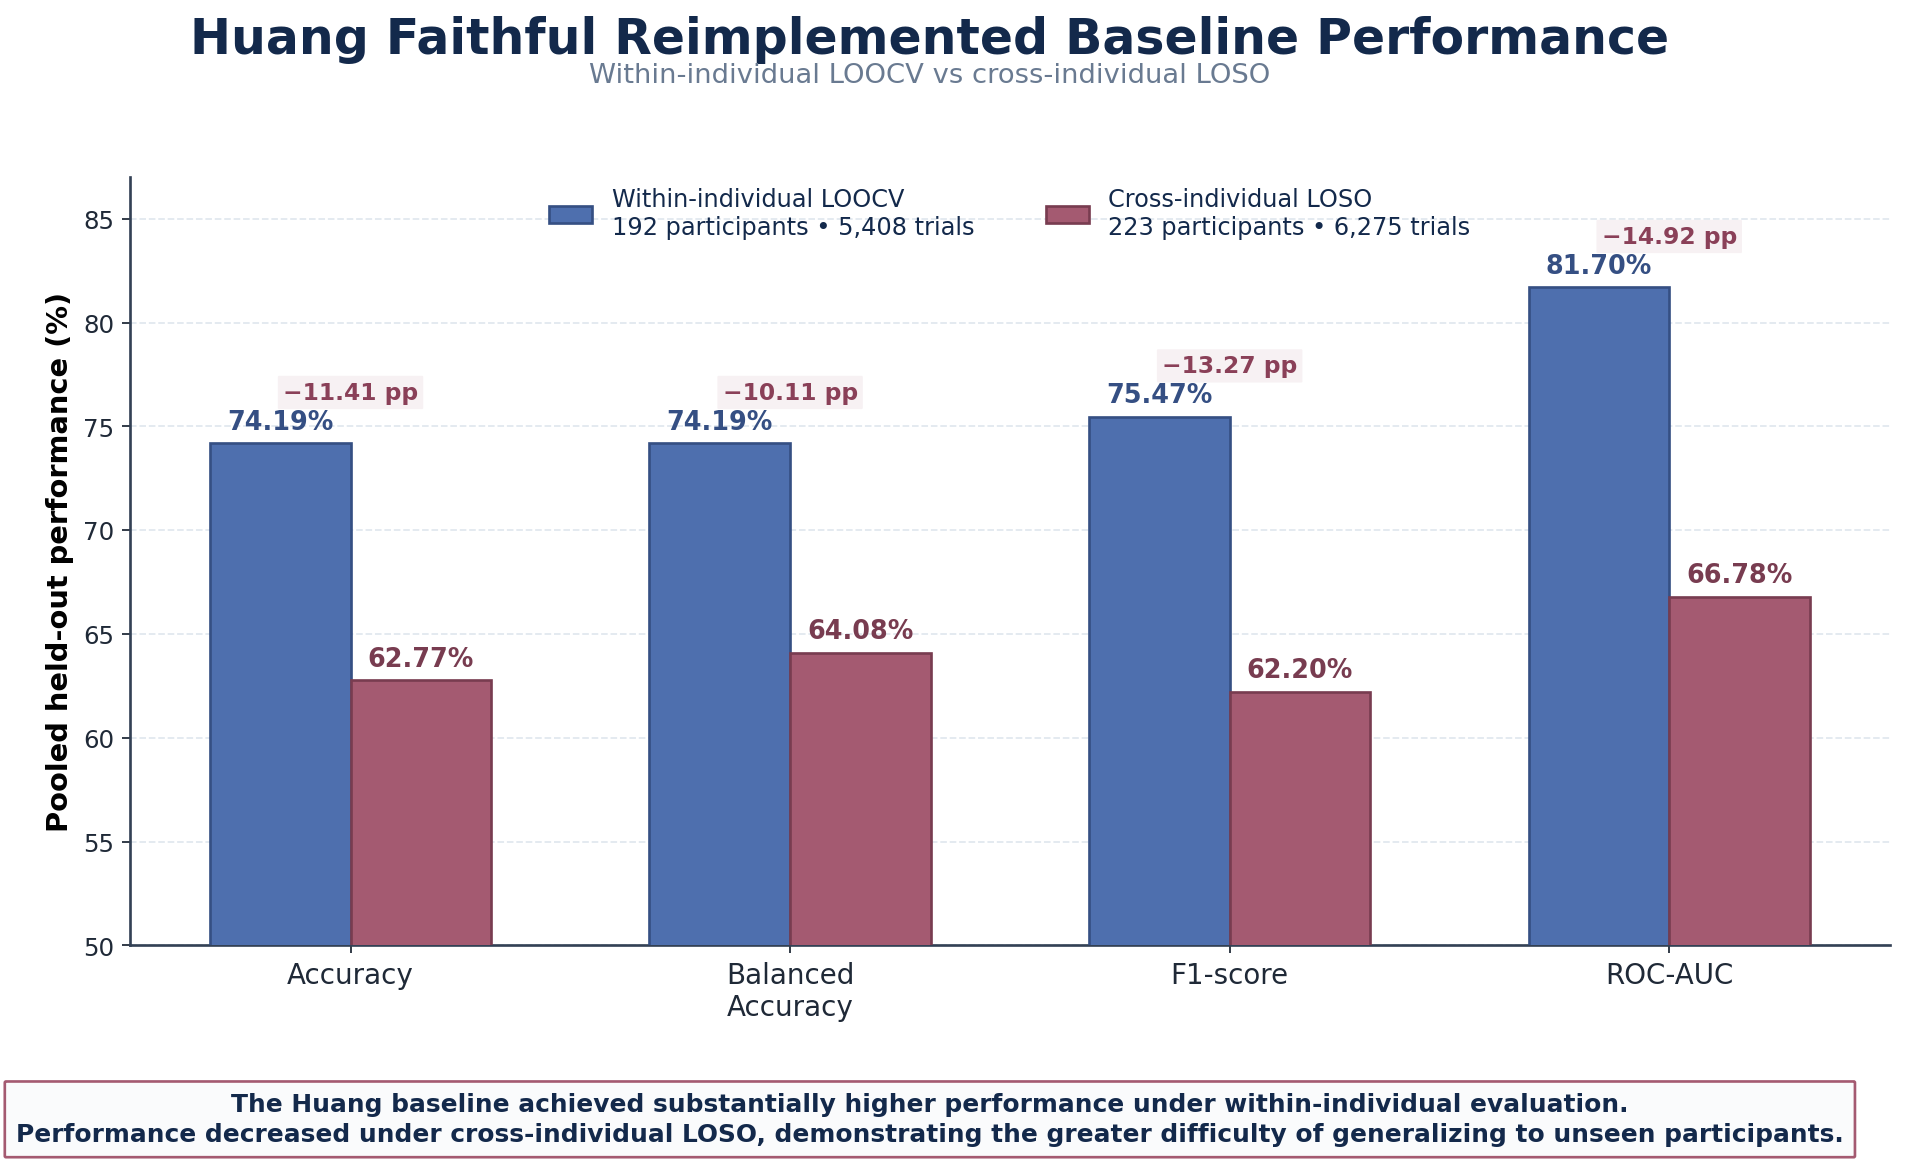

HUANG WITHIN vs CROSS COMPARISON
Accuracy             Within=74.19% | Cross=62.77% | Drop=11.41 pp
Balanced Accuracy    Within=74.19% | Cross=64.08% | Drop=10.11 pp
F1-score             Within=75.47% | Cross=62.20% | Drop=13.27 pp
ROC-AUC              Within=81.70% | Cross=66.78% | Drop=14.92 pp

Saved to:
/content/drive/MyDrive/EXP8_HUANG_PUBLICATION_FIGURES/Huang_Within_vs_Cross_Performance_Comparison.png


In [ ]:
# ============================================================
# HUANG FAITHFUL REIMPLEMENTED BASELINE
# WITHIN-INDIVIDUAL vs CROSS-INDIVIDUAL PERFORMANCE
#
# Metrics:
#   Accuracy
#   Balanced Accuracy
#   F1-score
#   ROC-AUC
#
# Publication-quality | White background | Thesis-ready
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. SAVE DIRECTORY
# ============================================================

SAVE_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_HUANG_PUBLICATION_FIGURES"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

OUTPUT_PATH = os.path.join(
    SAVE_DIR,
    "Huang_Within_vs_Cross_Performance_Comparison.png"
)


# ============================================================
# 2. EXACT RESULTS
# ============================================================

metrics = [
    "Accuracy",
    "Balanced\nAccuracy",
    "F1-score",
    "ROC-AUC"
]


# ------------------------------------------------------------
# Within-individual LOOCV
# 192 participants
# 5,408 held-out trials
# ------------------------------------------------------------

within_values = np.array([
    74.186391,   # Accuracy
    74.186271,   # Balanced Accuracy
    75.465729,   # F1-score
    81.700700    # ROC-AUC
])


# ------------------------------------------------------------
# Cross-individual LOSO
# 223 participants
# 6,275 held-out trials
# ------------------------------------------------------------

cross_values = np.array([
    62.7729,     # Accuracy
    64.0796,     # Balanced Accuracy
    62.2006,     # F1-score
    66.7845      # ROC-AUC
])


# ------------------------------------------------------------
# Generalization drop
# within - cross
# ------------------------------------------------------------

performance_drop = (
    within_values
    -
    cross_values
)


# ============================================================
# 3. PREMIUM COLOR PALETTE
# ============================================================

NAVY = "#13294B"
SUBTITLE = "#697A91"
GRID = "#DCE4EC"

# Within-individual
WITHIN_COLOR = "#4E6FAE"
WITHIN_EDGE = "#354F83"

# Cross-individual
CROSS_COLOR = "#A45A71"
CROSS_EDGE = "#783C50"

# Generalization-drop badges
BADGE_BG = "#F7F1F3"
BADGE_TEXT = "#8A4058"

# Footer
FOOTER_BG = "#FAFBFC"
FOOTER_BORDER = "#A45A71"


# ============================================================
# 4. GLOBAL STYLE
# ============================================================

plt.rcParams.update({

    "figure.dpi": 160,

    "savefig.dpi": 300,

    "font.family": "DejaVu Sans",

    "font.size": 11,

    "axes.edgecolor": "#334155",

    "axes.linewidth": 1.2,

    "xtick.color": "#1F2937",

    "ytick.color": "#1F2937",

    "text.color": NAVY
})


# ============================================================
# 5. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12.5, 7.5),
    facecolor="white"
)

ax.set_facecolor(
    "white"
)


x = np.arange(
    len(metrics)
)

width = 0.32


# ============================================================
# 6. WITHIN-INDIVIDUAL BARS
# ============================================================

within_bars = ax.bar(

    x - width / 2,

    within_values,

    width,

    color=WITHIN_COLOR,

    edgecolor=WITHIN_EDGE,

    linewidth=1.2,

    label=(
        "Within-individual LOOCV\n"
        "192 participants • 5,408 trials"
    ),

    zorder=3
)


# ============================================================
# 7. CROSS-INDIVIDUAL BARS
# ============================================================

cross_bars = ax.bar(

    x + width / 2,

    cross_values,

    width,

    color=CROSS_COLOR,

    edgecolor=CROSS_EDGE,

    linewidth=1.2,

    label=(
        "Cross-individual LOSO\n"
        "223 participants • 6,275 trials"
    ),

    zorder=3
)


# ============================================================
# 8. VALUE LABELS — WITHIN
# ============================================================

for bar in within_bars:

    value = bar.get_height()

    ax.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.40,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11.5,

        fontweight="bold",

        color=WITHIN_EDGE
    )


# ============================================================
# 9. VALUE LABELS — CROSS
# ============================================================

for bar in cross_bars:

    value = bar.get_height()

    ax.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.40,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11.5,

        fontweight="bold",

        color=CROSS_EDGE
    )


# ============================================================
# 10. GENERALIZATION-DROP ANNOTATIONS
# ============================================================

for i, drop in enumerate(
    performance_drop
):

    top_value = max(
        within_values[i],
        cross_values[i]
    )

    ax.text(

        x[i],

        top_value + 2.45,

        f"−{drop:.2f} pp",

        ha="center",

        va="center",

        fontsize=10.5,

        fontweight="bold",

        color=BADGE_TEXT,

        bbox=dict(

            boxstyle=(
                "round,"
                "pad=0.22,"
                "rounding_size=0.05"
            ),

            facecolor=BADGE_BG,

            edgecolor="none"
        )
    )


# ============================================================
# 11. MAIN TITLE
# ============================================================

fig.suptitle(

    "Huang Faithful Reimplemented Baseline Performance",

    fontsize=22,

    fontweight="bold",

    color=NAVY,

    y=0.965
)


# ============================================================
# 12. SUBTITLE
# ============================================================

fig.text(

    0.5,

    0.915,

    (
        "Within-individual LOOCV vs "
        "cross-individual LOSO"
    ),

    ha="center",

    va="center",

    fontsize=12.3,

    color=SUBTITLE
)


# ============================================================
# 13. AXES
# ============================================================

ax.set_ylabel(

    "Pooled held-out performance (%)",

    fontsize=13,

    fontweight="bold"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(

    metrics,

    fontsize=12.5
)


ax.set_ylim(
    50,
    87
)


ax.set_yticks(
    np.arange(
        50,
        86,
        5
    )
)


# ============================================================
# 14. GRID
# ============================================================

ax.grid(

    axis="y",

    linestyle="--",

    linewidth=0.8,

    color=GRID,

    alpha=0.85,

    zorder=0
)


ax.set_axisbelow(
    True
)


# ============================================================
# 15. CLEAN SPINES
# ============================================================

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.spines[
    "left"
].set_color(
    "#334155"
)

ax.spines[
    "bottom"
].set_color(
    "#334155"
)


# ============================================================
# 16. LEGEND
# ============================================================

ax.legend(

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        1.015
    ),

    ncol=2,

    frameon=False,

    fontsize=10.8,

    columnspacing=3.0,

    handlelength=1.8
)


# ============================================================
# 17. TWO-LINE THESIS INTERPRETATION
# ============================================================

footer = (
    "The Huang baseline achieved substantially higher performance "
    "under within-individual evaluation.\n"
    "Performance decreased under cross-individual LOSO, demonstrating "
    "the greater difficulty of generalizing to unseen participants."
)


fig.text(

    0.5,

    0.045,

    footer,

    ha="center",

    va="center",

    multialignment="center",

    linespacing=1.28,

    fontsize=11.2,

    fontweight="bold",

    color=NAVY,

    bbox=dict(

        boxstyle=(
            "round,"
            "pad=0.45,"
            "rounding_size=0.05"
        ),

        facecolor=FOOTER_BG,

        edgecolor=FOOTER_BORDER,

        linewidth=1.2
    )
)


# ============================================================
# 18. LAYOUT
# ============================================================

plt.subplots_adjust(

    top=0.83,

    bottom=0.19,

    left=0.10,

    right=0.98
)


# ============================================================
# 19. SAVE
# ============================================================

plt.savefig(

    OUTPUT_PATH,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


plt.show()


# ============================================================
# 20. PRINT EXACT VALUES
# ============================================================

print("=" * 78)
print("HUANG WITHIN vs CROSS COMPARISON")
print("=" * 78)

for (
    metric,
    within_value,
    cross_value,
    drop
) in zip(
    metrics,
    within_values,
    cross_values,
    performance_drop
):

    clean_metric = metric.replace(
        "\n",
        " "
    )

    print(
        f"{clean_metric:<20} "
        f"Within={within_value:.2f}% | "
        f"Cross={cross_value:.2f}% | "
        f"Drop={drop:.2f} pp"
    )


print("\nSaved to:")
print(OUTPUT_PATH)